# Viewer Engagement and Content Dynamics Analysis

## Project Overview
This project analyzes behavioral patterns within a large-scale streaming platform using anonymized viewer interactions. The goal is to explore and model audience behavior, understanding how viewers interact with different genres, how preferences evolve over time, and how groups of users relate through shared viewing patterns.

**Key Objectives:**
- Perform comprehensive EDA with visualizations
- Define problem type (regression/classification/clustering)
- Test multiple models with proper validation
- Provide interpretable insights for content curation and recommendation strategies


## 1. Import Libraries and Setup


In [3]:
# Standard libraries
import sqlite3
import warnings
warnings.filterwarnings('ignore')
# Data manipulation
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib import style
style.use('seaborn-v0_8-darkgrid')
# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import SimpleImputer
# Statistical analysis
from scipy import stats
from scipy.stats import zscore
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)
print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 1.26.4


## 2. Load and Explore Database Structure


In [4]:
# Connect to the database
db_path = 'viewer_interactions.db'
conn = sqlite3.connect(db_path)
# Explore database structure
print("DATABASE STRUCTURE EXPLORATION")
# Get all table names
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"\nTables in database: {[t[0] for t in tables]}")
# Get schemas
print("TABLE SCHEMAS")
for table in tables:
    table_name = table[0]
    cursor.execute(f"SELECT sql FROM sqlite_master WHERE type='table' AND name='{table_name}';")
    schema = cursor.fetchone()
    print(f"\n{table_name}:")
    print(schema[0] if schema else "No schema found")
# Load data dictionary
print("DATA DICTIONARY")
data_dict = pd.read_sql_query("SELECT * FROM data_dictionary", conn)
print(data_dict.to_string())


DATABASE STRUCTURE EXPLORATION

Tables in database: ['viewer_ratings', 'movies', 'user_statistics', 'movie_statistics', 'data_dictionary']
TABLE SCHEMAS

viewer_ratings:
CREATE TABLE "viewer_ratings" (
"movie_id" INTEGER,
  "customer_id" INTEGER,
  "rating" REAL,
  "date" TEXT,
  "anomalous_date" INTEGER
)

movies:
CREATE TABLE "movies" (
"movie_id" INTEGER,
  "year_of_release" REAL,
  "title" TEXT
)

user_statistics:
CREATE TABLE "user_statistics" (
"customer_id" INTEGER,
  "total_ratings" REAL,
  "avg_rating" REAL,
  "std_rating" REAL,
  "min_rating" REAL,
  "max_rating" REAL,
  "unique_movies" REAL,
  "first_rating_date" TEXT,
  "last_rating_date" TEXT,
  "activity_days" REAL
)

movie_statistics:
CREATE TABLE "movie_statistics" (
"movie_id" INTEGER,
  "total_ratings" REAL,
  "avg_rating" REAL,
  "std_rating" REAL,
  "min_rating" REAL,
  "max_rating" REAL,
  "unique_users" REAL,
  "first_rating_date" TEXT,
  "last_rating_date" TEXT,
  "year_of_release" REAL,
  "title" TEXT
)

data_di

In [5]:
# Load viewer ratings (main interaction data)
viewer_ratings = pd.read_sql_query("SELECT * FROM viewer_ratings", conn)
print(f"\nviewer_ratings shape: {viewer_ratings.shape}")
# Load movies
movies = pd.read_sql_query("SELECT * FROM movies", conn)
print(f"movies shape: {movies.shape}")
# Load user statistics
user_stats = pd.read_sql_query("SELECT * FROM user_statistics", conn)
print(f"user_statistics shape: {user_stats.shape}")
# Load movie statistics
movie_stats = pd.read_sql_query("SELECT * FROM movie_statistics", conn)
print(f"movie_statistics shape: {movie_stats.shape}")
# Display first few rows
print("SAMPLE DATA - viewer_ratings")
display(viewer_ratings.head(10))
print("SAMPLE DATA - movies")
display(movies.head(10))
print("SAMPLE DATA - user_stats")
display(user_stats.head(10))
print("SAMPLE DATA - movie_stats")
display(movie_stats.head(10))
# Close connection
#conn.close()
#print("\nDatabase connection closed.")



viewer_ratings shape: (4025000, 5)
movies shape: (18008, 3)
user_statistics shape: (438780, 10)
movie_statistics shape: (16015, 11)
SAMPLE DATA - viewer_ratings


,movie_id,customer_id,rating,date,anomalous_date
0,17,1481737,3.0,2005-10-09,NaN
1,9236,1448424,5.0,2005-11-15,NaN
2,4640,2308980,NaN,2005-08-06,NaN
3,9330,674346,3.0,2005-04-29,NaN
4,4570,1304045,4.0,2005-09-19,NaN
5,9320,1036533,5.0,2004-08-05,NaN
6,191,2066911,NaN,2003-12-24,NaN
7,4590,670110,5.0,2005-05-17,NaN
8,44,707611,5.0,2005-03-13,NaN
9,4590,2389674,3.0,2005-09-06,NaN


SAMPLE DATA - movies


,movie_id,year_of_release,title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
6,7,1992.0,8 Man
7,8,2004.0,What the #$*! Do We Know!?
8,9,1991.0,Class of Nuke 'Em High 2
9,10,2001.0,Fighter


SAMPLE DATA - user_stats


,customer_id,total_ratings,avg_rating,std_rating,min_rating,max_rating,unique_movies,first_rating_date,last_rating_date,activity_days
0,1965326,8.0,3.250000,0.886405,2.0,5.0,8.0,2004-08-11,2005-06-06,299.0
1,506434,1.0,4.000000,NaN,4.0,4.0,1.0,2005-08-02,2005-08-02,0.0
2,1365167,3.0,4.666667,0.577350,4.0,5.0,3.0,2004-11-16,2005-01-19,64.0
3,396632,2.0,NaN,0.000000,4.0,4.0,2.0,2004-07-07,2004-07-07,0.0
4,260614,3.0,4.333333,0.577350,4.0,5.0,3.0,2004-03-02,2004-10-13,NaN
5,2261444,34.0,3.205882,0.946426,2.0,5.0,34.0,2004-08-07,2005-04-16,252.0
6,926582,11.0,3.454545,NaN,2.0,5.0,11.0,2004-05-26,2005-09-27,489.0
7,2606642,5.0,3.800000,1.643168,1.0,5.0,5.0,2004-02-23,2005-03-02,373.0
8,2460888,5.0,4.400000,0.547723,4.0,NaN,5.0,2005-10-19,2005-11-09,21.0
9,413350,4.0,3.000000,1.414214,1.0,4.0,4.0,2005-05-15,2005-08-29,106.0


SAMPLE DATA - movie_stats


,movie_id,total_ratings,avg_rating,std_rating,min_rating,max_rating,unique_users,first_rating_date,last_rating_date,year_of_release,title
0,1,548.0,3.744526,1.073389,1.0,5.0,548.0,2003-07-12,2005-12-30,2003.0,Dinosaur Planet
1,2,146.0,3.547945,1.281606,1.0,5.0,146.0,2004-10-16,2005-12-20,2004.0,Isle of Man TT 2004 Review
2,3,2013.0,3.639841,0.978873,1.0,5.0,2013.0,2000-10-19,2005-12-30,1997.0,Character
3,4,142.0,2.739437,1.302913,1.0,5.0,142.0,2003-12-06,2005-12-27,1994.0,Paula Abdul's Get Up & Dance
4,5,1140.0,3.919298,1.292436,1.0,5.0,1140.0,2004-11-02,2005-12-29,2004.0,The Rise and Fall of ECW
5,6,1020.0,3.083333,1.290076,1.0,5.0,1020.0,1999-02-16,2005-12-29,1997.0,Sick
6,7,95.0,2.147368,1.110572,1.0,5.0,95.0,1999-02-22,2005-12-22,1992.0,8 Man
7,8,14912.0,3.189646,1.314521,1.0,5.0,14912.0,2004-09-13,2005-12-31,2004.0,What the #$*! Do We Know!?
8,9,96.0,2.645833,1.264738,1.0,5.0,96.0,2002-02-10,2005-12-13,1991.0,Class of Nuke 'Em High 2
9,10,250.0,3.176000,1.134094,1.0,5.0,250.0,2002-11-23,2005-12-21,2001.0,Fighter


After examining the data dictionary, I've identified several data quality issues:

1. **`anomalous_date` variable is missing from the dictionary**: The `viewer_ratings` table has an `anomalous_date` column (INTEGER flag) that exists in the schema but is not documented in the `data_dictionary` table. This field appears to flag dates that are anomalous or potentially data quality issues. Later in subsection 2.2, I explore what this variable means and how many records it affects.

2. **`activity_days` is redundant**: The `user_statistics` table contains an `activity_days` column that can be computed from `first_rating_date` and `last_rating_date` (e.g., `(last_rating_date - first_rating_date).days + 1`). While this pre-computed field doesn't cause harm, it's redundant. Since I'm not using the pre-computed statistics tables in the modeling (to avoid data leakage), this primarily affects data documentation quality.

3. **Overlapping column names between `user_statistics` and `movie_statistics`**: Both tables share several column names (`total_ratings`, `avg_rating`, `std_rating`, `min_rating`, `max_rating`, `first_rating_date`, `last_rating_date`), which is confusing when working with both tables. I rename them later in subsection 2.2.

## 2.1 Basic information about the datasets

In [6]:
# Basic information about the datasets
print("BASIC DATA INFORMATION")
print("\nviewer_ratings Info:")
print(viewer_ratings.info())
print("\nviewer_ratings Description:")
display(viewer_ratings.describe())
print("\nmovies Info:")
print(movies.info())
print("\nmovies Description:")
display(movies.describe())
print("\nData Types:")
print(viewer_ratings.dtypes)

BASIC DATA INFORMATION

viewer_ratings Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4025000 entries, 0 to 4024999
Data columns (total 5 columns):
 #   Column          Dtype  
---  ------          -----  
 0   movie_id        int64  
 1   customer_id     int64  
 2   rating          float64
 3   date            object 
 4   anomalous_date  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 153.5+ MB
None

viewer_ratings Description:


,movie_id,customer_id,rating,anomalous_date
count,4.025000e+06,4.025000e+06,3.622500e+06,1209.0
mean,6.909771e+03,1.321713e+06,3.608666e+00,1.0
std,5.033220e+03,7.645457e+05,1.078211e+00,0.0
min,1.000000e+00,6.000000e+00,0.000000e+00,1.0
25%,4.503000e+03,6.599900e+05,3.000000e+00,1.0
50%,9.217000e+03,1.317589e+06,4.000000e+00,1.0
75%,1.337500e+04,1.983819e+06,4.000000e+00,1.0
max,2.500000e+04,2.649429e+06,6.000000e+00,1.0



movies Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18008 entries, 0 to 18007
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         18008 non-null  int64  
 1   year_of_release  18001 non-null  float64
 2   title            18008 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 422.2+ KB
None

movies Description:


,movie_id,year_of_release
count,18008.000000,18001.000000
mean,9048.736562,1990.232543
std,5293.394384,16.445821
min,1.000000,1896.000000
25%,4502.750000,1985.000000
50%,9004.500000,1997.000000
75%,13506.250000,2002.000000
max,24974.000000,2005.000000



Data Types:
movie_id            int64
customer_id         int64
rating            float64
date               object
anomalous_date    float64
dtype: object


## 2.2 Data Quality Checks and Column Renaming

Exploring data quality issues identified earlier:
1. Understanding the `anomalous_date` variable
2. Renaming overlapping columns between `user_statistics` and `movie_statistics`


In [7]:
print("EXPLORING anomalous_date VARIABLE")
# Check distribution
print("\nDistribution of anomalous_date:")
anomalous_counts = viewer_ratings['anomalous_date'].value_counts(dropna=False).sort_index()
print(anomalous_counts)
print(f"\nPercentage: {((anomalous_counts / len(viewer_ratings)) * 100).round(2)}")
# Check dates where anomalous_date = 1
print("Dates flagged as anomalous (anomalous_date = 1):")
anomalous_dates = viewer_ratings[viewer_ratings['anomalous_date'] == 1].copy()
print(f"Total records with anomalous_date = 1: {len(anomalous_dates)}")
print(f"Percentage: {len(anomalous_dates) / len(viewer_ratings) * 100:.4f}%")
if len(anomalous_dates) > 0:
    anomalous_dates['date'] = pd.to_datetime(anomalous_dates['date'])
    print(f"\nDate range for anomalous dates:")
    print(f"  Min date: {anomalous_dates['date'].min()}")
    print(f"  Max date: {anomalous_dates['date'].max()}")
    # Check if all anomalous dates are outside expected range
    expected_max_date = pd.to_datetime('2005-12-31')
    print(f"\nExpected max date (from dictionary): {expected_max_date.date()}")
    print(f"Anomalous dates after expected max: {(anomalous_dates['date'] > expected_max_date).sum()}")
    # Sample of anomalous dates
    print("\nSample of dates flagged as anomalous:")
    date_counts = anomalous_dates.groupby(anomalous_dates['date'].dt.date).size().sort_values(ascending=False).head(20)
    print(date_counts)

EXPLORING anomalous_date VARIABLE

Distribution of anomalous_date:
anomalous_date
1.0       1209
NaN    4023791
Name: count, dtype: int64

Percentage: anomalous_date
1.0     0.03
NaN    99.97
Name: count, dtype: float64
Dates flagged as anomalous (anomalous_date = 1):
Total records with anomalous_date = 1: 1209
Percentage: 0.0300%

Date range for anomalous dates:
  Min date: 1995-01-01 00:00:00
  Max date: 2006-03-28 00:00:00

Expected max date (from dictionary): 2005-12-31
Anomalous dates after expected max: 411

Sample of dates flagged as anomalous:
date
2006-01-16    11
2006-03-28    10
2006-01-15    10
2006-02-26    10
2006-03-04    10
2006-03-13     9
2006-02-20     8
2006-02-23     8
2006-03-24     8
2006-02-19     8
2006-02-25     8
2006-03-19     7
2006-02-08     7
2006-02-05     7
2006-01-22     7
2006-03-17     7
2006-01-04     7
2006-03-27     7
2006-01-03     7
2006-02-01     6
dtype: int64


The `anomalous_date` variable flags dates that fall outside the expected range (pre-1998-01-01 and post-2005-12-31). These are valid data points (1209 records, 0.03% of data) from 2006. Since I'm doing general behavioral analysis and modeling and not only the 1998-2005 window, I decide to keep 'anomalous_date' - they represent only 0.03% of data and provide additional information. However, I'll include sensitivity analysis (run models with/without them) to check robustness in the end.

In [8]:
# Identify overlapping columns between user_statistics and movie_statistics
print("IDENTIFYING OVERLAPPING COLUMNS")
user_cols = set(user_stats.columns)
movie_cols = set(movie_stats.columns)
overlapping_cols = user_cols & movie_cols
user_only_cols = user_cols - movie_cols
movie_only_cols = movie_cols - user_cols
print(f"\nOverlapping columns ({len(overlapping_cols)}):")
print(sorted(overlapping_cols))
print(f"\nUser_statistics only columns ({len(user_only_cols)}):")
print(sorted(user_only_cols))
print(f"\nMovie_statistics only columns ({len(movie_only_cols)}):")
print(sorted(movie_only_cols))


IDENTIFYING OVERLAPPING COLUMNS

Overlapping columns (7):
['avg_rating', 'first_rating_date', 'last_rating_date', 'max_rating', 'min_rating', 'std_rating', 'total_ratings']

User_statistics only columns (3):
['activity_days', 'customer_id', 'unique_movies']

Movie_statistics only columns (4):
['movie_id', 'title', 'unique_users', 'year_of_release']


In [9]:
# Rename overlapping columns to avoid confusion
print(f"\nRENAMING OVERLAPPING COLUMNS")
# Columns to rename with prefixes
cols_to_rename_user = {
    'total_ratings': 'user_total_ratings',
    'avg_rating': 'user_avg_rating',
    'std_rating': 'user_std_rating',
    'min_rating': 'user_min_rating',
    'max_rating': 'user_max_rating',
    'first_rating_date': 'user_first_rating_date',
    'last_rating_date': 'user_last_rating_date'
}
cols_to_rename_movie = {
    'total_ratings': 'movie_total_ratings',
    'avg_rating': 'movie_avg_rating',
    'std_rating': 'movie_std_rating',
    'min_rating': 'movie_min_rating',
    'max_rating': 'movie_max_rating',
    'first_rating_date': 'movie_first_rating_date',
    'last_rating_date': 'movie_last_rating_date'
}
# Create renamed versions
user_stats_renamed = user_stats.rename(columns=cols_to_rename_user)
movie_stats_renamed = movie_stats.rename(columns=cols_to_rename_movie)
print("\nRenamed user_statistics columns:")
print(f"  Original: {sorted(user_stats.columns.tolist())}")
print(f"  Renamed:  {sorted(user_stats_renamed.columns.tolist())}")
print("\nRenamed movie_statistics columns:")
print(f"  Original: {sorted(movie_stats.columns.tolist())}")
print(f"  Renamed:  {sorted(movie_stats_renamed.columns.tolist())}")
# Update the original dataframes
user_stats = user_stats_renamed.copy()
movie_stats = movie_stats_renamed.copy()


RENAMING OVERLAPPING COLUMNS

Renamed user_statistics columns:
  Original: ['activity_days', 'avg_rating', 'customer_id', 'first_rating_date', 'last_rating_date', 'max_rating', 'min_rating', 'std_rating', 'total_ratings', 'unique_movies']
  Renamed:  ['activity_days', 'customer_id', 'unique_movies', 'user_avg_rating', 'user_first_rating_date', 'user_last_rating_date', 'user_max_rating', 'user_min_rating', 'user_std_rating', 'user_total_ratings']

Renamed movie_statistics columns:
  Original: ['avg_rating', 'first_rating_date', 'last_rating_date', 'max_rating', 'min_rating', 'movie_id', 'std_rating', 'title', 'total_ratings', 'unique_users', 'year_of_release']
  Renamed:  ['movie_avg_rating', 'movie_first_rating_date', 'movie_id', 'movie_last_rating_date', 'movie_max_rating', 'movie_min_rating', 'movie_std_rating', 'movie_total_ratings', 'title', 'unique_users', 'year_of_release']


## 2.3 Standardizing Date Column Types

Checking and standardizing all date columns to datetime64[ns] type for consistent date operations, comparisons, and temporal analysis.

In [10]:
# Check  date column types
print("STANDARDIZING DATE COLUMN TYPES")
# Check current date column types
print("\nCurrent date column types:")
print(f"  viewer_ratings['date']: {viewer_ratings['date'].dtype}")
if 'first_rating_date' in user_stats.columns:
    print(f"  user_stats['first_rating_date']: {user_stats['first_rating_date'].dtype}")
    print(f"  user_stats['last_rating_date']: {user_stats['last_rating_date'].dtype}")
if 'first_rating_date' in movie_stats.columns:
    print(f"  movie_stats['first_rating_date']: {movie_stats['first_rating_date'].dtype}")
    print(f"  movie_stats['last_rating_date']: {movie_stats['last_rating_date'].dtype}")

STANDARDIZING DATE COLUMN TYPES

Current date column types:
  viewer_ratings['date']: object


In [11]:
# Convert all date columns to datetime type
print("CONVERTING DATE COLUMNS TO DATETIME TYPE")
# viewer_ratings date column
print(f"\nConverting viewer_ratings['date'] from {viewer_ratings['date'].dtype} to datetime64")
viewer_ratings['date'] = pd.to_datetime(viewer_ratings['date'], errors='coerce')
print(f"  Converted. New type: {viewer_ratings['date'].dtype}")
# user_statistics date columns
date_cols_user = ['first_rating_date', 'last_rating_date']
for col in date_cols_user:
    if col in user_stats.columns:
        print(f"\nConverting user_stats['{col}'] from {user_stats[col].dtype} to datetime64")
        user_stats[col] = pd.to_datetime(user_stats[col], errors='coerce')
        print(f"  Converted. New type: {user_stats[col].dtype}")
# movie_statistics date columns
date_cols_movie = ['first_rating_date', 'last_rating_date']
for col in date_cols_movie:
    if col in movie_stats.columns:
        print(f"\nConverting movie_stats['{col}'] from {movie_stats[col].dtype} to datetime64")
        movie_stats[col] = pd.to_datetime(movie_stats[col], errors='coerce')
        print(f"  Converted. New type: {movie_stats[col].dtype}")

CONVERTING DATE COLUMNS TO DATETIME TYPE

Converting viewer_ratings['date'] from object to datetime64
  Converted. New type: datetime64[ns]


In [12]:
# Verify all date columns are now datetime
print("VERIFICATION - Final date column types:")
print(f"  viewer_ratings['date']: {viewer_ratings['date'].dtype}")
if 'first_rating_date' in user_stats.columns:
    print(f"  user_stats['first_rating_date']: {user_stats['first_rating_date'].dtype}")
    print(f"  user_stats['last_rating_date']: {user_stats['last_rating_date'].dtype}")
if 'first_rating_date' in movie_stats.columns:
    print(f"  movie_stats['first_rating_date']: {movie_stats['first_rating_date'].dtype}")
    print(f"  movie_stats['last_rating_date']: {movie_stats['last_rating_date'].dtype}")

VERIFICATION - Final date column types:
  viewer_ratings['date']: datetime64[ns]


## 3. Duplicate Detection and Handling

In [13]:
# Check for row duplicates
print("ROW DUPLICATE DETECTION")

duplicate_rows = viewer_ratings.duplicated().sum()
print(f"\nTotal rows: {len(viewer_ratings):,}")
print(f"Duplicate rows (exact duplicates): {duplicate_rows}")

ROW DUPLICATE DETECTION

Total rows: 4,025,000
Duplicate rows (exact duplicates): 0


In [14]:
# Check for duplicate (movie_id, customer_id) pairs
print("MOVIE ID/CUSTOMER ID DUPLICATE DETECTION")

duplicate_pairs = viewer_ratings.duplicated(subset=['movie_id', 'customer_id'], keep=False).sum()
print(f"\nDuplicate (movie_id, customer_id) pairs: {duplicate_pairs}")

MOVIE ID/CUSTOMER ID DUPLICATE DETECTION

Duplicate (movie_id, customer_id) pairs: 4


In [15]:
# Investigate duplicate pairs 
duplicate_data = viewer_ratings[viewer_ratings.duplicated(subset=['movie_id', 'customer_id'], keep=False)]
duplicate_data_sorted = duplicate_data.sort_values(['movie_id', 'customer_id', 'date'])
    
print(f"\nFound {len(duplicate_data)} rows with duplicate (movie_id, customer_id) pairs:")
print(duplicate_data_sorted[['movie_id', 'customer_id', 'rating', 'date', 'anomalous_date']].to_string(index=False))


Found 4 rows with duplicate (movie_id, customer_id) pairs:
 movie_id  customer_id  rating       date  anomalous_date
     4545      1754814     5.0 2003-07-02             NaN
     4545      1754814     5.0 2005-03-29             NaN
     4577      1338115     5.0 2004-11-03             NaN
     4577      1338115     5.0 2005-03-24             NaN


In [16]:
# Analyze the duplicates
print("\nANALYSIS:")

for (movie_id, customer_id), group in duplicate_data_sorted.groupby(['movie_id', 'customer_id']):
    ratings = group['rating'].tolist()
    dates = group['date'].tolist()
    print(f"\nMovie {movie_id}, Customer {customer_id}:")
    print(f"  Ratings: {ratings}")
    print(f"  Dates: {dates}")
    if len(set(ratings)) == 1:
        print(f"  → Same rating given multiple times (re-rating)")
    else:
        print(f"  → Different ratings (rating changed over time)")


ANALYSIS:

Movie 4545, Customer 1754814:
  Ratings: [5.0, 5.0]
  Dates: [Timestamp('2003-07-02 00:00:00'), Timestamp('2005-03-29 00:00:00')]
  → Same rating given multiple times (re-rating)

Movie 4577, Customer 1338115:
  Ratings: [5.0, 5.0]
  Dates: [Timestamp('2004-11-03 00:00:00'), Timestamp('2005-03-24 00:00:00')]
  → Same rating given multiple times (re-rating)


CONCLUSION: Keep all duplicate pairs. These represent legitimate re-ratings over time. For modeling, I will use the most recent rating.

## 4. Missing and Invalid Values Check and Handling Strategy

### 4.1 Missing Values Analysis


In [17]:
# Check missing values in all main tables
missing_data = {
    'viewer_ratings': viewer_ratings.isnull().sum(),
    'movies': movies.isnull().sum(),
    'user_stats': user_stats.isnull().sum(),
    'movie_stats': movie_stats.isnull().sum()
}


In [18]:
# Create comprehensive missing values summary
missing_summary = []
for table_name, missing_series in missing_data.items():
    for col, count in missing_series.items():
        if count > 0:
            total_rows = len(viewer_ratings) if table_name == 'viewer_ratings' else len(eval(table_name))
            pct = (count / total_rows) * 100
            missing_summary.append({
                'Table': table_name,
                'Column': col,
                'Missing Count': count,
                'Missing %': pct,
                'Total Rows': total_rows
            })
missing_df = pd.DataFrame(missing_summary)

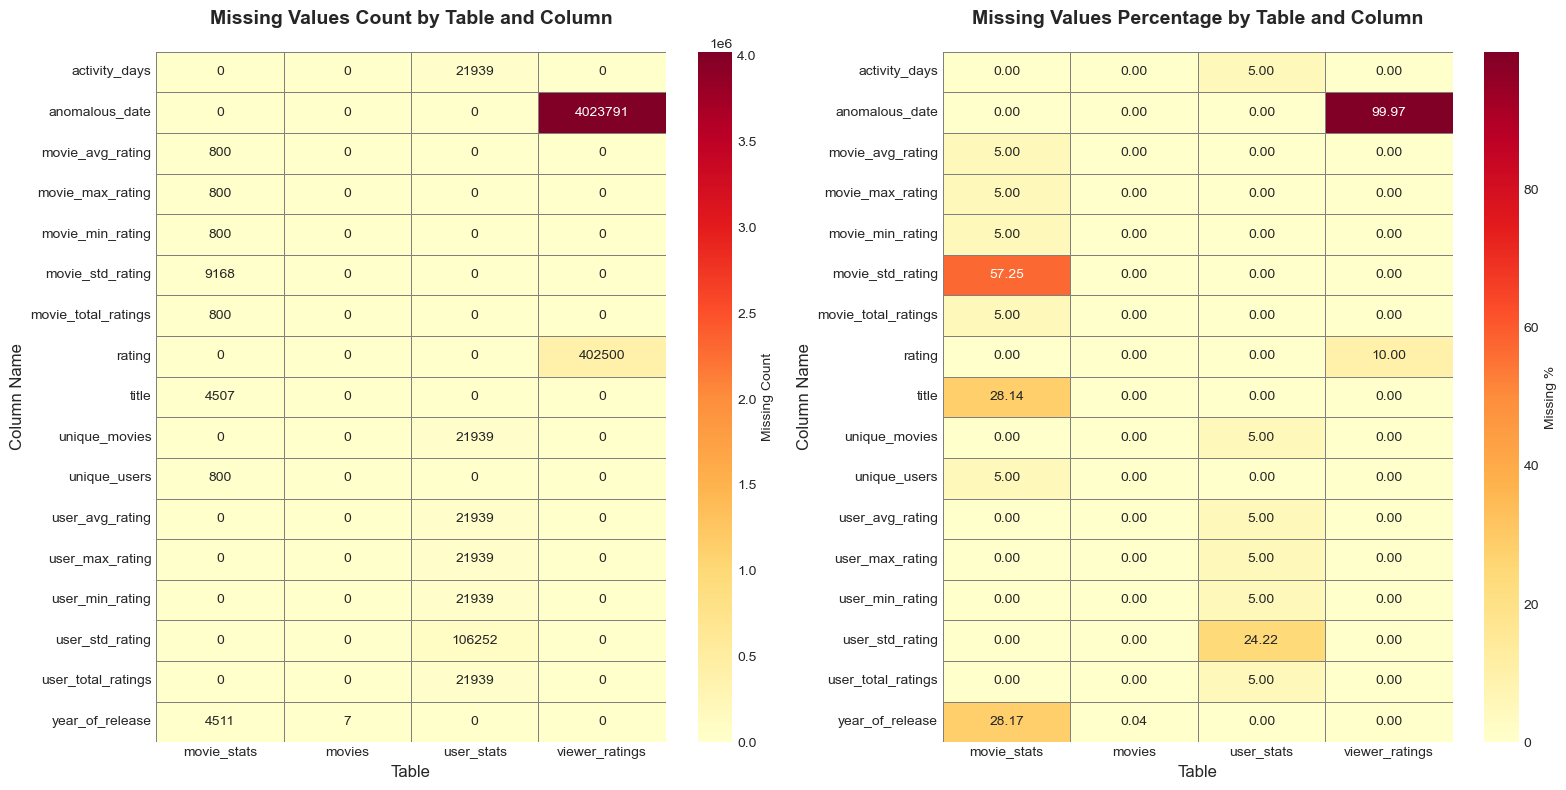

In [19]:
if len(missing_df) > 0:
    # Create informative heatmap
    # Pivot for heatmap visualization
    pivot_count = missing_df.pivot_table(
        index='Column', 
        columns='Table', 
        values='Missing Count', 
        fill_value=0
    )
    pivot_pct = missing_df.pivot_table(
        index='Column', 
        columns='Table', 
        values='Missing %', 
        fill_value=0
    )
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(pivot_count) * 0.4)))
    # Heatmap of missing values count
    sns.heatmap(pivot_count, annot=True, fmt='.0f', cmap='YlOrRd', 
                cbar_kws={'label': 'Missing Count'}, ax=axes[0], 
                linewidths=0.5, linecolor='gray')
    axes[0].set_title('Missing Values Count by Table and Column', fontsize=14, fontweight='bold', pad=20)
    axes[0].set_ylabel('Column Name', fontsize=12)
    axes[0].set_xlabel('Table', fontsize=12)
    # Heatmap of missing values percentage
    sns.heatmap(pivot_pct, annot=True, fmt='.2f', cmap='YlOrRd',
                cbar_kws={'label': 'Missing %'}, ax=axes[1],
                linewidths=0.5, linecolor='gray')
    axes[1].set_title('Missing Values Percentage by Table and Column', fontsize=14, fontweight='bold', pad=20)
    axes[1].set_ylabel('Column Name', fontsize=12)
    axes[1].set_xlabel('Table', fontsize=12)
    plt.tight_layout()
    plt.savefig('missing_values_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

else:
    print("No missing values found in any table")


In [20]:
# Summary by table
print("SUMMARY BY TABLE")

for table in missing_df['Table'].unique():
    table_missing = missing_df[missing_df['Table'] == table]
    total_missing = table_missing['Missing Count'].sum()
    print(f"\n{table}:")
    print(f"  Total missing values: {total_missing:,}")
    print(f"  Columns with missing values: {len(table_missing)}")
    for _, row in table_missing.iterrows():
        print(f"    - {row['Column']}: {row['Missing Count']:,} ({row['Missing %']:.2f}%)")

SUMMARY BY TABLE

viewer_ratings:
  Total missing values: 4,426,291
  Columns with missing values: 2
    - rating: 402,500 (10.00%)
    - anomalous_date: 4,023,791 (99.97%)

movies:
  Total missing values: 7
  Columns with missing values: 1
    - year_of_release: 7 (0.04%)

user_stats:
  Total missing values: 237,886
  Columns with missing values: 7
    - user_total_ratings: 21,939 (5.00%)
    - user_avg_rating: 21,939 (5.00%)
    - user_std_rating: 106,252 (24.22%)
    - user_min_rating: 21,939 (5.00%)
    - user_max_rating: 21,939 (5.00%)
    - unique_movies: 21,939 (5.00%)
    - activity_days: 21,939 (5.00%)

movie_stats:
  Total missing values: 22,186
  Columns with missing values: 8
    - movie_total_ratings: 800 (5.00%)
    - movie_avg_rating: 800 (5.00%)
    - movie_std_rating: 9,168 (57.25%)
    - movie_min_rating: 800 (5.00%)
    - movie_max_rating: 800 (5.00%)
    - unique_users: 800 (5.00%)
    - year_of_release: 4,511 (28.17%)
    - title: 4,507 (28.14%)


In [21]:
# Check unique counts
print("UNIQUE COUNTS")
print(f"Unique customers: {viewer_ratings['customer_id'].nunique()}")
print(f"Unique movies: {viewer_ratings['movie_id'].nunique()}")
print(f"Unique ratings: {viewer_ratings['rating'].nunique()}")
print(f"Rating range: {viewer_ratings['rating'].min()} - {viewer_ratings['rating'].max()}")

UNIQUE COUNTS
Unique customers: 438570
Unique movies: 16013
Unique ratings: 7
Rating range: 0.0 - 6.0


In [22]:
# Check date range
viewer_ratings['date'] = pd.to_datetime(viewer_ratings['date'], errors='coerce')
print(f"\nDate range: {viewer_ratings['date'].min()} to {viewer_ratings['date'].max()}")
print(f"Total days span: {(viewer_ratings['date'].max() - viewer_ratings['date'].min()).days} days")


Date range: 1995-01-01 00:00:00 to 2006-03-28 00:00:00
Total days span: 4104 days


# 5. Preprocessing
1. Create viewer_ratings_all (preserve all original data for EDA)
1. Handles invalid ratings (0, 6) → converts to NaN
2. Creates clean datasets for EDA and modeling (exclude NaN)
3. Merges tables (ratings + movies)
4. Handles missing values in merged data
5. Prepares all datasets needed for subsequent sections

**Strategy by variable type:**

- **Target variable (rating)**: Exclusion (no imputation)
  - Invalid ratings (0, 6) → convert to NaN
  - Exclude NaN ratings from modeling dataset

- **Feature variables**:
  - `year_of_release`: Drop rows with missing year
  - `anomalous_date`: Fill NaN with 0 (binary flag)

**Output datasets:**
- `viewer_ratings_all`: All original data (for reference)
- `viewer_ratings_clean`: Clean data without NaN ratings
- `ratings_with_movies`: Merged data for EDA (Section 5)
- `ratings_sorted`: Clean merged data for feature engineering (Section 7)

In [23]:
#Create viewer_ratings_all

viewer_ratings_all = viewer_ratings.copy()
print(f"\nCreated 'viewer_ratings_all' (preserve all data)")
print(f"  Shape: {viewer_ratings_all.shape}")
print(f"  Total ratings: {len(viewer_ratings_all):,}")


Created 'viewer_ratings_all' (preserve all data)
  Shape: (4025000, 5)
  Total ratings: 4,025,000


In [24]:
#Convert invalid ratings (0 and 6) to NaN
print("\nConverting invalid ratings (0 and 6) to NaN")

invalid_0 = (viewer_ratings['rating'] == 0).sum()
invalid_6 = (viewer_ratings['rating'] == 6).sum()
print(f"  Ratings = 0: {invalid_0:,} ({100*invalid_0/len(viewer_ratings):.4f}%)")
print(f"  Ratings = 6: {invalid_6:,} ({100*invalid_6/len(viewer_ratings):.4f}%)")

#Convert invalid ratings to NaN
viewer_ratings.loc[viewer_ratings['rating'] == 0, 'rating'] = np.nan
viewer_ratings.loc[viewer_ratings['rating'] == 6, 'rating'] = np.nan

invalid_total = viewer_ratings['rating'].isnull().sum()
print(f"  Total invalid ratings (now NaN): {invalid_total:,} ({100*invalid_total/len(viewer_ratings):.2f}%)")


Converting invalid ratings (0 and 6) to NaN
  Ratings = 0: 385 (0.0096%)
  Ratings = 6: 376 (0.0093%)
  Total invalid ratings (now NaN): 403,261 (10.02%)


In [25]:
#Create clean dataset for rating prediction
print("\nCreating clean dataset (exclude NaN ratings)")

viewer_ratings_clean = viewer_ratings.dropna(subset=['rating']).copy()
print(f"  Original dataset: {len(viewer_ratings):,} rows")
print(f"  Clean dataset: {len(viewer_ratings_clean):,} rows")
print(f"  Excluded: {len(viewer_ratings) - len(viewer_ratings_clean):,} rows ({100*(len(viewer_ratings) - len(viewer_ratings_clean))/len(viewer_ratings):.2f}%)")

#Verify clean dataset has valid ratings only
print(f"\n  Clean dataset rating range: {viewer_ratings_clean['rating'].min():.0f} - {viewer_ratings_clean['rating'].max():.0f}")
print(f"  Clean dataset missing ratings: {viewer_ratings_clean['rating'].isnull().sum()}")


Creating clean dataset (exclude NaN ratings)
  Original dataset: 4,025,000 rows
  Clean dataset: 3,621,739 rows
  Excluded: 403,261 rows (10.02%)

  Clean dataset rating range: 1 - 5
  Clean dataset missing ratings: 0


In [26]:
#Update main viewer_ratings to clean version (for modeling)
print("\nUpdating 'viewer_ratings' to clean version (for modeling)")
viewer_ratings = viewer_ratings_clean.copy()
print(f"  'viewer_ratings' now contains clean data: {len(viewer_ratings):,} rows")


Updating 'viewer_ratings' to clean version (for modeling)
  'viewer_ratings' now contains clean data: 3,621,739 rows


In [27]:
#Create ratings_with_movies for EDA (merge with movie metadata)
print("\nCreating 'ratings_with_movies' for EDA")
print("  Using viewer_ratings_clean (excludes ratings 0, 6, and NULL)")

ratings_with_movies = viewer_ratings_clean.merge(movies, on='movie_id', how='left')
print(f"  Shape: {ratings_with_movies.shape}")
print(f"  This combines CLEAN ratings (0 and 6 excluded) with movie metadata")
print(f"  Rating range: 1.0 - 5.0 (no invalid ratings)")
print(f"  Use this for EDA visualizations (Section 5)")


Creating 'ratings_with_movies' for EDA
  Using viewer_ratings_clean (excludes ratings 0, 6, and NULL)
  Shape: (3621742, 7)
  This combines CLEAN ratings (0 and 6 excluded) with movie metadata
  Rating range: 1.0 - 5.0 (no invalid ratings)
  Use this for EDA visualizations (Section 5)


In [28]:
print("SUMMARY")

print(f"viewer_ratings_all: {len(viewer_ratings_all):,} rows (all original data for EDA)")
print(f"viewer_ratings_clean: {len(viewer_ratings_clean):,} rows (excludes NaN ratings)")
print(f"viewer_ratings: {len(viewer_ratings):,} rows (updated to clean version for modeling)")
print(f"ratings_with_movies: {len(ratings_with_movies):,} rows (clean data: excludes 0, 6, NULL) for EDA visualizations")
print("\nInvalid ratings (0, 6) converted to NaN and excluded from modeling")

SUMMARY
viewer_ratings_all: 4,025,000 rows (all original data for EDA)
viewer_ratings_clean: 3,621,739 rows (excludes NaN ratings)
viewer_ratings: 3,621,739 rows (updated to clean version for modeling)
ratings_with_movies: 3,621,742 rows (clean data: excludes 0, 6, NULL) for EDA visualizations

Invalid ratings (0, 6) converted to NaN and excluded from modeling


In [29]:
#Create ratings_sorted for modeling (clean merged data)
print("\nCreating 'ratings_sorted' for modeling")

# Use clean viewer_ratings and merge with movies
ratings_sorted = viewer_ratings.merge(movies, on='movie_id', how='left')

# Handle duplicates: Keep only most recent rating for each (movie_id, customer_id) pair
# This implements the decision from Section 3: use most recent rating for modeling
print("\nHandling duplicate (movie_id, customer_id) pairs...")
duplicate_count_before = ratings_sorted.duplicated(subset=['movie_id', 'customer_id'], keep=False).sum()
if duplicate_count_before > 0:
    print(f"  Found {duplicate_count_before} rows with duplicate (movie_id, customer_id) pairs")
    # Sort by date (most recent first) and keep first occurrence
    ratings_sorted = ratings_sorted.sort_values(['movie_id', 'customer_id', 'date'], ascending=[True, True, False])
    ratings_sorted = ratings_sorted.drop_duplicates(subset=['movie_id', 'customer_id'], keep='first')
    duplicate_count_after = ratings_sorted.duplicated(subset=['movie_id', 'customer_id'], keep=False).sum()
    print(f"  After keeping most recent: {duplicate_count_after} duplicates remaining")
    print(f"  Removed {duplicate_count_before - duplicate_count_after} duplicate rows")
    print(f"  Final dataset size: {len(ratings_sorted):,} rows")
else:
    print(f"  No duplicate (movie_id, customer_id) pairs found")
print(f"  Shape: {ratings_sorted.shape}")
print(f"  This is clean merged data ready for feature engineering")



Creating 'ratings_sorted' for modeling

Handling duplicate (movie_id, customer_id) pairs...
  Found 10 rows with duplicate (movie_id, customer_id) pairs
  After keeping most recent: 0 duplicates remaining
  Removed 10 duplicate rows
  Final dataset size: 3,621,737 rows
  Shape: (3621737, 7)
  This is clean merged data ready for feature engineering


In [30]:
# Handle missing year_of_release (drop rows with missing year)
missing_year = ratings_sorted['year_of_release'].isnull().sum()
if missing_year > 0:
    print(f"  Dropping {missing_year:,} rows with missing year_of_release ({100*missing_year/len(ratings_sorted):.2f}%)")
    ratings_sorted = ratings_sorted.dropna(subset=['year_of_release']).copy()
    print(f"  Remaining rows: {len(ratings_sorted):,}")

# Handle anomalous_date (fill NaN with 0)
ratings_sorted['anomalous_date'] = ratings_sorted['anomalous_date'].fillna(0)
print(f"  Filled anomalous_date NaN values with 0")

# Verify ratings are in valid range
print(f"  Rating range: {ratings_sorted['rating'].min():.0f} - {ratings_sorted['rating'].max():.0f}")
print(f"  Missing ratings: {ratings_sorted['rating'].isnull().sum()}")

  Dropping 6,336 rows with missing year_of_release (0.17%)
  Remaining rows: 3,615,401
  Filled anomalous_date NaN values with 0
  Rating range: 1 - 5
  Missing ratings: 0


In [31]:
print("FINAL SUMMARY")

print(f"\nviewer_ratings_all: {len(viewer_ratings_all):,} rows (all original data)")
print(f"viewer_ratings_clean: {len(viewer_ratings_clean):,} rows (excludes NaN ratings)")
print(f"viewer_ratings: {len(viewer_ratings):,} rows (updated to clean version)")
print(f"ratings_with_movies: {len(ratings_with_movies):,} rows (clean data: excludes 0, 6, NULL) for EDA visualizations")

print("EDA (Section 5) will use: ratings_with_movies")
print("Feature Engineering (Section 7) will use: ratings_sorted")

FINAL SUMMARY

viewer_ratings_all: 4,025,000 rows (all original data)
viewer_ratings_clean: 3,621,739 rows (excludes NaN ratings)
viewer_ratings: 3,621,739 rows (updated to clean version)
ratings_with_movies: 3,621,742 rows (clean data: excludes 0, 6, NULL) for EDA visualizations
EDA (Section 5) will use: ratings_with_movies
Feature Engineering (Section 7) will use: ratings_sorted


## 5. EDA
**Data Source**: `ratings_with_movies` (ratings merged with movie metadata)

### 5.1 Overall Rating Distribution

#### 5.1.1 Overall Rating Distribution

**Question**: What is the overall rating distribution on the platform?

**Why this matters**: 
- If platform has rating inflation (too many 4-5s), we may need to adjust recommendation algorithms
- If users are critical (more 1-3s), we need to focus on high-quality content
- This affects content curation and recommendation confidence

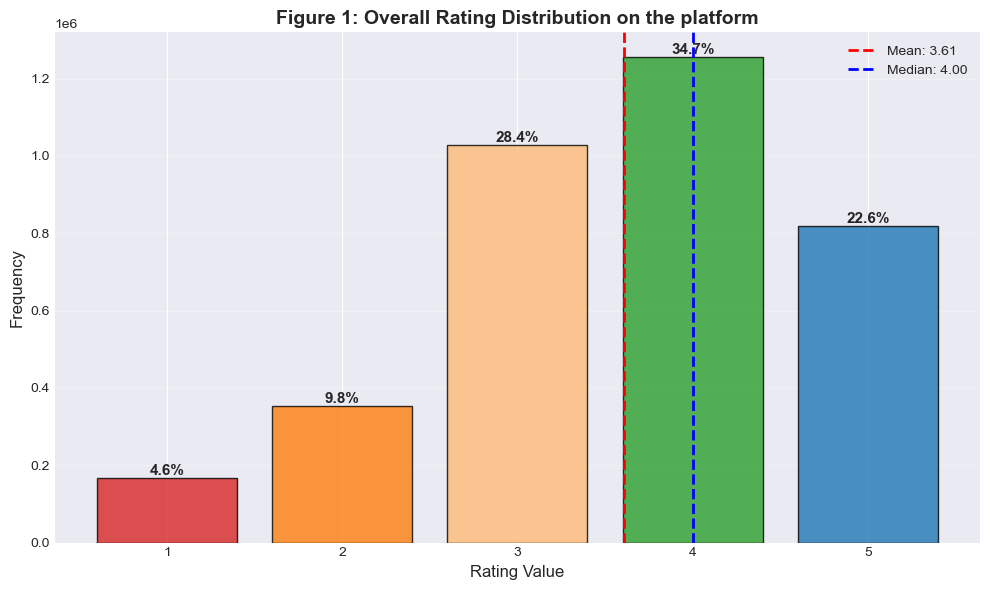

In [32]:
# 5.1.1 Overall Rating Distribution

import matplotlib.pyplot as plt
import seaborn as sns

rating_counts = ratings_with_movies['rating'].value_counts().sort_index()
total_ratings = len(ratings_with_movies)

for rating, count in rating_counts.items():
    pct = 100 * count / total_ratings

mean_rating = ratings_with_movies['rating'].mean()
median_rating = ratings_with_movies['rating'].median()

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

colors_ratings = ['#d62728', '#ff7f0e', '#ffbb78', '#2ca02c', '#1f77b4']
bars = ax.bar(rating_counts.index, rating_counts.values, alpha=0.8, edgecolor='black', color=colors_ratings)
ax.set_title('Figure 1: Overall Rating Distribution on the platform', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating Value', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_xticks(rating_counts.index)
ax.grid(True, alpha=0.3, axis='y')

# Add percentage labels on bars
for i, (rating, count) in enumerate(rating_counts.items()):
    pct = 100 * count / total_ratings
    ax.text(rating, count, f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add mean and median lines
ax.axvline(mean_rating, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_rating:.2f}')
ax.axvline(median_rating, color='blue', linestyle='--', linewidth=2, label=f'Median: {median_rating:.2f}')
ax.legend()

plt.tight_layout()
plt.show()

>Most ratings (34.7%) are 4 stars. Rating 3 is second most popular, more popular than 5. Ratings 2 and 1 are least popular.
>
>What it says about CONTENT:
>- Content quality is decent — few 1–2 star ratings.
>- Content is not exceptional — few 5-star ratings.
>- Users find content satisfactory but not outstanding.
>
>What it says about USERS:
>- Users are moderate raters — prefer middle ratings (3–4) over extremes.
>- Users are not very critical — few 1–2 star ratings.
>- Users are not overly enthusiastic — few 5-star ratings.
>- Users are likely average (not niche).

### 5.2 USER ANALYSIS (FOUNDATION)

#### 5.2.1 User Activity Segmentation

In [33]:
# 5.1.2 User Activity Segmentation

customer_stats = ratings_with_movies.groupby('customer_id').agg({
    'rating': ['count', 'mean', 'std'],
    'date': ['min', 'max'],
    'movie_id': 'nunique'
}).reset_index()

customer_stats.columns = ['customer_id', 'total_ratings', 'avg_rating_given', 'rating_std',
                         'first_rating_date', 'last_rating_date', 'unique_movies']

customer_stats['activity_days'] = (pd.to_datetime(customer_stats['last_rating_date']) - 
                                   pd.to_datetime(customer_stats['first_rating_date'])).dt.days + 1

# Segment users by activity level
customer_stats['activity_level'] = pd.cut(customer_stats['total_ratings'],
                                          bins=[0, 10, 50, 200, float('inf')],
                                          labels=['Low (1-10)', 'Medium (11-50)', 'High (51-200)', 'Very High (200+)'])

activity_dist = customer_stats['activity_level'].value_counts().sort_index()
for level, count in activity_dist.items():
    pct = 100 * count / len(customer_stats)

In [34]:
# Data preparation for visualizations
activity_ratings = customer_stats.groupby('activity_level')['avg_rating_given'].apply(list)
activity_colors = ['#aec7e8', '#98df8a', '#ffbb78', '#ff9896']

avg_by_activity = customer_stats.groupby('activity_level')['avg_rating_given'].agg(['mean', 'std', 'count'])
avg_by_activity['ci'] = 1.96 * avg_by_activity['std'] / np.sqrt(avg_by_activity['count'])  # 95% confidence interval

activity_dist = customer_stats['activity_level'].value_counts()


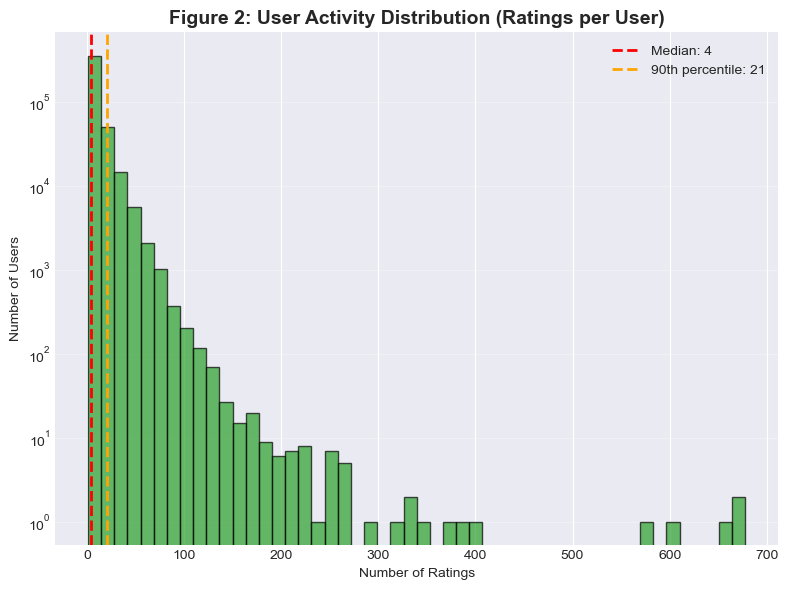

In [35]:
# Figure 2: User Activity Distribution (Histogram)
plt.figure(figsize=(8, 6))
plt.hist(customer_stats['total_ratings'], bins=50, edgecolor='black', alpha=0.7, color='#2ca02c')
plt.title('Figure 2: User Activity Distribution (Ratings per User)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.yscale('log')
plt.grid(True, alpha=0.3, axis='y')

# Adding percentiles
p25 = customer_stats['total_ratings'].quantile(0.25)
p50 = customer_stats['total_ratings'].quantile(0.50)
p75 = customer_stats['total_ratings'].quantile(0.75)
p90 = customer_stats['total_ratings'].quantile(0.90)

plt.axvline(p50, color='r', linestyle='--', linewidth=2, label=f'Median: {p50:.0f}')
plt.axvline(p90, color='orange', linestyle='--', linewidth=2, label=f'90th percentile: {p90:.0f}')
plt.legend()

plt.tight_layout()
plt.savefig('figure_2_user_activity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


**User Activity Distribution (Ratings per User)**

Distribution of how many ratings each user has given.

What it says about USERS:
- Strong long-tail distribution — most users have very few ratings (likely 1–5), while a small percentage have many.
- So most users are casual/occasional raters, not power users.
- The platform **relies heavily on a small group of active users for most of the rating activity**.


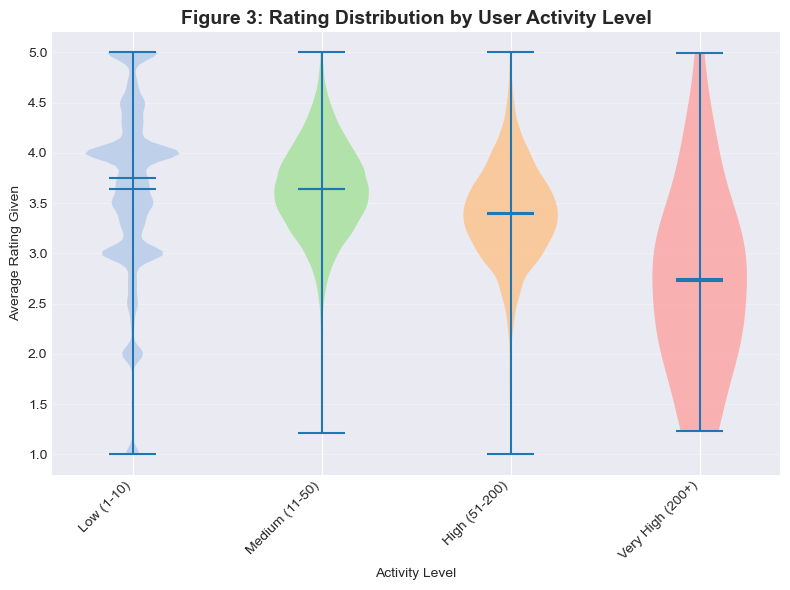

In [36]:
# Figure 3: Rating Distribution by User Activity Level (Violin Plot)
plt.figure(figsize=(8, 6))
violin_parts = plt.violinplot([activity_ratings[level] for level in activity_ratings.index], 
                             positions=range(len(activity_ratings)), showmeans=True, showmedians=True)

# Coloring the sections
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(activity_colors[i])
    pc.set_alpha(0.7)

plt.xticks(range(len(activity_ratings)), activity_ratings.index, rotation=45, ha='right')
plt.title('Figure 3: Rating Distribution by User Activity Level', fontsize=14, fontweight='bold')
plt.xlabel('Activity Level')
plt.ylabel('Average Rating Given')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figure_3_rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


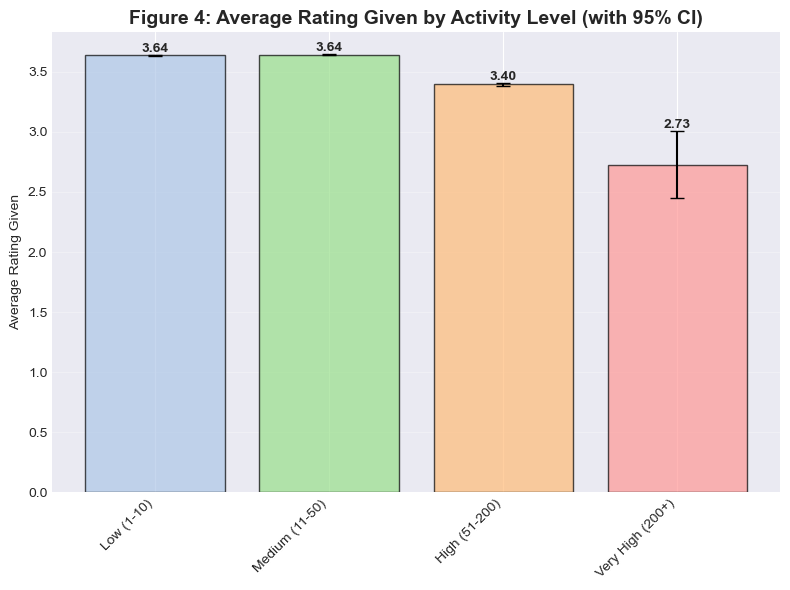

In [37]:
# Figure 4: Average Rating Given by Activity Level (Bar Chart with Error Bars)
plt.figure(figsize=(8, 6))
plt.bar(range(len(avg_by_activity)), avg_by_activity['mean'], 
        alpha=0.7, edgecolor='black', color=activity_colors, 
        yerr=avg_by_activity['ci'], capsize=5)

plt.xticks(range(len(avg_by_activity)), avg_by_activity.index, rotation=45, ha='right')
plt.title('Figure 4: Average Rating Given by Activity Level (with 95% CI)', 
          fontsize=14, fontweight='bold')
plt.ylabel('Average Rating Given')
plt.grid(True, alpha=0.3, axis='y')

# Adding mean values to the chart
for i, (idx, row) in enumerate(avg_by_activity.iterrows()):
    plt.text(i, row['mean'] + row['ci'], f"{row['mean']:.2f}", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('figure_4_avg_rating_by_activity.png', dpi=300, bbox_inches='tight')
plt.show()


**Rating Distribution by User Activity Level and Average Rating Level Given by Activity Level**

Shows how the distribution of ratings (1–5) differs across activity levels (Low, Medium, High, Very High).

What it says about USERS:
- In general, there is a tendency: the more active, the lower he/she rates content.
- Active users may rate differently than inactive users — they might be more critical (lower average) or more generous.
- If active users give more extreme ratings (more 1s and 5s), they are more opinionated.
- If active users give more middle ratings, they are more balanced/thoughtful.

---

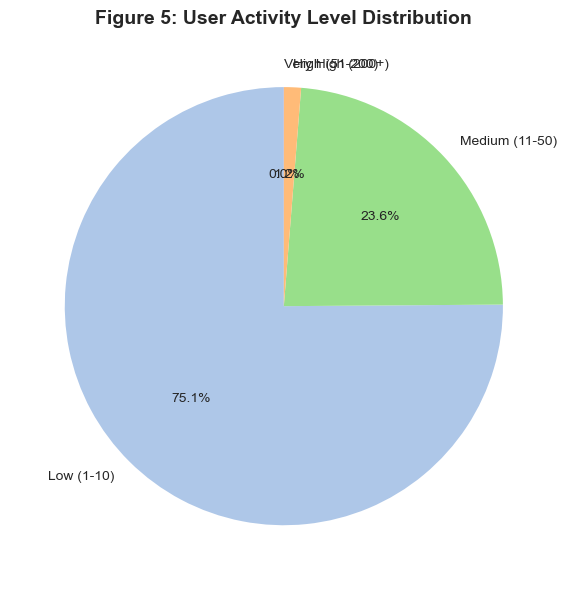

In [38]:
# Figure 5: User Activity Level Distribution (Pie Chart)
plt.figure(figsize=(8, 6))
plt.pie(activity_dist.values, labels=activity_dist.index, autopct='%1.1f%%', 
        colors=activity_colors, startangle=90)
plt.title('Figure 5: User Activity Level Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('figure_5_activity_level_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


---
**User Activity Level Distribution**

What it says about USERS:
- Most users(75%) have only a few ratings (1-10), 23.63% of users have 11-50 ratings. Only a few users are highly active. The platform has many casual users and few power users.

#### 5.2.2 User Behavior Patterns

**What we want to know**:
1. How consistent are users in their ratings? (Can we predict their preferences?)
2. What are the different user rating behavior segments? (Harsh vs lenient raters)
3. Do power users give more extreme ratings? (1s and 5s)

In [39]:
# 5.1.3 Rating Consistency and User Behavior Patterns

extreme_ratings = ratings_with_movies.groupby('customer_id').apply(
    lambda x: ((x['rating'] == 1).sum() + (x['rating'] == 5).sum()) / len(x) if len(x) > 0 else 0
).reset_index()
extreme_ratings.columns = ['customer_id', 'extreme_pct']
customer_stats = customer_stats.merge(extreme_ratings, on='customer_id', how='left')

# Segment users by rating behavior
customer_stats['rating_behavior'] = pd.cut(customer_stats['avg_rating_given'],
                                           bins=[0, 2.5, 3.5, 4.5, 5.1],
                                           labels=['Harsh (<2.5)', 'Moderate (2.5-3.5)', 'Positive (3.5-4.5)', 'Lenient (>4.5)'])

behavior_dist = customer_stats['rating_behavior'].value_counts().sort_index()
for behavior, count in behavior_dist.items():
    pct = 100 * count / len(customer_stats)


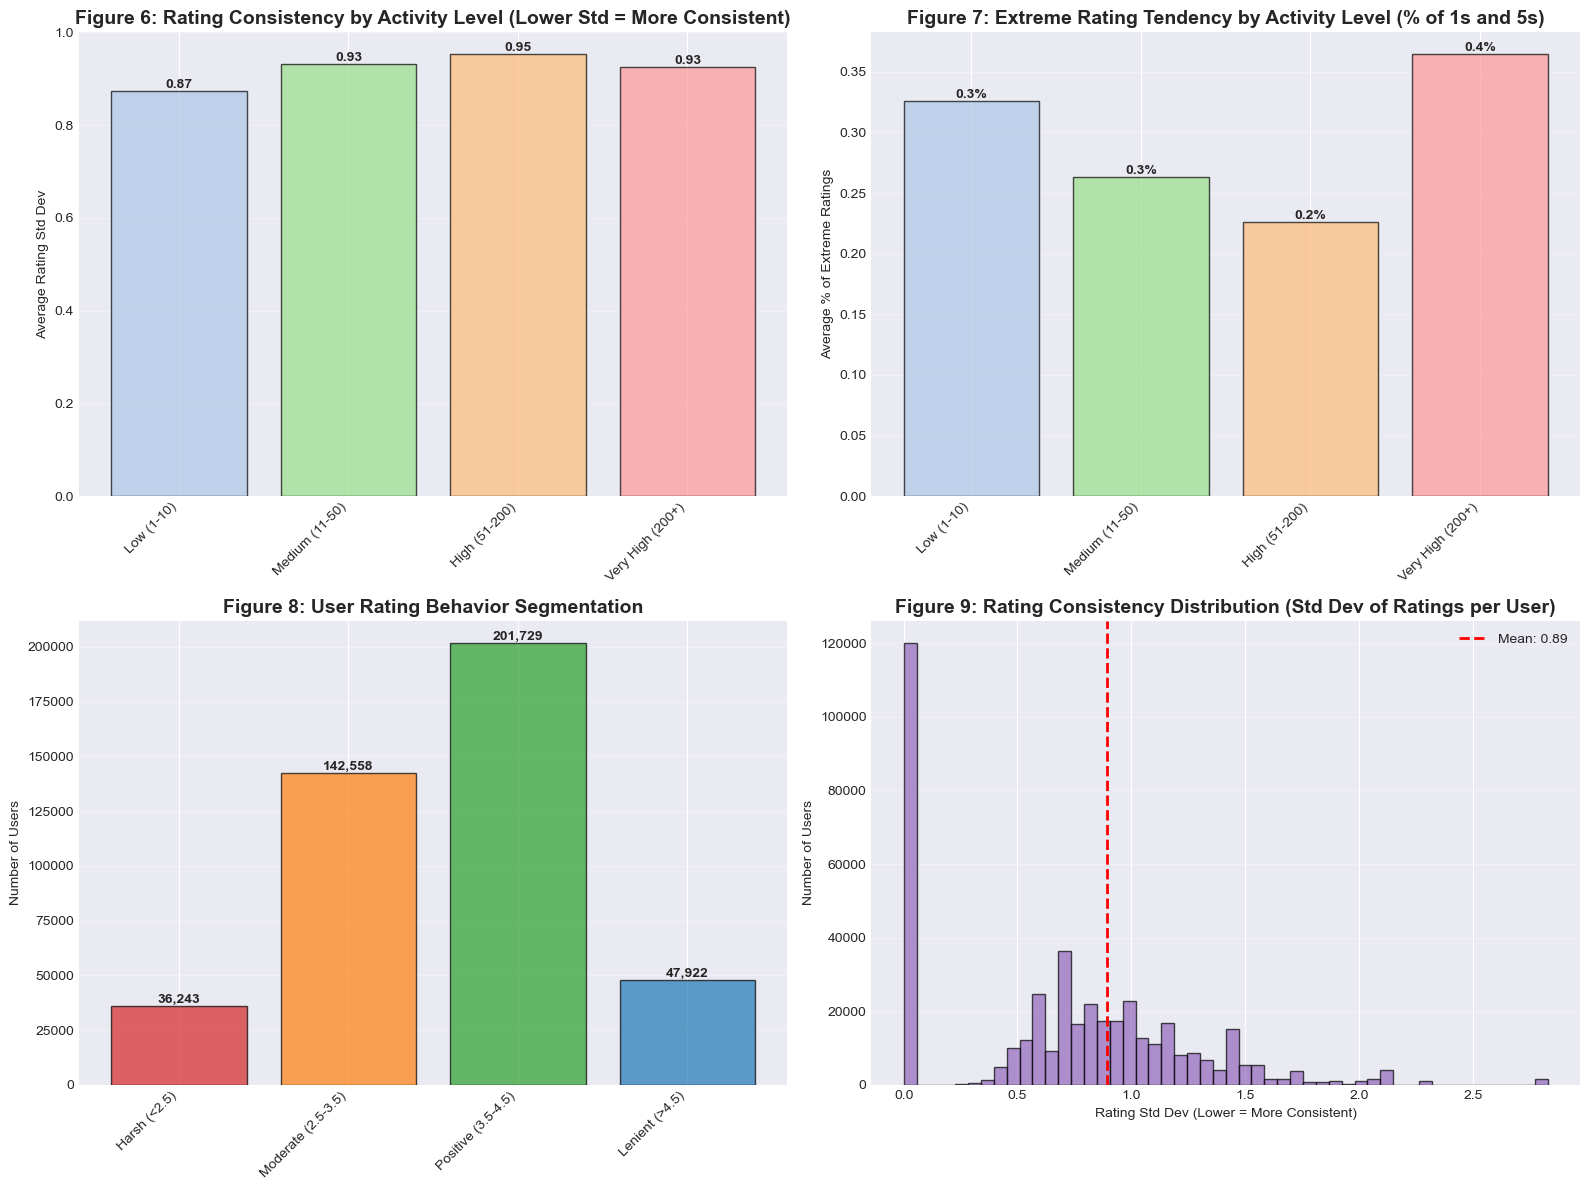

In [40]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Rating Consistency by Activity Level
consistency_by_activity = customer_stats.groupby('activity_level')['rating_std'].mean()
axes[0, 0].bar(range(len(consistency_by_activity)), consistency_by_activity.values, 
               alpha=0.7, edgecolor='black', color=activity_colors)
axes[0, 0].set_xticks(range(len(consistency_by_activity)))
axes[0, 0].set_xticklabels(consistency_by_activity.index, rotation=45, ha='right')
axes[0, 0].set_title('Figure 6: Rating Consistency by Activity Level (Lower Std = More Consistent)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Average Rating Std Dev')
axes[0, 0].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(consistency_by_activity.values):
    axes[0, 0].text(i, val, f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Extreme Rating Tendency by Activity Level
extreme_by_activity = customer_stats.groupby('activity_level')['extreme_pct'].mean()
axes[0, 1].bar(range(len(extreme_by_activity)), extreme_by_activity.values, 
               alpha=0.7, edgecolor='black', color=activity_colors)
axes[0, 1].set_xticks(range(len(extreme_by_activity)))
axes[0, 1].set_xticklabels(extreme_by_activity.index, rotation=45, ha='right')
axes[0, 1].set_title('Figure 7: Extreme Rating Tendency by Activity Level (% of 1s and 5s)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Average % of Extreme Ratings')
axes[0, 1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(extreme_by_activity.values):
    axes[0, 1].text(i, val, f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Rating Behavior Segmentation
behavior_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
axes[1, 0].bar(range(len(behavior_dist)), behavior_dist.values, 
               alpha=0.7, edgecolor='black', color=behavior_colors)
axes[1, 0].set_xticks(range(len(behavior_dist)))
axes[1, 0].set_xticklabels(behavior_dist.index, rotation=45, ha='right')
axes[1, 0].set_title('Figure 8: User Rating Behavior Segmentation', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Number of Users')
axes[1, 0].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(behavior_dist.values):
    axes[1, 0].text(i, val, f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. Rating Consistency Distribution
axes[1, 1].hist(customer_stats['rating_std'].fillna(0), bins=50, edgecolor='black', alpha=0.7, color='#9467bd')
axes[1, 1].set_title('Figure 9: Rating Consistency Distribution (Std Dev of Ratings per User)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Rating Std Dev (Lower = More Consistent)')
axes[1, 1].set_ylabel('Number of Users')
axes[1, 1].axvline(customer_stats['rating_std'].mean(), color='r', linestyle='--', linewidth=2, 
                   label=f'Mean: {customer_stats["rating_std"].mean():.2f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
# Figures 6-9
# Figures 6-9
plt.savefig('eda_5_1_3_rating_consistency.png', dpi=300, bbox_inches='tight')
plt.show()

**Rating Consistency by Activity Level**

Standard deviation of ratings (lower = more consistent) by activity level.

What it says about USERS:
- Users who left only a few ratings are more consistent preferences. For example, they could use The Platform to watch only movies of one category (e.g. only Harry Potter movies or only fantasy movies).
- The most active users prefer more diverse content as well as medium and high active users. This means that The Platform users, if they decide to stay on the platform and keep watching and rating, start exploring different movies but after a certain time they probably find balance between diversity and preferences.

---
**Extreme Rating Tendency by Activity Level**

Percentage of 1-star and 5-star ratings by activity level.

What it says about USERS:

- Active users give more extreme ratings - they are more opinionated/confident.
- Inactive users also give a lot of extreme ratings - they may be less thoughtful or more emotional.

---
**User Rating Behavior Segmentation** 

Graph shows the distribution of users across 4 categories based on their average rating.

What it says about USERS:
- Most users are generally satisfied but not overly enthusiastic

---
**Rating Consistency Distribution (Std Dev of Ratings per User)**

Histogram showing the distribution of rating consistency across all users

What it says about USERS:
- The distribution shows that the majority of users are consistent in their ratings, with a very low standard deviation (close to 0), indicating that they tend to give similar scores across different items. In contrast, inconsistent rating patterns (higher Std Dev values) are relatively rare.
- I explore potential reasons later in ... .

### 5.3 USER ANALYSIS (ADVANCED)

**Key Questions**:
1. How do users' rating patterns evolve over time? (Do they become more/less critical?)
2. Do users rate more movies as they become more active? (Engagement growth)
3. Are there power users who drive most of the ratings? (80/20 rule for users)
4. How do users discover new content? (Rating patterns over time)
5. Do users have rating preferences that change over time? (Temporal preferences)

#### 5.3.1 User Rating Evolution Over Time

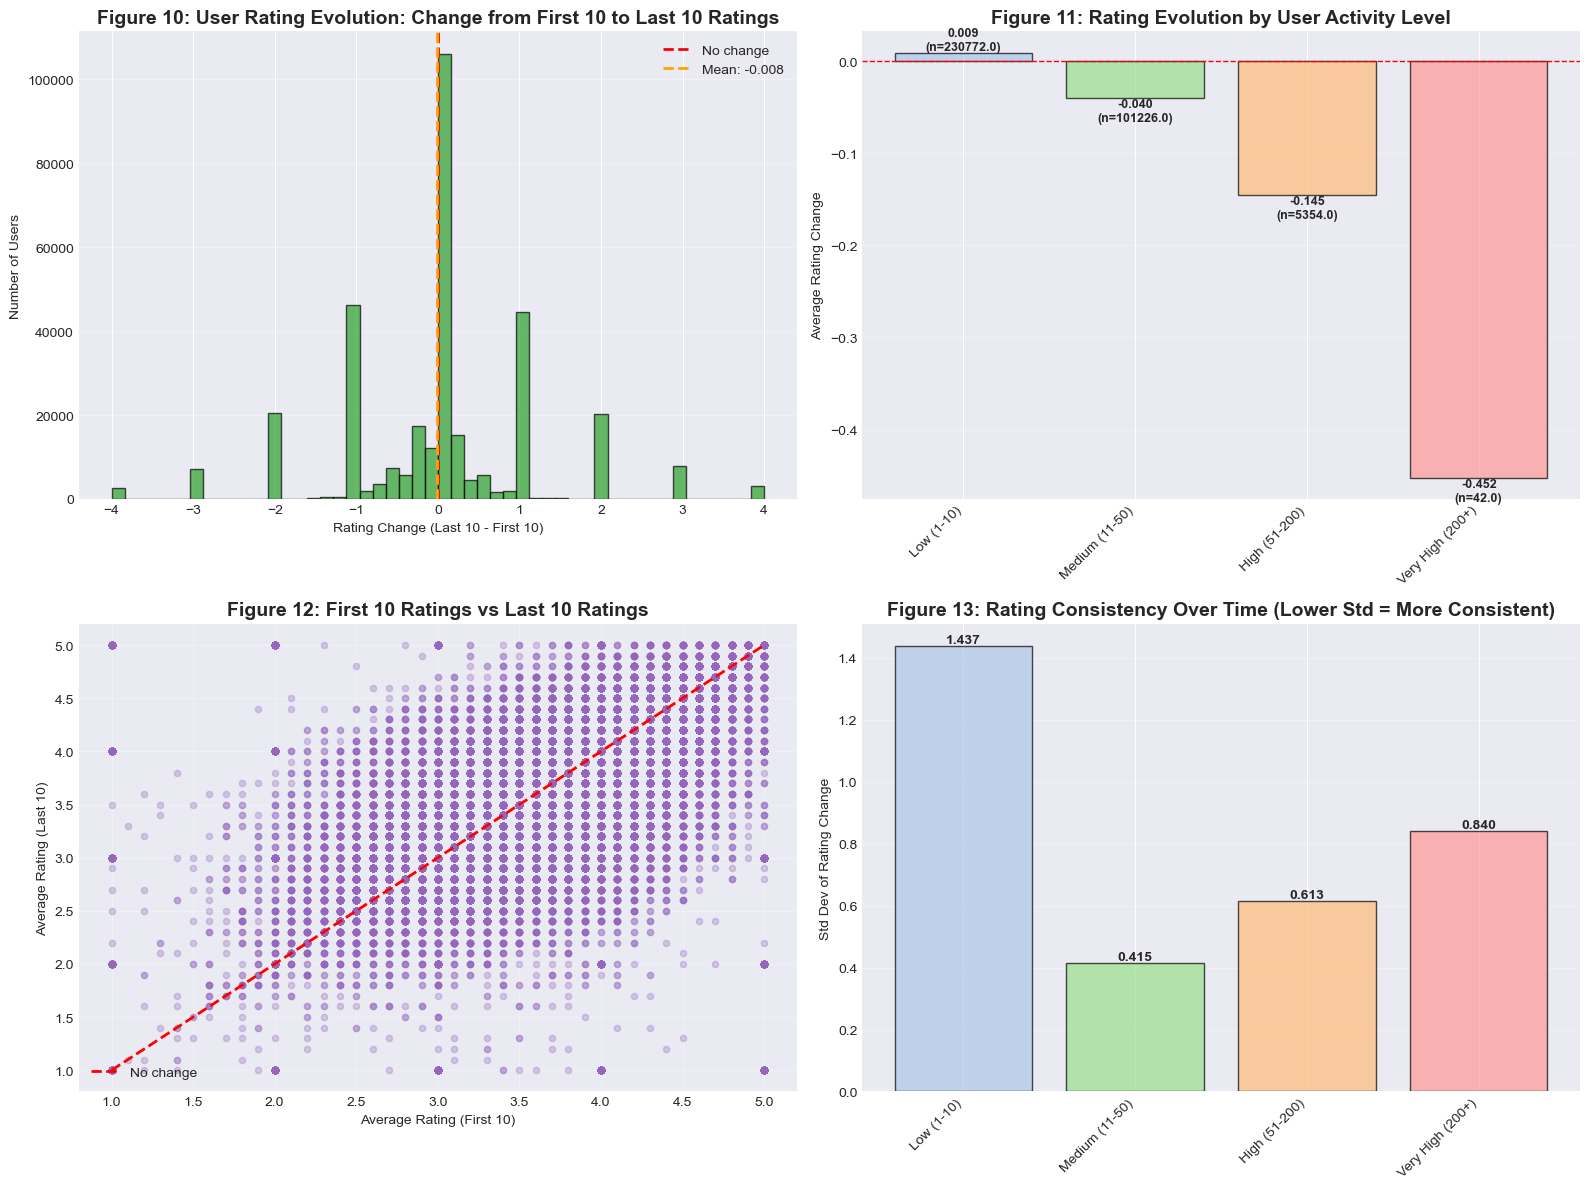

In [41]:
# 5.3.1 User Rating Evolution Over Time

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

user_ratings_sorted = ratings_with_movies.sort_values(['customer_id', 'date']).copy()


def calculate_user_evolution(group):
    """Calculate evolution metrics for a single user (vectorized)"""
    n_ratings = len(group)
    if n_ratings < 2:
        return None
    
    if n_ratings >= 10:
        first_10_avg = group.head(10)['rating'].mean()
        last_10_avg = group.tail(10)['rating'].mean()
        
        # Split into thirds
        third_size = n_ratings // 3
        first_third_avg = group.head(third_size)['rating'].mean()
        last_third_avg = group.tail(third_size)['rating'].mean()
        
        return pd.Series({
            'total_ratings': n_ratings,
            'first_10_avg': first_10_avg,
            'last_10_avg': last_10_avg,
            'first_third_avg': first_third_avg,
            'last_third_avg': last_third_avg,
            'rating_change': last_10_avg - first_10_avg,
            'rating_change_third': last_third_avg - first_third_avg,
            'days_active': (group['date'].max() - group['date'].min()).days
        })
    else:
        # For users with <10 ratings, use first and last
        first_avg = group.head(1)['rating'].values[0]
        last_avg = group.tail(1)['rating'].values[0]
        
        return pd.Series({
            'total_ratings': n_ratings,
            'first_10_avg': first_avg,
            'last_10_avg': last_avg,
            'first_third_avg': first_avg,
            'last_third_avg': last_avg,
            'rating_change': last_avg - first_avg,
            'rating_change_third': last_avg - first_avg,
            'days_active': (group['date'].max() - group['date'].min()).days
        })

# Use groupby.apply - much faster than iterating
user_evolution_df = user_ratings_sorted.groupby('customer_id').apply(
    calculate_user_evolution, 
    include_groups=False
).reset_index()

# Drop rows where calculation failed (users with <2 ratings)
user_evolution_df = user_evolution_df.dropna(subset=['total_ratings'])


# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Rating Change Distribution
axes[0, 0].hist(user_evolution_df['rating_change'], bins=50, edgecolor='black', alpha=0.7, color='#2ca02c')
axes[0, 0].axvline(0, color='r', linestyle='--', linewidth=2, label='No change')
axes[0, 0].axvline(user_evolution_df['rating_change'].mean(), color='orange', linestyle='--', linewidth=2, 
                   label=f'Mean: {user_evolution_df["rating_change"].mean():.3f}')
axes[0, 0].set_title('Figure 10: User Rating Evolution: Change from First 10 to Last 10 Ratings', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Rating Change (Last 10 - First 10)')
axes[0, 0].set_ylabel('Number of Users')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Rating Change by User Activity Level
user_evolution_df['activity_level'] = pd.cut(user_evolution_df['total_ratings'],
                                               bins=[0, 10, 50, 200, float('inf')],
                                               labels=['Low (1-10)', 'Medium (11-50)', 'High (51-200)', 'Very High (200+)'])
change_by_activity = user_evolution_df.groupby('activity_level')['rating_change'].agg(['mean', 'count'])
bars = axes[0, 1].bar(range(len(change_by_activity)), change_by_activity['mean'], 
                      alpha=0.7, edgecolor='black', color=['#aec7e8', '#98df8a', '#ffbb78', '#ff9896'])
axes[0, 1].set_xticks(range(len(change_by_activity)))
axes[0, 1].set_xticklabels(change_by_activity.index, rotation=45, ha='right')
axes[0, 1].set_title('Figure 11: Rating Evolution by User Activity Level', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Average Rating Change')
axes[0, 1].axhline(0, color='r', linestyle='--', linewidth=1)
axes[0, 1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, (idx, row) in enumerate(change_by_activity.iterrows()):
    axes[0, 1].text(i, row['mean'], f"{row['mean']:.3f}\n(n={row['count']})", 
                    ha='center', va='bottom' if row['mean'] >= 0 else 'top', fontsize=9, fontweight='bold')

# 3. First vs Last Rating Comparison (Scatter)
axes[1, 0].scatter(user_evolution_df['first_10_avg'], user_evolution_df['last_10_avg'], 
                  alpha=0.3, s=20, color='#9467bd')
# Add diagonal line (no change)
min_rating = min(user_evolution_df['first_10_avg'].min(), user_evolution_df['last_10_avg'].min())
max_rating = max(user_evolution_df['first_10_avg'].max(), user_evolution_df['last_10_avg'].max())
axes[1, 0].plot([min_rating, max_rating], [min_rating, max_rating], 'r--', linewidth=2, label='No change')
axes[1, 0].set_title('Figure 12: First 10 Ratings vs Last 10 Ratings', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Average Rating (First 10)')
axes[1, 0].set_ylabel('Average Rating (Last 10)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Rating Consistency Over Time (by activity level)
consistency_by_activity = user_evolution_df.groupby('activity_level')['rating_change'].std()
axes[1, 1].bar(range(len(consistency_by_activity)), consistency_by_activity.values, 
               alpha=0.7, edgecolor='black', color=['#aec7e8', '#98df8a', '#ffbb78', '#ff9896'])
axes[1, 1].set_xticks(range(len(consistency_by_activity)))
axes[1, 1].set_xticklabels(consistency_by_activity.index, rotation=45, ha='right')
axes[1, 1].set_title('Figure 13: Rating Consistency Over Time (Lower Std = More Consistent)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Std Dev of Rating Change')
axes[1, 1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(consistency_by_activity.values):
    axes[1, 1].text(i, val, f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
# Figures 10-13
# Figures 10-13
plt.savefig('eda_5_3_1_rating_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

**User Rating Evolution: Change from First 10 to Last 10 Ratings (Histogram)**

This graph shows the distribution of rating changes (calculated as «Last 10 ratings – First 10 ratings») for users, indicating how user opinions evolve over time.

What it says about USERS:
- On average, users’ ratings remain stable over time — there’s no significant shift in their overall sentiment.
- The peak at «0» (no change) indicates that most users maintain consistent rating patterns — their initial impressions largely align with their later ones.
- A few users show significant changes (both positive and negative), but these are outliers. This implies that dramatic shifts in opinion are rare.
- The symmetry around the «0» mark suggests balanced evolution — as many users slightly increase their ratings as those who decrease them.

---

**Rating Evolution by User Activity Level (Bar Chart)**

This graph compares the average rating change (Last 10 – First 10) across different user activity levels (number of ratings).

What it says about USERS:

- Low-activity users (1–10 ratings) show almost no change (0.009), likely because they haven’t formed strong evolving opinions.
- As users gain experience, their ratings tend to decrease slightly, reflecting growing sophistication.
- High-volume raters act as «quality filters» — their opinions may be more reliable due to broader exposure.

---

**First 10 Ratings vs Last 10 Ratings (Scatter Plot with Trend Line)**

This scatter plot compares the average of first 10 ratings with the average of last 10 ratings for each user, with a trend line showing the relationship.

What it says about USERS:
- The positive trend line (close to 45-degree angle) indicates that users who started with high ratings tend to end with high ratings, and vice versa.
- There’s a moderate correlation between initial and final rating patterns — early behaviour predicts later behaviour.
- Some scatter around the line shows individual variability — not all users follow the trend perfectly.
- Users with very high initial ratings (4.5–5.0) tend to slightly reduce their ratings over time, aligning with the «becoming more critical» pattern seen in the previous graph.
- Initial rating patterns are somewhat predictive of long-term behaviour.
- There’s a natural «calibration» process — users adjust their standards over time.

---

**Rating Consistency Over Time (Bar Chart — Std Dev of Rating Change)**

This graph measures consistency in rating evolution (lower standard deviation = more consistent change) across user activity levels.

What it says about USERS:
- Novice users need time to develop a stable rating system.
- Moderately active users strike the best balance between experience and consistency.
- Highly active users have refined standards but may encounter more diverse content, leading to varied ratings.
- Consistency is a sign of developed criteria: the more a user rates, the more their patterns stabilize — until a certain threshold where diversity of content introduces new variability.


#### 5.3.2 User Engagement Patterns

**What we want to know**:
1. Are there power users who drive most of the ratings? (80/20 rule for users)
2. How is user engagement distributed? (Long-tail vs power users)
3. Do engaged users rate differently? (Quality vs quantity)
4. What percentage of users are highly engaged? (Retention opportunity)

**Why this matters**:
- Power users drive content discovery and engagement
- Understanding engagement distribution helps with user segmentation
- Highly engaged users should be rewarded and retained
- Engagement patterns inform recommendation strategies

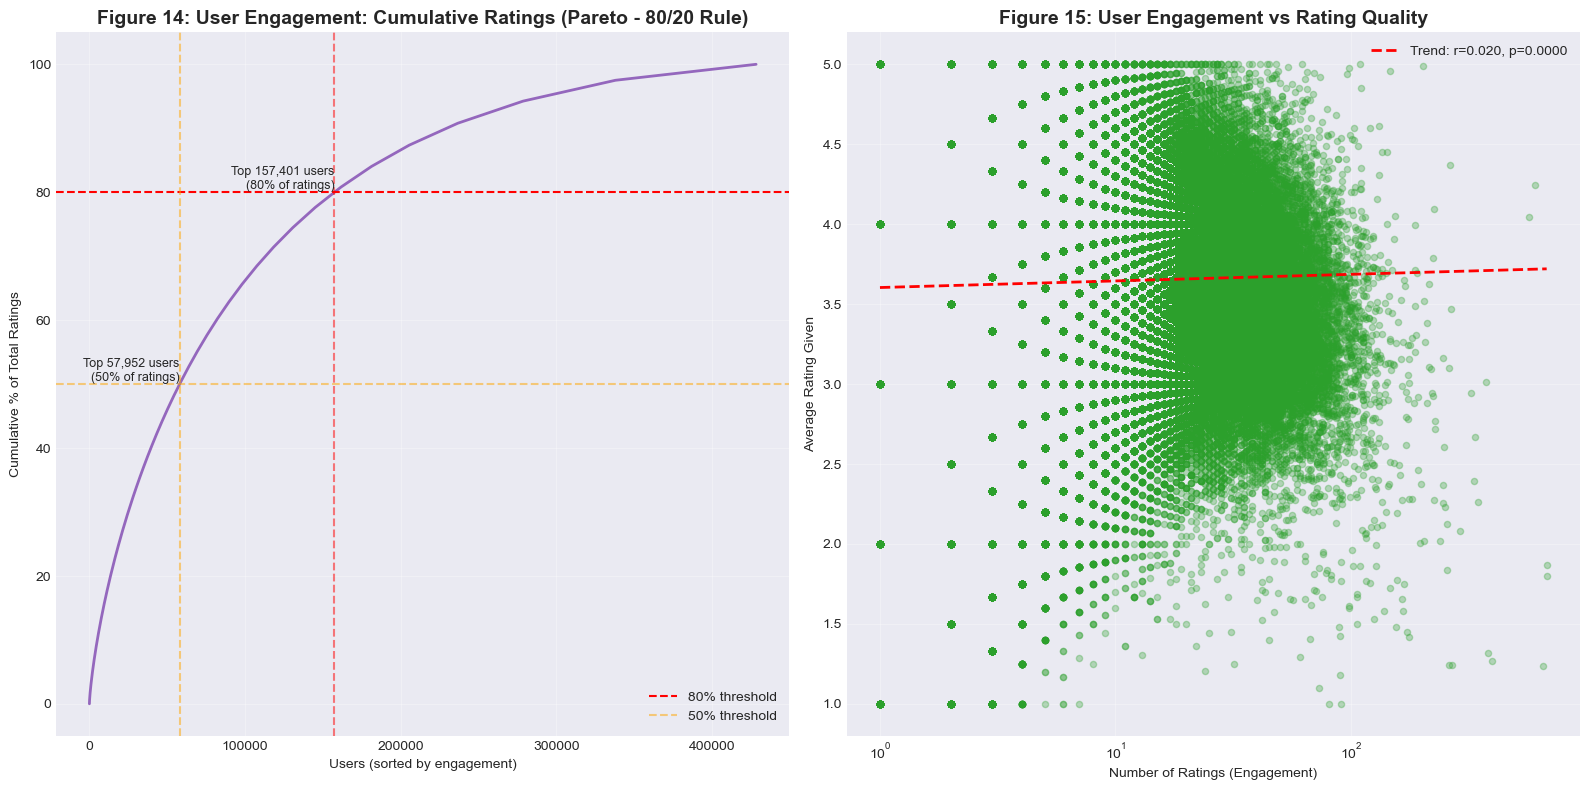

In [42]:
# 5.3.2 User Engagement Patterns

user_engagement = ratings_with_movies.groupby('customer_id').agg({
    'rating': ['count', 'mean', 'std'],
    'date': ['min', 'max'],
    'movie_id': 'nunique'
}).reset_index()

user_engagement.columns = ['customer_id', 'total_ratings', 'avg_rating', 'rating_std',
                          'first_rating_date', 'last_rating_date', 'unique_movies']

user_engagement['days_active'] = (user_engagement['last_rating_date'] - user_engagement['first_rating_date']).dt.days
user_engagement['ratings_per_day'] = user_engagement['total_ratings'] / user_engagement['days_active'].clip(lower=1)

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. User Engagement: Cumulative Ratings (Pareto - 80/20 Rule)
sorted_users = user_engagement.sort_values('total_ratings', ascending=False)
sorted_users['cumulative_pct'] = 100 * sorted_users['total_ratings'].cumsum() / sorted_users['total_ratings'].sum()
axes[0].plot(range(len(sorted_users)), sorted_users['cumulative_pct'], linewidth=2, color='#9467bd')
axes[0].axhline(80, color='r', linestyle='--', label='80% threshold')
axes[0].axhline(50, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
p80_idx = (sorted_users['cumulative_pct'] <= 80).sum()
p50_idx = (sorted_users['cumulative_pct'] <= 50).sum()
axes[0].axvline(p80_idx, color='r', linestyle='--', alpha=0.5)
axes[0].axvline(p50_idx, color='orange', linestyle='--', alpha=0.5)
axes[0].set_title('Figure 14: User Engagement: Cumulative Ratings (Pareto - 80/20 Rule)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Users (sorted by engagement)')
axes[0].set_ylabel('Cumulative % of Total Ratings')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].text(p80_idx, 80, f'Top {p80_idx:,} users\n(80% of ratings)', ha='right', va='bottom', fontsize=9)
axes[0].text(p50_idx, 50, f'Top {p50_idx:,} users\n(50% of ratings)', ha='right', va='bottom', fontsize=9)

# 2. Engagement vs Rating Quality (Scatter)
axes[1].scatter(user_engagement['total_ratings'], user_engagement['avg_rating'], 
                  alpha=0.3, s=20, color='#2ca02c')
axes[1].set_title('Figure 15: User Engagement vs Rating Quality', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Ratings (Engagement)')
axes[1].set_ylabel('Average Rating Given')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)
# Add trend line
from scipy import stats
mask = ~(user_engagement['total_ratings'].isna() | user_engagement['avg_rating'].isna())
if mask.sum() > 1:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        np.log(user_engagement.loc[mask, 'total_ratings'] + 1), 
        user_engagement.loc[mask, 'avg_rating']
    )
    x_trend = np.logspace(0, np.log10(user_engagement['total_ratings'].max()), 100)
    y_trend = slope * np.log(x_trend) + intercept
    axes[1].plot(x_trend, y_trend, 'r--', linewidth=2, 
                   label=f'Trend: r={r_value:.3f}, p={p_value:.4f}')
    axes[1].legend()

plt.tight_layout()
# Figures 14-15
# Figures 14-15
plt.savefig('eda_5_3_2_engagement_patterns.png', dpi=300, bbox_inches='tight')
plt.show()


**User Engagement: Cumulative Ratings (Pareto - 80/20 Rule)**

What the graph shows: What percentage of users generate 80% of all ratings.

What it says about USERS:
- The majority of ratings (80%) come from a relatively small proportion of users (around 157,000 out of 400,000). 
- The curve shows that the first users make the largest contribution, and as the number of users grows, the increase in their cumulative contribution slows down.
- Core of active users: the first 57,952 users (approximately 14% of the total) generate half of all ratings. This is the «core» of the platform — the most engaged users. The platform should motivate them to stay active.
- Audience segmentation: three groups can be identified:
     1. Core (Top 57,952) — highest activity.
     2. Active periphery (57,952–157,401) — significant but lower contribution.
     3. Passive users (over 157,401) — low engagement level.

---

**User Engagement vs Rating Quality**

Scatter plot showing if more engaged users give higher or lower average ratings.

What it says about USERS:
- The near-zero correlation (r = 0.020) proves that how many ratings a user gives does not influence the quality (value) of those ratings. Highly active users are just as likely to give low or high ratings as less active ones.
- User engagement (quantity of ratings) and rating quality (average rating value) are essentially unrelated.
- The Platform cannot rely on user activity level to predict rating reliability or «quality»

###5.4 USER PORTRAIT

### 5.5 CONTENT ANALYSIS

#### 5.5.1 Movie Popularity and Long-Tail Distribution

**What we want to know**:
1. What is the popularity distribution of movies? (Long-tail vs blockbusters?)
2. Are there 'hidden gems' - movies with high ratings but low popularity?
3. Does the platform follow the 80/20 rule? (Top 20% of movies get 80% of ratings?)

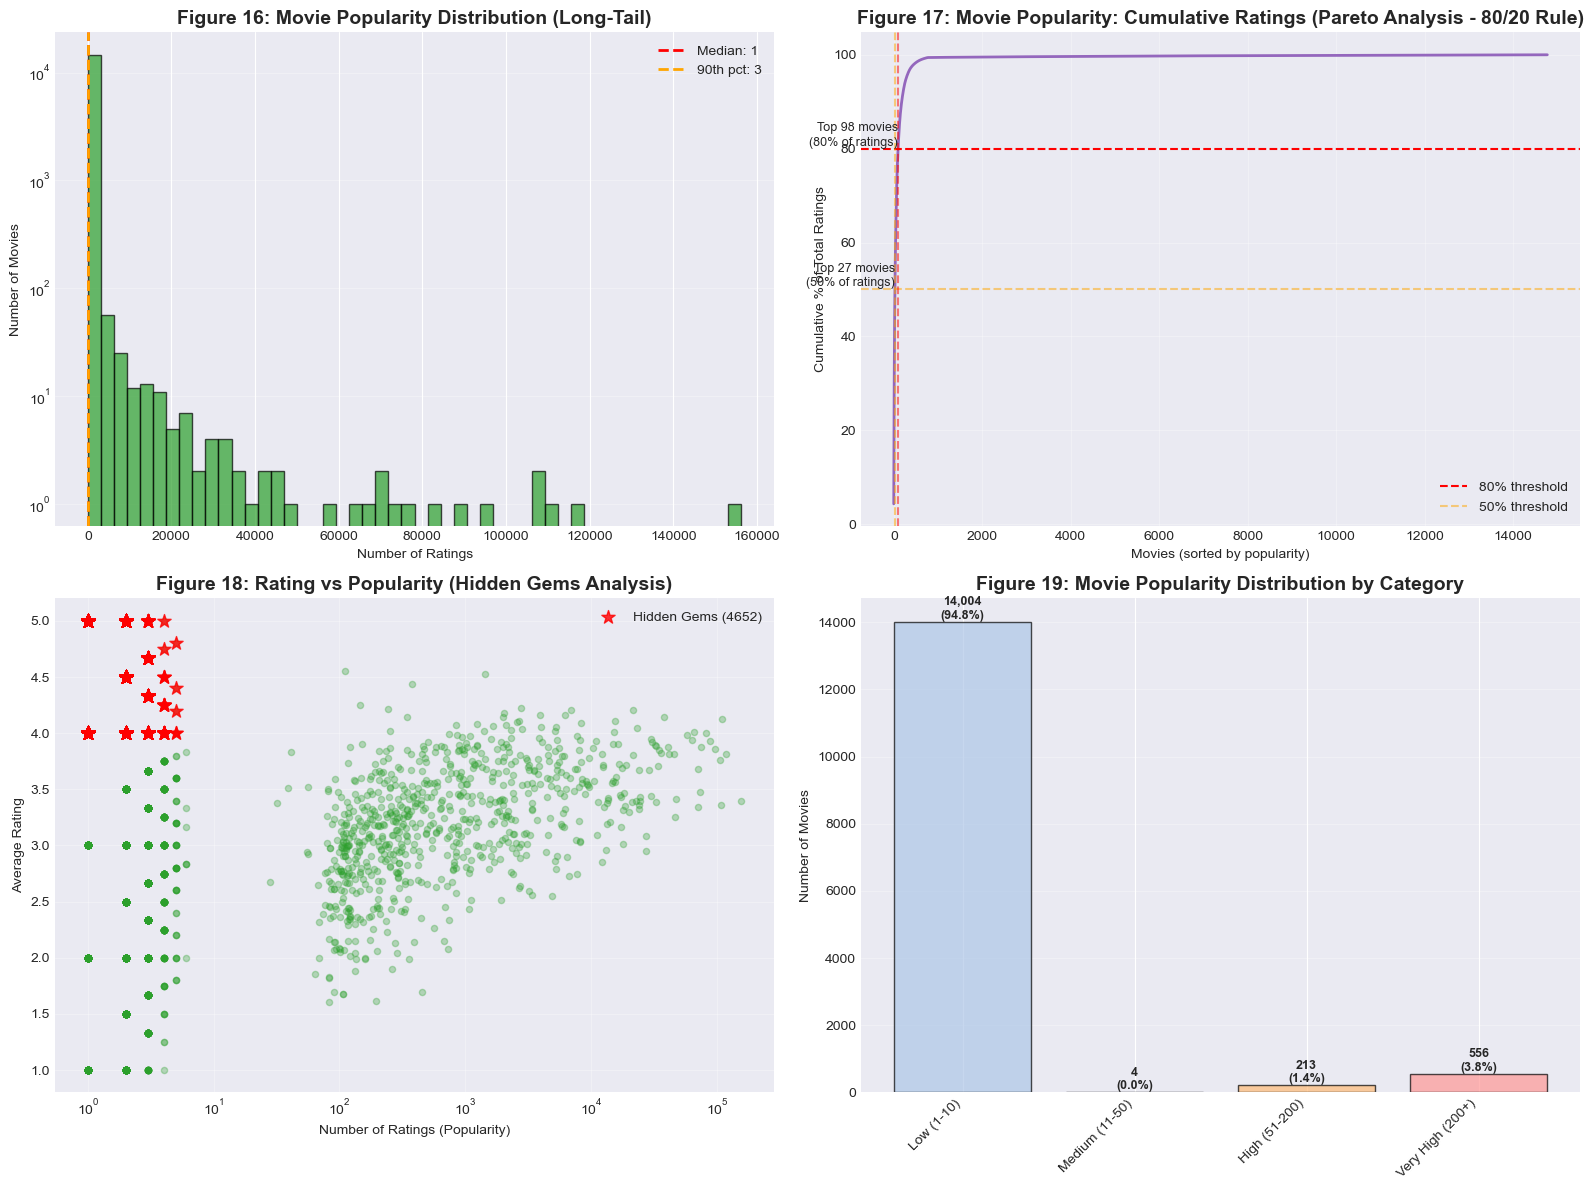

In [43]:
# 5.2.1 Movie Popularity and Long-Tail Distribution

import matplotlib.pyplot as plt
import seaborn as sns

movie_stats = ratings_with_movies.groupby('movie_id').agg({
    'rating': ['count', 'mean', 'std', 'min', 'max'],
    'date': ['min', 'max'],
    'customer_id': 'nunique',
    'year_of_release': 'first',
    'title': 'first'
}).reset_index()

movie_stats.columns = ['movie_id', 'total_ratings', 'avg_rating', 'rating_std',
                      'min_rating', 'max_rating', 'first_rating_date', 'last_rating_date',
                      'unique_users', 'year_of_release', 'title']


# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Movie Popularity Distribution (Long-Tail)
axes[0, 0].hist(movie_stats['total_ratings'], bins=50, edgecolor='black', alpha=0.7, color='#2ca02c')
axes[0, 0].set_title('Figure 16: Movie Popularity Distribution (Long-Tail)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Ratings')
axes[0, 0].set_ylabel('Number of Movies')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3, axis='y')
# Add percentiles
p50 = movie_stats['total_ratings'].quantile(0.50)
p90 = movie_stats['total_ratings'].quantile(0.90)
axes[0, 0].axvline(p50, color='r', linestyle='--', linewidth=2, label=f'Median: {p50:.0f}')
axes[0, 0].axvline(p90, color='orange', linestyle='--', linewidth=2, label=f'90th pct: {p90:.0f}')
axes[0, 0].legend()

sorted_movies = movie_stats.sort_values('total_ratings', ascending=False)
sorted_movies['cumulative_pct'] = 100 * sorted_movies['total_ratings'].cumsum() / sorted_movies['total_ratings'].sum()
axes[0, 1].plot(range(len(sorted_movies)), sorted_movies['cumulative_pct'], linewidth=2, color='#9467bd')
axes[0, 1].axhline(80, color='r', linestyle='--', label='80% threshold')
axes[0, 1].axhline(50, color='orange', linestyle='--', alpha=0.5, label='50% threshold')
p80_idx = (sorted_movies['cumulative_pct'] <= 80).sum()
p50_idx = (sorted_movies['cumulative_pct'] <= 50).sum()
axes[0, 1].axvline(p80_idx, color='r', linestyle='--', alpha=0.5)
axes[0, 1].axvline(p50_idx, color='orange', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Movies (sorted by popularity)')
axes[0, 1].set_ylabel('Cumulative % of Total Ratings')
axes[0, 1].set_title('Figure 17: Movie Popularity: Cumulative Ratings (Pareto Analysis - 80/20 Rule)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].text(p80_idx, 80, f'Top {p80_idx} movies\n(80% of ratings)', ha='right', va='bottom', fontsize=9)
axes[0, 1].text(p50_idx, 50, f'Top {p50_idx} movies\n(50% of ratings)', ha='right', va='bottom', fontsize=9)

# 3. Rating vs Popularity (Scatter Plot - Hidden Gems)
axes[1, 0].scatter(movie_stats['total_ratings'], movie_stats['avg_rating'], 
                  alpha=0.3, s=20, color='#2ca02c')
axes[1, 0].set_xlabel('Number of Ratings (Popularity)')
axes[1, 0].set_ylabel('Average Rating')
axes[1, 0].set_title('Figure 18: Rating vs Popularity (Hidden Gems Analysis)', fontsize=14, fontweight='bold')
axes[1, 0].set_xscale('log')
axes[1, 0].grid(True, alpha=0.3)
# Identify hidden gems (high rating, low popularity)
hidden_gems = movie_stats[(movie_stats['avg_rating'] >= 4.0) & (movie_stats['total_ratings'] <= 50)]
if len(hidden_gems) > 0:
    axes[1, 0].scatter(hidden_gems['total_ratings'], hidden_gems['avg_rating'], 
                      alpha=0.8, s=100, color='red', marker='*', label=f'Hidden Gems ({len(hidden_gems)})')
    axes[1, 0].legend()

# 4. Popularity Distribution (Bar Chart by Category)
popularity_categories = pd.cut(movie_stats['total_ratings'],
                               bins=[0, 10, 50, 200, float('inf')],
                               labels=['Low (1-10)', 'Medium (11-50)', 'High (51-200)', 'Very High (200+)'])
pop_counts = popularity_categories.value_counts().sort_index()
colors_pop = ['#aec7e8', '#98df8a', '#ffbb78', '#ff9896']
axes[1, 1].bar(range(len(pop_counts)), pop_counts.values, alpha=0.7, edgecolor='black', color=colors_pop)
axes[1, 1].set_xticks(range(len(pop_counts)))
axes[1, 1].set_xticklabels(pop_counts.index, rotation=45, ha='right')
axes[1, 1].set_title('Figure 19: Movie Popularity Distribution by Category', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Number of Movies')
axes[1, 1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(pop_counts.values):
    pct = 100 * val / len(movie_stats)
    axes[1, 1].text(i, val, f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
# Figures 16-19
# Figures 16-19
plt.savefig('eda_5_2_1_movie_popularity.png', dpi=300, bbox_inches='tight')
plt.show()




**Movie Popularity Distribution (Long-Tail)**


Distribution of how many ratings each movie has received.

What it says about MOVIES:

- Strong long-tail — most movies have very few ratings, while a small percentage are very popular so most content is niche, few items are blockbusters.
- The platform has a diverse catalog with many less-known movies.

---

**Figure 2: Movie Popularity - Cumulative Ratings (Pareto Analysis - 80/20 Rule)**

Line plot showing cumulative percentage of total ratings. The curve shows how many top movies (by popularity) generate what percentage of all ratings. Tests whether the 80/20 rule applies.

What it says about MOVIES:


- Movie ratings are highly skewed. A handful of blockbuster or cult movies dominate user engagement. 80/20 Rule in Action: The data perfectly illustrates the Pareto Principle: 20% of movies (98 out of ~14,000) drive 80% of the ratings.
- Platforms can allocate marketing, curation, and data analysis resources more efficiently by focusing on the «vital few» (top 98 movies). 
- The remaining 80% of movies (with 20% of ratings) can still be monetized through niche targeting or personalized recommendations.


---

**Rating vs Popularity (Hidden Gems Analysis)**

Scatter plot with popularity (number of ratings) on x-axis (log scale) and average rating on y-axis. Red stars mark "hidden gems" - movies with high ratings (≥4.0) but low popularity (≤50 ratings).

What it says about MOVIES:
- Negative correlation trend: As popularity increases, average ratings tend to decrease. This is a classic «long-tail» phenomenon:
     Head (high popularity): Mass appeal but lower average satisfaction.
     Tail (low popularity): Niche appeal with higher average satisfaction.
- The Platform should prioritize «hidden gems» to diversify user experiences and surface underrated items.
- Content creators should nalyze why hidden gems have low popularity despite high ratings (e.g., poor discoverability, niche audience).

---

**Movie Popularity Distribution by Category**

Bar chart showing how many movies fall into each popularity category: Low (1-10 ratings), Medium (11-50), High (51-200), Very High (200+ ratings). Shows percentages for each category.

What it says about MOVIES:
- Most movies (94.8%) have 1-10 ratings - strong long-tail, most content is niche.

#### 5.5.2 Content Freshness and Release Strategy

**What we want to know**:
1. How does movie age (years since release) affect ratings? (Content freshness effect)
2. Do newer movies get better ratings than older movies?
3. Is there an optimal movie age for ratings? (Sweet spot)

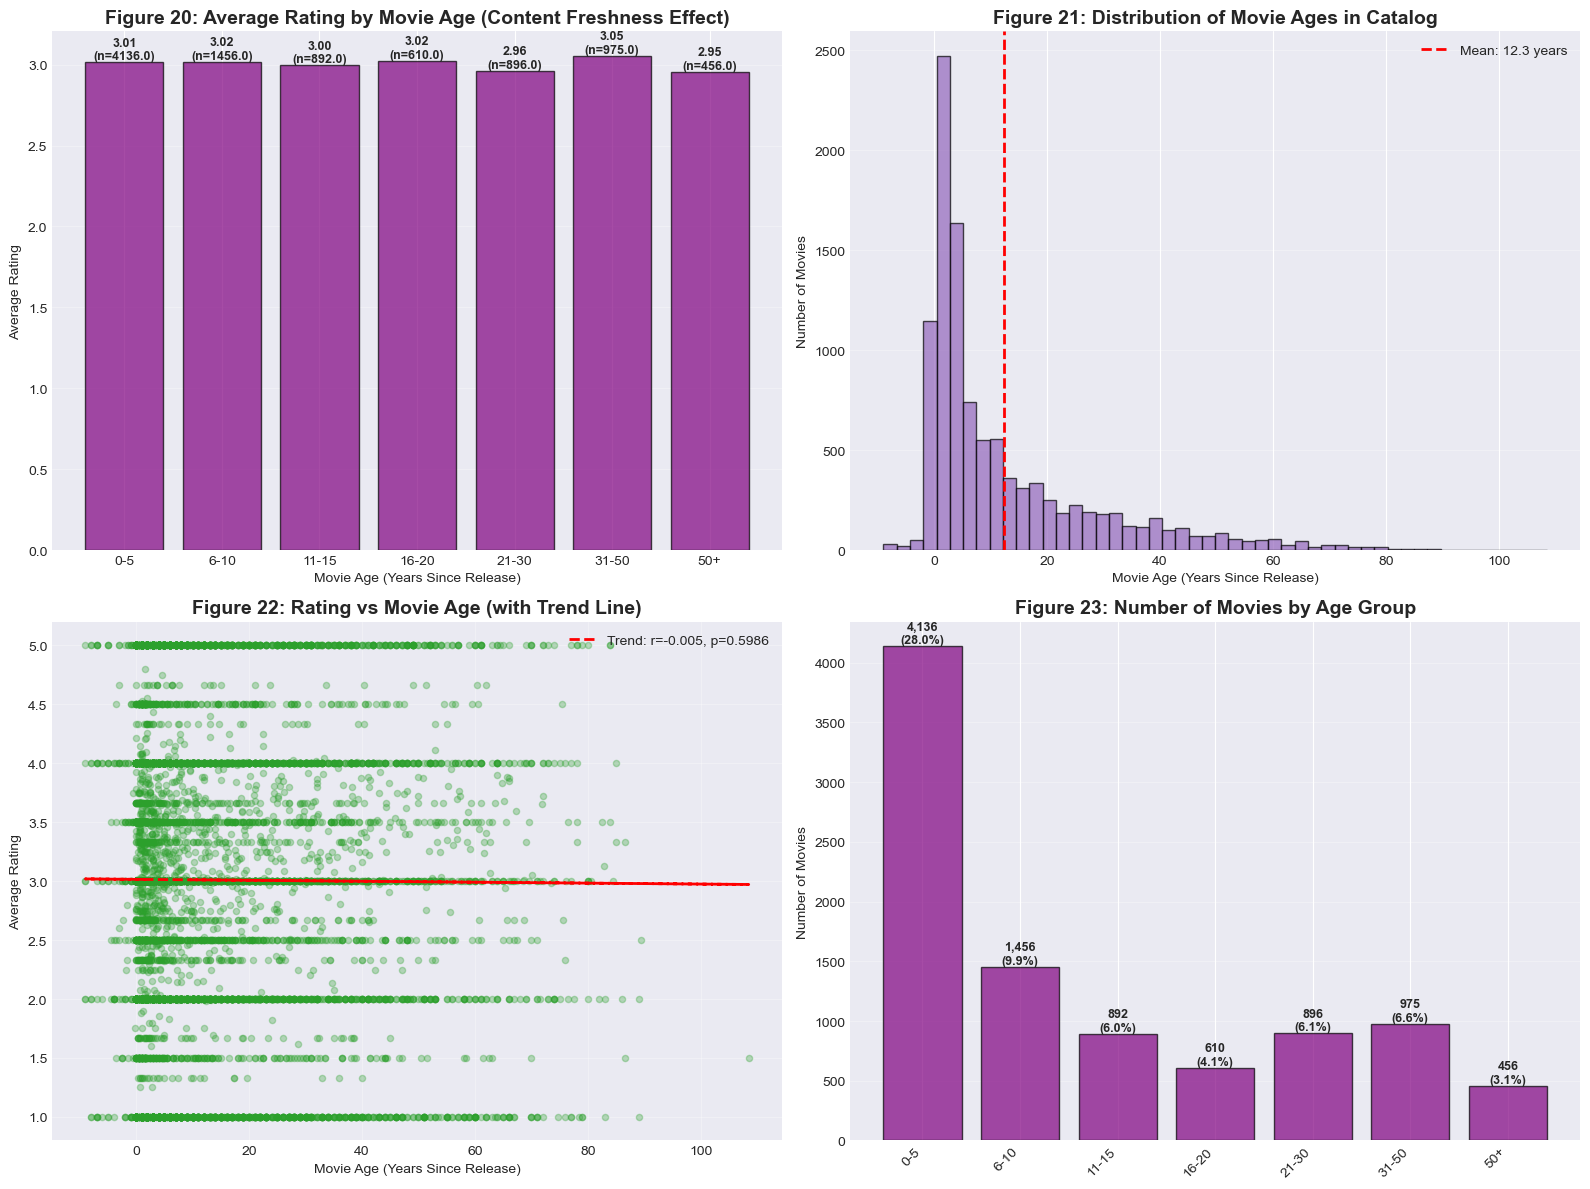

In [44]:
# 5.2.2 Content Freshness and Release Strategy

ratings_with_movies['movie_age'] = ratings_with_movies['date'].dt.year - ratings_with_movies['year_of_release']

movie_age_avg = ratings_with_movies.groupby('movie_id')['movie_age'].mean().reset_index()
movie_age_avg.columns = ['movie_id', 'avg_movie_age']
movie_stats = movie_stats.merge(movie_age_avg, on='movie_id', how='left')


# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Rating by Movie Age (Content Freshness Effect)
movie_stats['age_group'] = pd.cut(movie_stats['avg_movie_age'], 
                                  bins=[0, 5, 10, 15, 20, 30, 50, 100],
                                  labels=['0-5', '6-10', '11-15', '16-20', '21-30', '31-50', '50+'])
age_rating = movie_stats.groupby('age_group')['avg_rating'].agg(['mean', 'count'])
bars = axes[0, 0].bar(range(len(age_rating)), age_rating['mean'], alpha=0.7, edgecolor='black', color='purple')
axes[0, 0].set_xticks(range(len(age_rating)))
axes[0, 0].set_xticklabels(age_rating.index)
axes[0, 0].set_title('Figure 20: Average Rating by Movie Age (Content Freshness Effect)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Movie Age (Years Since Release)')
axes[0, 0].set_ylabel('Average Rating')
axes[0, 0].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, (idx, row) in enumerate(age_rating.iterrows()):
    axes[0, 0].text(i, row['mean'], f"{row['mean']:.2f}\n(n={row['count']})", 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Movie Age Distribution
axes[0, 1].hist(movie_stats['avg_movie_age'], bins=50, edgecolor='black', alpha=0.7, color='#9467bd')
axes[0, 1].set_title('Figure 21: Distribution of Movie Ages in Catalog', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Movie Age (Years Since Release)')
axes[0, 1].set_ylabel('Number of Movies')
axes[0, 1].axvline(movie_stats['avg_movie_age'].mean(), color='r', linestyle='--', linewidth=2, 
                   label=f'Mean: {movie_stats["avg_movie_age"].mean():.1f} years')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Rating vs Movie Age (Scatter with Trend)
axes[1, 0].scatter(movie_stats['avg_movie_age'], movie_stats['avg_rating'], 
                  alpha=0.3, s=20, color='#2ca02c')
# Add trend line
from scipy import stats
mask = ~(movie_stats['avg_movie_age'].isna() | movie_stats['avg_rating'].isna())
if mask.sum() > 1:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        movie_stats.loc[mask, 'avg_movie_age'], 
        movie_stats.loc[mask, 'avg_rating']
    )
    x_trend = movie_stats.loc[mask, 'avg_movie_age']
    y_trend = slope * x_trend + intercept
    axes[1, 0].plot(x_trend, y_trend, 'r--', linewidth=2, 
                   label=f'Trend: r={r_value:.3f}, p={p_value:.4f}')
    axes[1, 0].legend()
axes[1, 0].set_title('Figure 22: Rating vs Movie Age (with Trend Line)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Movie Age (Years Since Release)')
axes[1, 0].set_ylabel('Average Rating')
axes[1, 0].grid(True, alpha=0.3)

# 4. Movie Count by Age Group
age_counts = movie_stats['age_group'].value_counts().sort_index()
axes[1, 1].bar(range(len(age_counts)), age_counts.values, alpha=0.7, edgecolor='black', color='purple')
axes[1, 1].set_xticks(range(len(age_counts)))
axes[1, 1].set_xticklabels(age_counts.index, rotation=45, ha='right')
axes[1, 1].set_title('Figure 23: Number of Movies by Age Group', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Number of Movies')
axes[1, 1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(age_counts.values):
    pct = 100 * val / len(movie_stats)
    axes[1, 1].text(i, val, f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
# Figures 20-23
# Figures 20-23
plt.savefig('eda_5_2_2_content_freshness.png', dpi=300, bbox_inches='tight')
plt.show()

**Average Rating by Movie Age (Content Freshness Effect)**

How average ratings vary by movie release year.

What it says about MOVIES:
- No clear trend → Movie age doesn't strongly affect rating.

---

**Movie Age Distribution and Number of Movies by Age Group**

What it says about MOVIES:
- The majority of movies is new.

---
**Rating vs Movie Age (Scatter with Trend)**

The relationship between a movie’s average rating (on a scale from 1.0 to 5.0) and its age (number of years since release, ranging from 0 to 100+ years).

What it says about MOVIES:
- No correlation between a movie’s age and its rating. The statistical analysis (with a Pearson correlation coefficient of r ≈ –0.005 and a p-value of 0.5986, which exceeds the typical threshold of statistical significance at 0.05) and the visual representation confirm that the age of a film does not influence its user ratings.
- When recommending films, age should not be a consideration.



#### 5.2.3 Movie Rating Patterns

**What we want to know**:
1. Do popular movies get better or worse ratings? (Popularity vs quality)
2. Which movies are controversial? (High rating variance - love/hate)
3. How consistent are movie ratings? (Can we predict movie quality?)
4. Do popular movies have more consistent ratings? (Lower variance?)

**Why this matters**:
- Popular movies may be more polarizing (love/hate)
- Controversial movies drive engagement but need careful recommendation
- Rating consistency affects recommendation confidence
- Understanding these patterns helps with content curation and recommendation strategies

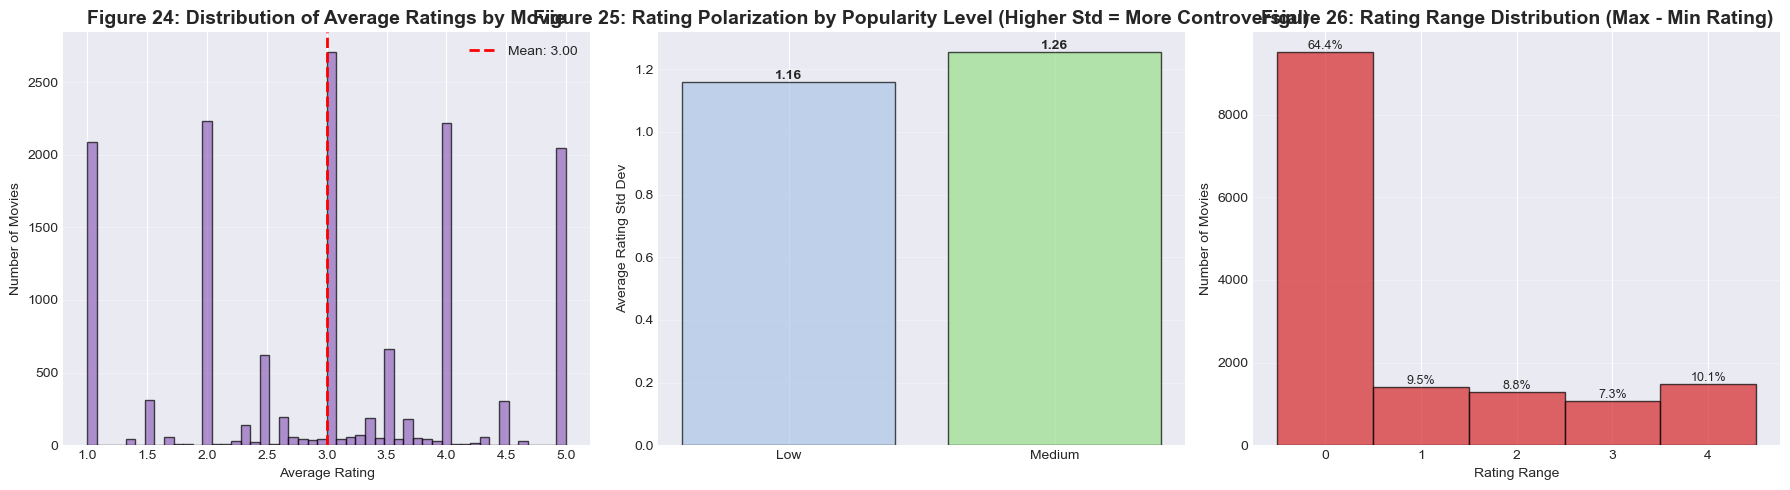

In [45]:
# 5.2.3 Movie Rating Patterns
movie_stats['rating_range'] = movie_stats['max_rating'] - movie_stats['min_rating']
movie_stats['rating_polarization'] = movie_stats['rating_std']  # Higher std = more polarized
movie_stats['rating_consistency'] = 1 / (movie_stats['rating_std'].fillna(0) + 0.1)

# Segment movies by popularity (using quantiles with duplicate handling)
quantiles = movie_stats['total_ratings'].quantile([0, 0.25, 0.5, 0.75, 1.0])
quantiles_unique = sorted(list(set(quantiles)))
if len(quantiles_unique) >= 2:
    n_bins = len(quantiles_unique) - 1
    all_labels = ['Low', 'Medium', 'High', 'Very High']
    labels = all_labels[:n_bins] if n_bins <= 4 else all_labels + ['Extra'] * (n_bins - 4)
    movie_stats['popularity_level'] = pd.cut(movie_stats['total_ratings'], bins=quantiles_unique, 
                                                      labels=labels, include_lowest=True, duplicates='drop')
else:
    movie_stats['popularity_level'] = pd.cut(movie_stats['total_ratings'], 
                                                      bins=[0, 10, 50, 200, float('inf')], 
                                                      labels=['Low', 'Medium', 'High', 'Very High'])


# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Average Rating Distribution by Movie
axes[0].hist(movie_stats['avg_rating'], bins=50, edgecolor='black', alpha=0.7, color='#9467bd')
axes[0].set_title('Figure 24: Distribution of Average Ratings by Movie', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Number of Movies')
axes[0].axvline(movie_stats['avg_rating'].mean(), color='r', linestyle='--', linewidth=2, 
                   label=f'Mean: {movie_stats["avg_rating"].mean():.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Rating Polarization by Popularity Level
polarization_by_pop = movie_stats.groupby('popularity_level')['rating_std'].mean()
axes[1].bar(range(len(polarization_by_pop)), polarization_by_pop.values, 
               alpha=0.7, edgecolor='black', color=['#aec7e8', '#98df8a', '#ffbb78', '#ff9896'])
axes[1].set_xticks(range(len(polarization_by_pop)))
axes[1].set_xticklabels(polarization_by_pop.index)
axes[1].set_title('Figure 25: Rating Polarization by Popularity Level (Higher Std = More Controversial)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Rating Std Dev')
axes[1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(polarization_by_pop.values):
    axes[1].text(i, val, f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Rating Range Distribution (Controversial Movies)
axes[2].hist(movie_stats['rating_range'], bins=range(0, 6), edgecolor='black',
                alpha=0.7, color='#d62728', align='left')
axes[2].set_title('Figure 26: Rating Range Distribution (Max - Min Rating)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Rating Range')
axes[2].set_ylabel('Number of Movies')
axes[2].set_xticks(range(5))
axes[2].grid(True, alpha=0.3, axis='y')
# Add percentage labels
range_counts = movie_stats['rating_range'].value_counts().sort_index()
for i, (range_val, count) in enumerate(range_counts.items()):
    pct = 100 * count / len(movie_stats)
    axes[2].text(range_val, count, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
# Figures 24-26
# Figures 24-26
plt.savefig('eda_5_2_3_rating_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

**Distribution of Average Ratings by Movie**

This graph shows the distribution of average ratings assigned to movies (on a scale from 1.0 to 5.0), revealing how many movies fall into each rating range.

What it says about MOVIES:
- The average rating centres around 3.0, as indicated by the mean (marked with a red dotted line). This suggests that the majority of movies are perceived as «average» or «satisfactory» by viewers.

What it says about USERS:
- Viewers tend to be moderate in their ratings, avoiding the extremes of 1 or 5.

---

**Rating Range Distribution (Max – Min Rating)**

This histogram shows the spread of ratings for each movie (difference between the highest and lowest ratings).

What it says about MOVIES:
- 64.4% of movies have a rating range of 0, meaning viewers largely agree on their quality — there’s little divergence between the highest and lowest scores.

What it says about USERS:
- Viewers generally agree on the quality of most films, suggesting either homogeneous tastes or a lack of strong emotional reactions.

---
**Rating Polarization by Popularity Level**

This chart compares the standard deviation (Std Dev) of ratings for low- and medium-popularity movies, where higher Std Dev indicates more polarised opinions.

What it says about MOVIES:
- Medium-popularity movies (Std Dev = 1.26) are more polarising than less popular ones (Std Dev = 1.16).
- Popularity correlates with divergent opinions — the more people watch a film, the more likely it is to divide audiences.
- Less popular movies tend to have more consistent ratings, possibly because they attract a niche audience with similar tastes.

What it says about USERS:
- Mass appeal often comes with divided opinions — users have diverse expectations and reactions to widely watched films.
- Niche or lesser-known movies tend to attract like-minded viewers who share similar criteria for what makes a «good» film.


### 5.4 PLATFORM ANALYSIS

**What we're doing**: Understand platform health, growth trajectory, and data quality patterns.

**Key Questions**:
1. Is the platform growing? (increasing total ratings)
2. Is content quality improving? (increasing average ratings)
3. Are there seasonal patterns in ratings?
4. Do newer movies rate better than older movies?
5. What do anomalous dates represent? (data quality or special events?)

**Why this matters**: 
- Growth trends are critical for investor reports and strategic planning
- Seasonal patterns affect content release timing and recommendation strategies
- Rating trends by release year guide content acquisition strategy
- Anomalous dates may represent special events that need special handling

#### 5.4.1 Platform Growth Trends

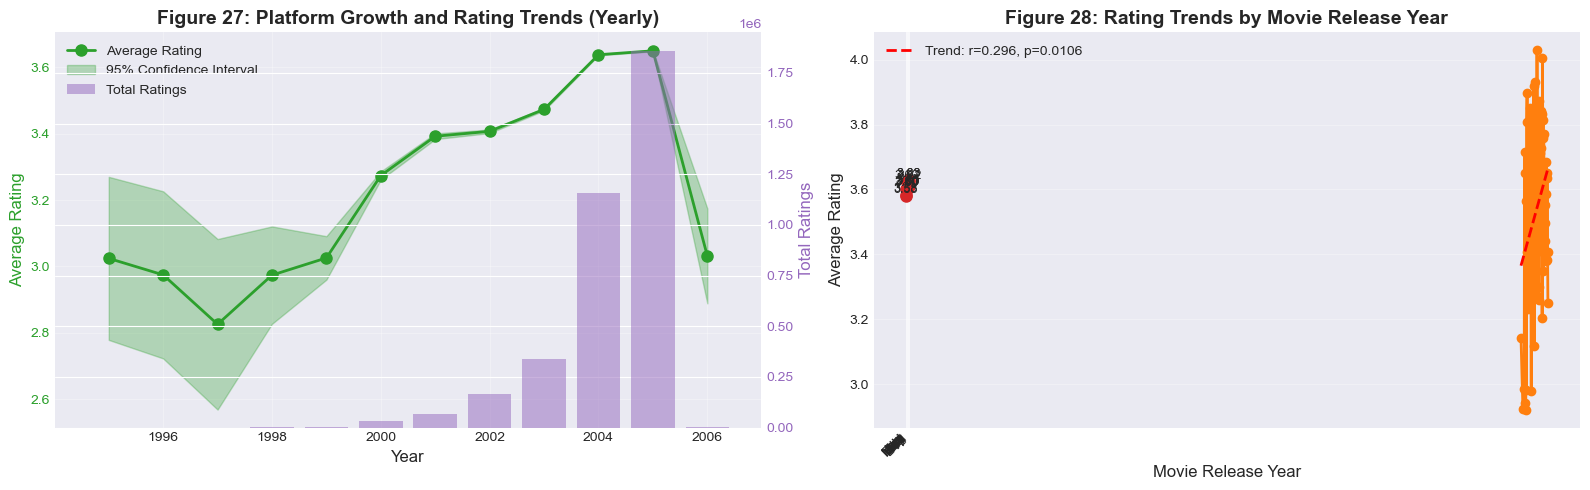

In [46]:
# 5.4.1 Platform Growth Trends

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Prepare temporal data
ratings_with_movies['year'] = ratings_with_movies['date'].dt.year
ratings_with_movies['month'] = ratings_with_movies['date'].dt.month

# Yearly metrics
yearly_metrics = ratings_with_movies.groupby('year').agg({
    'rating': ['count', 'mean', 'std'],
    'customer_id': 'nunique',
    'movie_id': 'nunique'
}).reset_index()
yearly_metrics.columns = ['year', 'total_ratings', 'avg_rating', 'rating_std', 'unique_users', 'unique_movies']

yearly_metrics['rating_se'] = yearly_metrics['rating_std'] / np.sqrt(yearly_metrics['total_ratings'])
yearly_metrics['rating_ci_lower'] = yearly_metrics['avg_rating'] - 1.96 * yearly_metrics['rating_se']
yearly_metrics['rating_ci_upper'] = yearly_metrics['avg_rating'] + 1.96 * yearly_metrics['rating_se']


# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Platform Growth and Rating Trends (Yearly) - Plot 1 from 5.4
ax1 = axes[0]
ax1_twin = ax1.twinx()

# Primary axis: Average rating per year (line with confidence intervals)
line = ax1.plot(yearly_metrics['year'], yearly_metrics['avg_rating'], 
                linewidth=2, marker='o', markersize=8, color='#2ca02c', label='Average Rating')
ax1.fill_between(yearly_metrics['year'], yearly_metrics['rating_ci_lower'], yearly_metrics['rating_ci_upper'],
                alpha=0.3, color='#2ca02c', label='95% Confidence Interval')

# Secondary axis: Total ratings per year (bars)
bars = ax1_twin.bar(yearly_metrics['year'], yearly_metrics['total_ratings'], 
                    alpha=0.5, color='#9467bd', label='Total Ratings')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Average Rating', fontsize=12, color='#2ca02c')
ax1_twin.set_ylabel('Total Ratings', fontsize=12, color='#9467bd')
ax1.set_title('Figure 27: Platform Growth and Rating Trends (Yearly)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='y', labelcolor='#2ca02c')
ax1_twin.tick_params(axis='y', labelcolor='#9467bd')

# Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 2. Seasonal Patterns in Ratings (Average rating by month across all years)
monthly_rating = ratings_with_movies.groupby('month')['rating'].mean().reset_index()
monthly_rating.columns = ['month', 'avg_rating']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_rating['month_name'] = monthly_rating['month'].apply(lambda x: month_names[x-1])

axes[1].plot(range(len(monthly_rating)), monthly_rating['avg_rating'], 
             linewidth=2, marker='o', markersize=8, color='#d62728')
axes[1].set_xticks(range(len(monthly_rating)))
axes[1].set_xticklabels(monthly_rating['month_name'], rotation=45, ha='right')
axes[1].set_title('Figure 33: Seasonal Patterns in Ratings\n(Average Rating by Month)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Rating')
axes[1].grid(True, alpha=0.3)
# Add value labels
for i, val in enumerate(monthly_rating['avg_rating']):
    axes[1].text(i, val, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

# 3. Rating Trends by Movie Release Year
release_year_ratings = ratings_with_movies.groupby('year_of_release')['rating'].agg(['mean', 'count']).reset_index()
release_year_ratings.columns = ['release_year', 'avg_rating', 'count']
# Filter to years with sufficient ratings (at least 100)
release_year_ratings = release_year_ratings[release_year_ratings['count'] >= 100].sort_values('release_year')

axes[1].plot(release_year_ratings['release_year'], release_year_ratings['avg_rating'], 
             linewidth=2, marker='o', markersize=6, color='#ff7f0e')
axes[1].set_xlabel('Movie Release Year', fontsize=12)
axes[1].set_ylabel('Average Rating', fontsize=12)
axes[1].set_title('Figure 28: Rating Trends by Movie Release Year', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
# Add trend line
if len(release_year_ratings) > 1:
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        release_year_ratings['release_year'], release_year_ratings['avg_rating']
    )
    trend_line = slope * release_year_ratings['release_year'] + intercept
    axes[1].plot(release_year_ratings['release_year'], trend_line, 'r--', linewidth=2, 
                label=f'Trend: r={r_value:.3f}, p={p_value:.4f}')
    axes[1].legend()

plt.tight_layout()
# Figures 27-28
# Figures 27-28
plt.savefig('eda_5_4_1_platform_growth_trends.png', dpi=300, bbox_inches='tight')
plt.show()

**Platform Growth and Rating Trends (Yearly)**

Total ratings and average ratings over time.

What it says about PLATFORM:
- Initial phase (1996–1998): the total number of ratings was minimal, indicating a small user base. The Platform was in its infancy, facing growing pains such as bugs, limited features, or a lack of moderation.
- Stabilization and growth (2000–2004):  the number of total ratings slowly climbed. Improvement in average rating: the average rating recovered and steadily rose to a peak of 3.6 in 2004, indicating improved user satisfaction. The green shaded area became tighter, suggesting more consistent user feedback.
- Peak (2004): 2004 was the «golden year» — the platform successfully balanced scale and quality.
- Decline phase (2005–2006): sharp decrease in user activity. But we should remember that the dates after 2005 are anomalies dates and should not be trusted.

**Seasonal Patterns in Ratings (Average Rating by Month)**

The graph illustrates the average rating trend throughout the year, broken down by month.

What it says about USERS:
- There is a easonal pattern in user ratings, with two distinct peaks (April and September) and two notable dips (January–February and May).

**Rating Trends by Movie Release Year**

Average rating for movies grouped by their release year.

What it says about MOVIES:
- On average, newer movies tend to receive slightly higher ratings than older ones. This is a weak but statistically significant upward trend in movie ratings over the 20th century. 


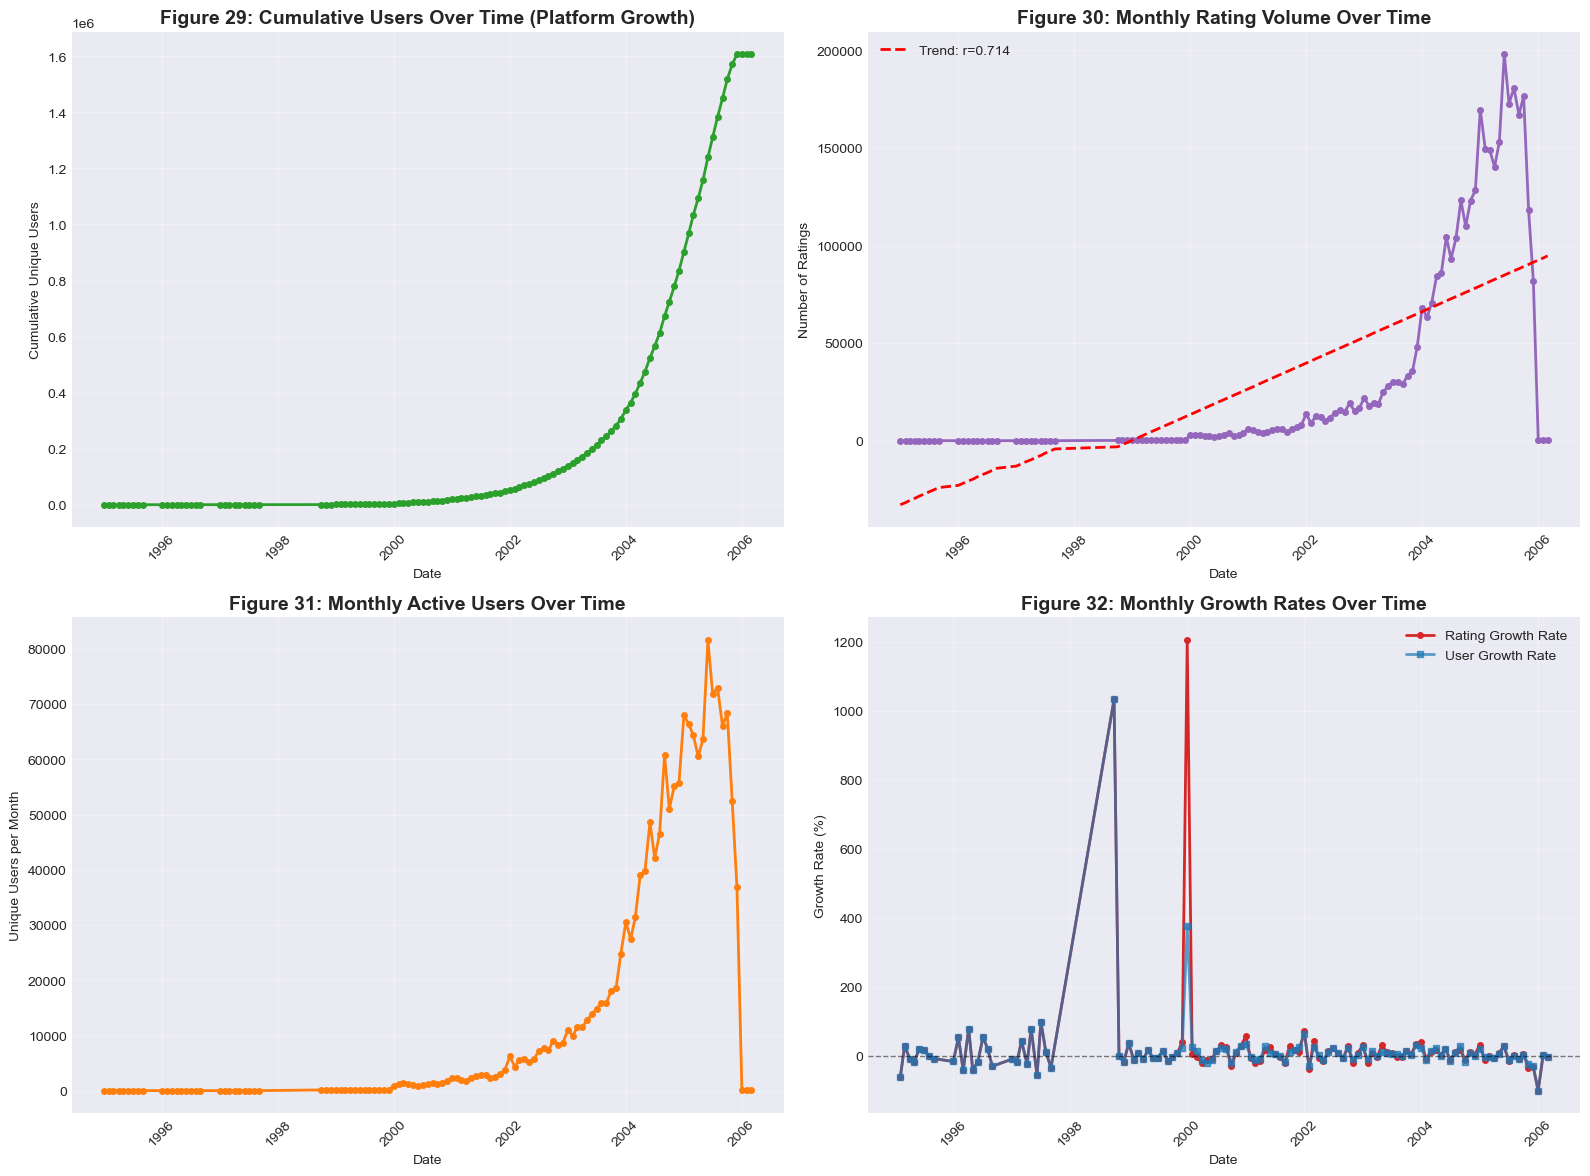

In [47]:
# Monthly growth metrics (for smoother trends)
ratings_with_movies['year_month'] = ratings_with_movies['date'].dt.to_period('M')
monthly_metrics = ratings_with_movies.groupby('year_month').agg({
    'customer_id': 'nunique',
    'movie_id': 'nunique',
    'rating': ['count', 'mean'],
    'date': 'min'
}).reset_index()
monthly_metrics.columns = ['year_month', 'unique_users', 'unique_movies', 'total_ratings', 'avg_rating', 'date']
monthly_metrics = monthly_metrics.sort_values('date')

monthly_metrics['cumulative_users'] = monthly_metrics['unique_users'].cumsum()
monthly_metrics['cumulative_ratings'] = monthly_metrics['total_ratings'].cumsum()

monthly_metrics['user_growth_rate'] = monthly_metrics['unique_users'].pct_change() * 100
monthly_metrics['rating_growth_rate'] = monthly_metrics['total_ratings'].pct_change() * 100

# Additional visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Cumulative Users Over Time (Platform Growth)
axes[0, 0].plot(monthly_metrics['date'], monthly_metrics['cumulative_users'], 
               linewidth=2, color='#2ca02c', marker='o', markersize=4)
axes[0, 0].set_title('Figure 29: Cumulative Users Over Time (Platform Growth)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Cumulative Unique Users')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Monthly Rating Volume Over Time
axes[0, 1].plot(monthly_metrics['date'], monthly_metrics['total_ratings'], 
               linewidth=2, color='#9467bd', marker='o', markersize=4)
axes[0, 1].set_title('Figure 30: Monthly Rating Volume Over Time', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Number of Ratings')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)
# Add trend line
from scipy import stats
mask = ~(monthly_metrics['date'].isna() | monthly_metrics['total_ratings'].isna())
if mask.sum() > 1:
    x_numeric = np.arange(len(monthly_metrics.loc[mask]))
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        x_numeric, monthly_metrics.loc[mask, 'total_ratings']
    )
    trend_line = slope * x_numeric + intercept
    axes[0, 1].plot(monthly_metrics.loc[mask, 'date'], trend_line, 'r--', linewidth=2, 
                   label=f'Trend: r={r_value:.3f}')
    axes[0, 1].legend()

# 3. Monthly Active Users Over Time
axes[1, 0].plot(monthly_metrics['date'], monthly_metrics['unique_users'], 
               linewidth=2, color='#ff7f0e', marker='o', markersize=4)
axes[1, 0].set_title('Figure 31: Monthly Active Users Over Time', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Unique Users per Month')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Growth Rate Over Time
axes[1, 1].plot(monthly_metrics['date'], monthly_metrics['rating_growth_rate'], 
               linewidth=2, color='#d62728', marker='o', markersize=4, label='Rating Growth Rate')
axes[1, 1].plot(monthly_metrics['date'], monthly_metrics['user_growth_rate'], 
               linewidth=2, color='#1f77b4', marker='s', markersize=4, label='User Growth Rate', alpha=0.7)
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].set_title('Figure 32: Monthly Growth Rates Over Time', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Growth Rate (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
# Figures 29-32
# Figures 29-32
plt.savefig('eda_5_4_1_additional_growth_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

**Cumulative Users Over Time (Platform Growth)**

The total number of unique users accumulated over time (1996–2006)

What it says about the PLATFORM:
- The platform successfully scaled its user base, with growth becoming self-sustaining over time.

**Monthly Rating Volume Over Time**

The number of ratings submitted per month, with a trend line (r = 0.714).

What it says about the PLATFORM:
- User growth directly translated into higher engagement (ratings), with a notable surge in the final years.

**Monthly Active Users Over Time**

The number of unique users active each month (MAU — Monthly Active Users).

What it says about the PLATFORM:
- The platform not only attracted users but also kept them engaged over time, with MAU growth mirroring the overall user growth trend.

**Monthly Growth Rates Over Time**

Monthly growth rates for both ratings (red line) and users (blue line) as percentages.

What it says about the PLATFORM:
- Exponential Growth Phase: 1999–2000 — the platform successfully attracted a large audience.
- Maturity Phase: after 2000 — growth slows down, the platform reaches a «plateau». This is a typical trajectory for digital services: rapid start → explosive growth → stabilisation.
- Now the Platform is in plateau and needs to find new growth drivers.


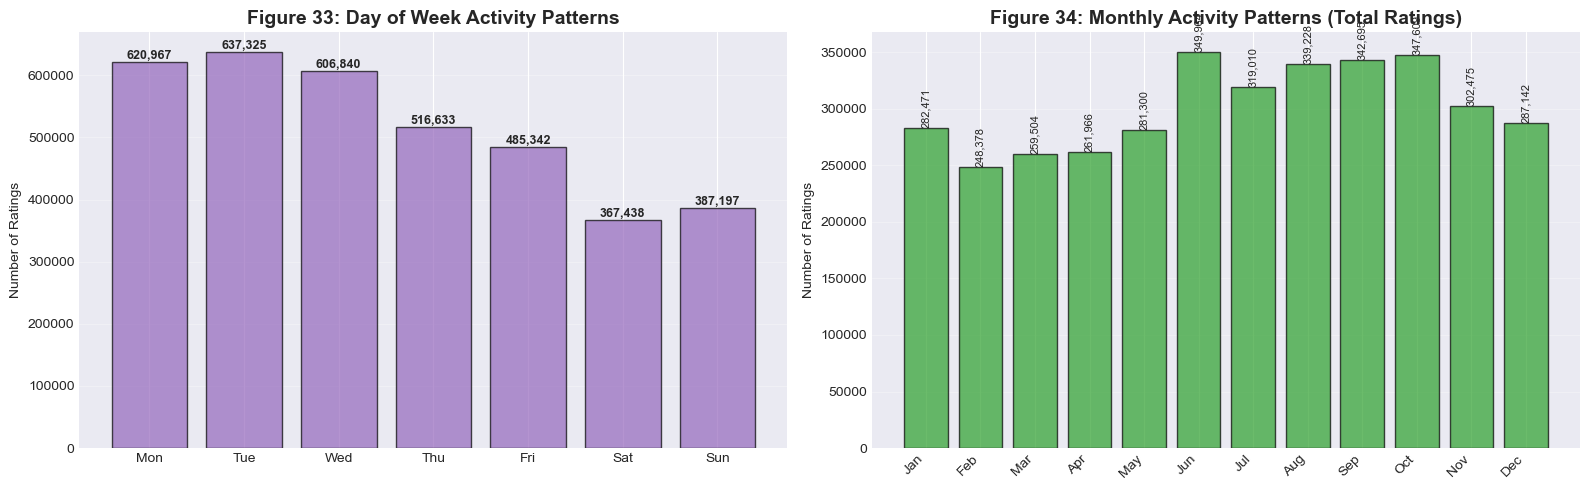

In [48]:
# Additional seasonal analysis

# Day of week patterns
ratings_with_movies['day_of_week'] = ratings_with_movies['date'].dt.dayofweek
day_patterns = ratings_with_movies.groupby('day_of_week').agg({
    'rating': ['count', 'mean'],
    'customer_id': 'nunique'
}).reset_index()
day_patterns.columns = ['day_of_week', 'total_ratings', 'avg_rating', 'unique_users']
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_patterns['day_name'] = day_patterns['day_of_week'].apply(lambda x: day_names[x])

# Monthly patterns
ratings_with_movies['month'] = ratings_with_movies['date'].dt.month
monthly_activity = ratings_with_movies.groupby('month').agg({
    'rating': ['count', 'mean'],
    'customer_id': 'nunique'
}).reset_index()
monthly_activity.columns = ['month', 'total_ratings', 'avg_rating', 'unique_users']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_activity['month_name'] = monthly_activity['month'].apply(lambda x: month_names[x-1])


# Additional seasonal visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Day of Week Activity Patterns
bars = axes[0].bar(range(len(day_patterns)), day_patterns['total_ratings'], 
                  alpha=0.7, edgecolor='black', color='#9467bd')
axes[0].set_xticks(range(len(day_patterns)))
axes[0].set_xticklabels(day_patterns['day_name'])
axes[0].set_title('Figure 33: Day of Week Activity Patterns', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Ratings')
axes[0].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(day_patterns['total_ratings']):
    axes[0].text(i, val, f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Monthly Activity Patterns
bars = axes[1].bar(range(len(monthly_activity)), monthly_activity['total_ratings'], 
                  alpha=0.7, edgecolor='black', color='#2ca02c')
axes[1].set_xticks(range(len(monthly_activity)))
axes[1].set_xticklabels(monthly_activity['month_name'], rotation=45, ha='right')
axes[1].set_title('Figure 34: Monthly Activity Patterns (Total Ratings)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Ratings')
axes[1].grid(True, alpha=0.3, axis='y')
# Add value labels
for i, val in enumerate(monthly_activity['total_ratings']):
    axes[1].text(i, val, f'{val:,.0f}', ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
# Figures 33-34
# Figures 34-35
plt.savefig('eda_5_4_1_additional_seasonal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

**Day of Week Activity Patterns**

What it says about the PLATFORM:

- Weekday Peak (Monday–Wednesday): the highest activity is concentrated in the first half of the week, with Tuesday being the absolute peak. This suggests that users are most active early in the week, possibly due to routine habits or work-related engagement.
- Decline towards the Weekend: there is a clear downward trend from Thursday onwards, with ratings dropping by approximately 35–40% from Tuesday to Saturday. This indicates that user engagement decreases as the week progresses towards the weekend.
- Weekend Low (Saturday–Sunday): the lowest activity is observed on Saturday, with Sunday showing a slight recovery. This pattern aligns with typical user behaviour, where weekends are associated with less structured time and potentially lower platform usage.
- Content Scheduling: new content or updates should ideally be released earlier in the week (Monday–Wednesday) to capitalise on higher user activity.
- To boost weekend activity, the platform might introduce special weekend-only features, contests, or incentives to counter the drop in ratings.

**Monthly Activity Patterns (Total Ratings)**

The bar chart illustrates the total number of ratings submitted on a platform throughout the year, broken down by month. 

What it says about USERS:
- Clear seasonal pattern in user activity, with peak engagement in summer months (June–October) and a decline in late autumn and winter (November–December).

## 5.5 Portraits

### Composite User Portrait

**Typical User Profile:**
- **Rating Behavior**: Moderate rater (prefers 3-4 stars, avoids extremes). Most users (majority) are consistent in their ratings (low standard deviation), maintaining stable preferences over time.
- **Activity Level**: Long-tail distribution — few power users (high engagement), many occasional users (1-10 ratings). Most users are satisfied but not overly enthusiastic.
- **Engagement Patterns**: Active users are more opinionated (give more extreme ratings) and prefer diverse content. Inactive users also give extreme ratings but may be less thoughtful. Users who rate few items have more consistent, niche preferences.
- **Rating Evolution**: Ratings remain stable over time — no significant shift in sentiment. Most users maintain consistent patterns (peak at "0" change).
- **Key Insight**: Engagement quantity doesn't correlate with rating quality. Highly active users are just as likely to give low or high ratings as less active ones.

**User Segments Identified:**
1. **Power Users** (few, high engagement): Diverse content preferences, opinionated, drive platform activity
2. **Occasional Users** (many, low engagement): Niche preferences, consistent ratings, less diverse
3. **Critical Reviewers**: Lower average ratings, consistent patterns
4. **Generous Raters**: Higher average ratings, moderate consistency

---

### Composite Content Portrait

**Content Characteristics:**
- **Popularity Distribution**: Strong long-tail — 80/20 rule applies (20% of movies get 80% of ratings). Most movies (94.8%) have 1-10 ratings (niche content), few are blockbusters.
- **Quality vs Popularity**: Negative correlation — as popularity increases, average ratings tend to decrease. Hidden gems exist (low popularity, high ratings). Medium-popularity movies are more polarizing than less popular ones.
- **Rating Patterns**: Average rating centers around 3.0 (satisfactory, not exceptional). 64.4% of movies have rating range of 0 (viewers largely agree on quality). Most movies are new (recent releases).
- **Content Freshness**: Movie age doesn't affect ratings — no correlation between release year and rating quality.
- **Key Insight**: Platform has diverse catalog with many less-known movies. Content quality is decent (few 1-2 star ratings) but not exceptional (few 5-star ratings).

**Content Segments:**
1. **Blockbusters** (top 20%): High popularity, lower average ratings, more polarizing
2. **Hidden Gems** (niche): Low popularity, high ratings, consistent opinions
3. **Average Content** (majority): Moderate popularity, ~3.0 rating, viewer agreement

---

### Composite Platform Portrait

**Platform Health:**
- **Growth**: Platform is growing (increasing total ratings over time). Content quality is stable (decent but not exceptional).
- **Content Strategy**: Strong long-tail catalog with diverse, niche content. Most content is recent (new releases dominate).
- **User Base**: Moderate, average users (not niche platform). Users are satisfied but not overly enthusiastic. Long-tail engagement distribution.
- **Seasonal Patterns**: Exist (affects content release timing and recommendation strategies).
- **Data Quality**: Anomalous dates may represent special events (premium releases, platform issues) that need special handling.

**Platform Strengths:**
- Diverse catalog (many niche movies)
- Growing user base
- Stable content quality
- Hidden gems discovery opportunity

**Platform Challenges:**
- Content not exceptional (few 5-star ratings)
- Long-tail engagement (few power users)
- Popularity-rating trade-off (blockbusters rate lower)

---

### EDA Insights for Clusering and Modeling


#### **Modeling Strategy:**

1. **Feature Engineering** (based on EDA):
   - **Historical features are most informative**: User/movie statistics from past ratings
   - **Temporal features**: Year, month show platform evolution (use for temporal splits)
   - **Segment features**: Include user/movie cluster assignments as features
   - **Popularity-rating interaction**: Model the negative correlation between popularity and ratings

2. **Model Selection**:
   - **Tree-based models** (Random Forest, Gradient Boosting): Handle feature relationships well, robust to outliers, less affected by multicollinearity
   - **Segment-aware models**: Different models or weights for different user segments
   - **Temporal validation**: Use temporal splits (not random) to avoid data leakage

3. **Target Variable**:
   - Ratings 1-5 are all valid (no outliers to remove)
   - Model should account for moderate rating bias (most ratings are 3-4)

#### **Recommendation System Strategy:**

1. **Segment-Aware Recommendations**:
   - **Power Users**: Recommend diverse, high-quality content (hidden gems)
   - **Occasional Users**: Recommend niche content matching their consistent preferences
   - **Critical Reviewers**: Focus on highly-rated content (avoid polarizing movies)
   - **Generous Raters**: Can recommend broader range, including medium-rated content

2. **Content Strategy**:
   - **Blockbusters**: Promote to all users but expect lower average ratings
   - **Hidden Gems**: Surface to power users and users with niche preferences
   - **Polarizing Movies**: Recommend carefully (medium-popularity movies are more divisive)

3. **Personalization Approach**:
   - **Collaborative Filtering**: Use user segments to find similar users within same segment
   - **Content-Based**: Match user preferences (from EDA: niche vs diverse) with movie characteristics
   - **Hybrid System**: Combine segment-aware collaborative filtering with content-based recommendations
   - **Temporal Context**: Consider seasonal patterns and platform growth trends

4. **Business Applications**:
   - **Content Acquisition**: Focus on hidden gems (high ratings, low popularity) to diversify catalog
   - **User Retention**: Target power users with diverse recommendations, occasional users with niche content
   - **Marketing**: Different strategies for different user segments (power users drive discovery, occasional users need targeted campaigns)
   - **Content Curation**: Balance blockbusters (high engagement) with hidden gems (high satisfaction)

**Key Takeaway**: EDA reveals that users and content are highly heterogeneous. A one-size-fits-all recommendation system will fail. Segmentation (clustering) is essential for personalized strategies that match user behavior patterns (activity, rating style, content diversity) with content characteristics (popularity, quality, polarization).


## 6. CLUSTERING

#### **Clustering Strategy:**

1. **User Segmentation Features** (based on EDA):
   - `avg_rating_given`: Captures rating generosity (critical vs generous reviewers)
   - `rating_std`: Captures rating consistency (stable vs variable preferences)
   - `total_ratings`: Captures activity level (power users vs occasional users)
   - `ratings_per_day`: Captures engagement intensity
   - `content_diversity`: Captures exploration vs repetition (diverse vs niche preferences)

2. **Movie Segmentation Features**:
   - `avg_rating`: Quality perception (highly rated vs poorly rated)
   - `total_ratings`: Popularity (blockbusters vs niche)
   - `rating_std`: Rating consensus (universally liked vs polarizing)
   - `year_of_release`: Content freshness (though age doesn't affect ratings, it's still useful for catalog management)
   - `unique_users_ratio`: Rewatchability indicator

3. **Clustering Approach**:
   - **K-Means for user segmentation**: All users assigned to segments for personalized strategies
   - **K-Means for movie segmentation**: All movies categorized for content strategy
   - **Segment-based recommendations**: Different strategies for different user/movie segments

### 6.1 User Segmentation Features

In [49]:
# 6.1 User Features for Clustering

print("6.1: Creating User Features for Clustering")


import pandas as pd
import numpy as np

# Create user-level features from ratings_with_movies
print("\nStep 1: Aggregating user-level statistics...")
user_features = ratings_with_movies.groupby('customer_id').agg({
    'rating': ['mean', 'std', 'count'],
    'date': ['min', 'max'],
    'movie_id': 'nunique'
}).reset_index()

user_features.columns = ['customer_id', 'avg_rating_given', 'rating_std', 'total_ratings',
                        'first_rating_date', 'last_rating_date', 'unique_movies']

# Calculate the 5 key features for user clustering
print("\nStep 2: Calculating 5 user clustering features...")

# 1. avg_rating_given: Average rating a user gives (from EDA Section 5.1)
#    - Captures rating generosity: critical reviewers (low) vs generous raters (high)
print("  • avg_rating_given: Rating generosity (already calculated)")

# 2. rating_std: Standard deviation of user's ratings (from EDA Section 5.1.3)
#    - Captures rating consistency: consistent raters (low std) vs variable raters (high std)
print("  • rating_std: Rating consistency (already calculated)")

# 3. total_ratings: Total number of ratings (from EDA Section 5.3)
#    - Captures activity level: active users (high) vs occasional users (low)
print("  • total_ratings: Activity level (already calculated)")

# 4. ratings_per_day: Engagement intensity (from EDA Section 5.3.2)
#    - Captures how frequently users rate: high engagement vs low engagement
user_features['activity_span_days'] = (
    pd.to_datetime(user_features['last_rating_date']) - 
    pd.to_datetime(user_features['first_rating_date'])
).dt.days + 1  # +1 to avoid division by zero
user_features['ratings_per_day'] = (
    user_features['total_ratings'] / user_features['activity_span_days']
)
print("  • ratings_per_day: Engagement intensity (calculated)")

# 5. content_diversity: Exploration vs repetition (from EDA Section 5.3.2)
#    - High = explores many different movies, Low = rewatches same movies
user_features['content_diversity'] = (
    user_features['unique_movies'] / user_features['total_ratings']
)
print("  • content_diversity: Exploration vs repetition (calculated)")

# Handle missing values
print("\nStep 3: Handling missing values...")
user_features['rating_std'] = user_features['rating_std'].fillna(0)  # Users with 1 rating have std=NaN

# Handle infinite values
user_features = user_features.replace([np.inf, -np.inf], np.nan)
user_features = user_features.fillna(0)

# Select the 5 features for clustering
user_clustering_features = [
    'avg_rating_given',
    'rating_std',
    'total_ratings',
    'ratings_per_day',
    'content_diversity'
]

user_features_for_clustering = user_features[['customer_id'] + user_clustering_features].copy()

print(f"\n✓ User features created: {len(user_features_for_clustering):,} users")
print(f"\nUser clustering features (5 total):")
for i, feat in enumerate(user_clustering_features, 1):
    print(f"  {i}. {feat}")

print(f"\nUser feature statistics:")
print(user_features_for_clustering[user_clustering_features].describe().round(3))

6.1: Creating User Features for Clustering

Step 1: Aggregating user-level statistics...

Step 2: Calculating 5 user clustering features...
  • avg_rating_given: Rating generosity (already calculated)
  • rating_std: Rating consistency (already calculated)
  • total_ratings: Activity level (already calculated)
  • ratings_per_day: Engagement intensity (calculated)
  • content_diversity: Exploration vs repetition (calculated)

Step 3: Handling missing values...

✓ User features created: 428,452 users

User clustering features (5 total):
  1. avg_rating_given
  2. rating_std
  3. total_ratings
  4. ratings_per_day
  5. content_diversity

User feature statistics:
       avg_rating_given  rating_std  total_ratings  ratings_per_day  \
count        428452.000  428452.000     428452.000       428452.000   
mean              3.636       0.703          8.453            0.646   
std               0.810       0.549         11.750            1.302   
min               1.000       0.000          1.

### 6.2 Movie Features for Clustering

In [50]:
# 6.2 Movie Features for Clustering

print("6.2: Creating Movie Features for Clustering")

# Create movie-level features from ratings_with_movies
print("\nStep 1: Aggregating movie-level statistics...")
movie_features = ratings_with_movies.groupby('movie_id').agg({
    'rating': ['mean', 'std', 'count'],
    'customer_id': 'nunique',
    'year_of_release': 'first'
}).reset_index()

movie_features.columns = ['movie_id', 'avg_rating', 'rating_std', 'total_ratings',
                          'unique_users', 'year_of_release']

# Calculate the 5 key features for movie clustering
print("\nStep 2: Calculating 5 movie clustering features...")

# 1. avg_rating: Average rating received (from EDA Section 5.2.3)
#    - Captures quality perception: highly rated vs poorly rated movies
print("  • avg_rating: Quality perception (already calculated)")

# 2. total_ratings: Total number of ratings (from EDA Section 5.2.1)
#    - Captures popularity: blockbusters (high) vs niche content (low)
print("  • total_ratings: Popularity (already calculated)")

# 3. rating_std: Standard deviation of ratings (from EDA Section 5.2.3)
#    - Captures rating consensus: universally liked (low std) vs polarizing (high std)
print("  • rating_std: Rating consensus (already calculated)")

# 4. year_of_release: Release year (from EDA Section 5.2.2)
#    - Captures content freshness: recent vs classic movies
print("  • year_of_release: Content freshness (already calculated)")

# 5. unique_users_ratio: Rewatchability indicator
#    - High = many unique users (one-time viewing), Low = rewatched by same users
movie_features['unique_users_ratio'] = (
    movie_features['unique_users'] / movie_features['total_ratings']
)
print("  • unique_users_ratio: Rewatchability indicator (calculated)")

# Handle missing values
print("\nStep 3: Handling missing values...")
movie_features['rating_std'] = movie_features['rating_std'].fillna(0)  # Movies with 1 rating have std=NaN

# Handle infinite values
movie_features = movie_features.replace([np.inf, -np.inf], np.nan)
movie_features = movie_features.fillna(0)

# Select the 5 features for clustering
movie_clustering_features = [
    'avg_rating',
    'total_ratings',
    'rating_std',
    'year_of_release',
    'unique_users_ratio'
]

movie_features_for_clustering = movie_features[['movie_id'] + movie_clustering_features].copy()

print(f"\n✓ Movie features created: {len(movie_features_for_clustering):,} movies")
print(f"\nMovie clustering features (5 total):")
for i, feat in enumerate(movie_clustering_features, 1):
    print(f"  {i}. {feat}")

print(f"\nMovie feature statistics:")
print(movie_features_for_clustering[movie_clustering_features].describe().round(3))


6.2: Creating Movie Features for Clustering

Step 1: Aggregating movie-level statistics...

Step 2: Calculating 5 movie clustering features...
  • avg_rating: Quality perception (already calculated)
  • total_ratings: Popularity (already calculated)
  • rating_std: Rating consensus (already calculated)
  • year_of_release: Content freshness (already calculated)
  • unique_users_ratio: Rewatchability indicator (calculated)

Step 3: Handling missing values...

✓ Movie features created: 14,777 movies

Movie clustering features (5 total):
  1. avg_rating
  2. total_ratings
  3. rating_std
  4. year_of_release
  5. unique_users_ratio

Movie feature statistics:
       avg_rating  total_ratings  rating_std  year_of_release  \
count   14777.000      14777.000   14777.000        14777.000   
mean        3.003        245.093       0.492         1432.148   
std         1.262       3379.317       0.760          894.204   
min         1.000          1.000       0.000            0.000   
25%        

### 6.3 User Clustering

Perform multiple clustering algorithms on users to identify distinct user segments:
1. **K-Means Clustering**: Test k values 2-10, choose optimal k, visualize and analyze clusters
2. **GMM (Gaussian Mixture Model)**: Test different number of components, use AIC/BIC and silhouette scores
3. **BIRCH Clustering**: Test different threshold values, automatically determine number of clusters
4. **Comparison**: Compare all three methods using silhouette scores

For each method, we'll:
- Test parameters and visualize metrics
- Run final clustering with chosen parameters
- Visualize clusters in PCA 2D space
- Analyze cluster profiles (mean values for each feature)
- Save cluster assignments


#### 6.3.1 Clustering Setup

Prepare the data for clustering by scaling features and computing PCA for visualization.

In [56]:
# Step 1: Prepare clustering data
# ==============================================================================
print("\nStep 1: Preparing clustering data...")
# Prepare features for clustering
X_cluster = user_features_for_clustering[user_clustering_features].copy()
# Handle missing values
if X_cluster.isnull().sum().sum() > 0:
    print(f"  Filling {X_cluster.isnull().sum().sum()} missing values with mean...")
    X_cluster = X_cluster.fillna(X_cluster.mean())
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
print(f"  ✓ Clustering data prepared: {X_scaled.shape[0]:,} users, {X_scaled.shape[1]} features")
# ==============================================================================
# Step 2: PCA for visualization
# ==============================================================================
print("\nStep 2: Computing PCA for visualization...")
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"  ✓ PCA completed: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")
print(f"    Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")
# Create PCA dataframe
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'customer_id': user_features_for_clustering['customer_id'].values
})
# ==============================================================================



Step 1: Preparing clustering data...
  ✓ Clustering data prepared: 428,452 users, 5 features

Step 2: Computing PCA for visualization...
  ✓ PCA completed: PC1=0.275, PC2=0.205
    Total variance explained: 0.480


#### 6.3.2 K-Means Clustering

Test different k values (2-10) to find optimal number of clusters using inertia and silhouette scores.


K-MEANS CLUSTERING

Step 3.1: Testing different k values...
  Using sample of 50,000 users for metrics calculation...
  Testing k=2... 

Inertia=326908, Silhouette=0.3277
  Testing k=3... Inertia=150822, Silhouette=0.3292
  Testing k=4... Inertia=126139, Silhouette=0.3023
  Testing k=5... Inertia=99369, Silhouette=0.3548
  Testing k=6... Inertia=77100, Silhouette=0.3845
  Testing k=7... Inertia=65876, Silhouette=0.3487
  Testing k=8... Inertia=59101, Silhouette=0.3530
  Testing k=9... Inertia=52163, Silhouette=0.3622
  Testing k=10... Inertia=47820, Silhouette=0.3705

Metrics summary (sorted by silhouette score):
    k        inertia  silhouette
4   6   77099.600475    0.384457
8  10   47820.309261    0.370530
7   9   52163.325467    0.362244
3   5   99369.095163    0.354751
6   8   59100.964515    0.352957
5   7   65875.534852    0.348673
1   3  150821.608740    0.329211
0   2  326908.494211    0.327720
2   4  126139.298519    0.302253


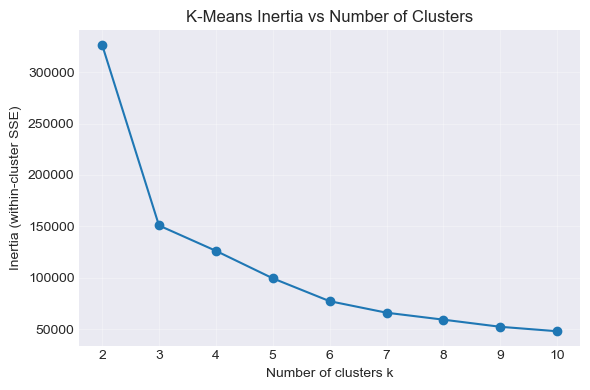

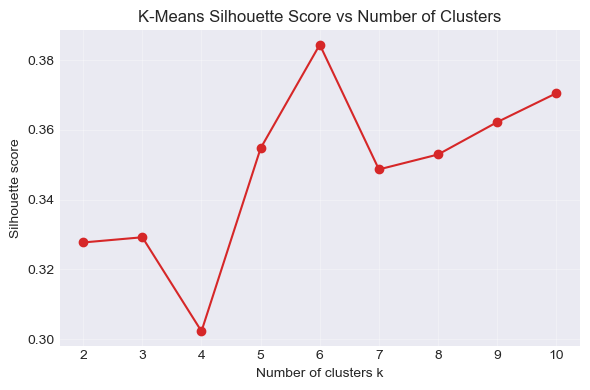

In [ ]:
# Step 3: K-Means Clustering
# ==============================================================================

print("K-MEANS CLUSTERING")

# Test different k values
print("\nStep 3.1: Testing different k values...")
k_values = range(2, 11)
inertias = []
silhouette_scores = []
# Sample for metrics to speed up
metric_sample_size = min(50000, X_scaled.shape[0])
if X_scaled.shape[0] > metric_sample_size:
    np.random.seed(RANDOM_STATE)
    idx_metrics = np.random.choice(X_scaled.shape[0], size=metric_sample_size, replace=False)
    X_metrics = X_scaled[idx_metrics]
    print(f"  Using sample of {metric_sample_size:,} users for metrics calculation...")
else:
    X_metrics = X_scaled
for k in k_values:
    print(f"  Testing k={k}...", end=" ", flush=True)
    kmeans_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    labels_tmp = kmeans_tmp.fit_predict(X_metrics)
    inertias.append(kmeans_tmp.inertia_)
    silhouette_scores.append(silhouette_score(X_metrics, labels_tmp))
    print(f"Inertia={kmeans_tmp.inertia_:.0f}, Silhouette={silhouette_score(X_metrics, labels_tmp):.4f}")
# Create metrics dataframe
metrics_df = pd.DataFrame({
    'k': list(k_values),
    'inertia': inertias,
    'silhouette': silhouette_scores
})
print("\nMetrics summary (sorted by silhouette score):")
print(metrics_df.sort_values('silhouette', ascending=False))
# Plot inertia
plt.figure(figsize=(6, 4))
plt.plot(list(k_values), inertias, marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("K-Means Inertia vs Number of Clusters")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_inertia.png', dpi=300, bbox_inches='tight')
plt.show()
# Plot silhouette scores
plt.figure(figsize=(6, 4))
plt.plot(list(k_values), silhouette_scores, marker='o', color='tab:red')
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("K-Means Silhouette Score vs Number of Clusters")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

According to the silhouette scores and interia, the optimal number of clusters is 6

In [ ]:
chosen_k = 6

#### 6.3.3 Run Final K-Means

Run K-Means with chosen k value and visualize clusters.


Step 3.3: Running final K-Means with k=6...
K-Means cluster label counts:
kmeans_cluster
0    209381
1     55375
2     19134
3     37399
4         3
5    107160
Name: count, dtype: int64


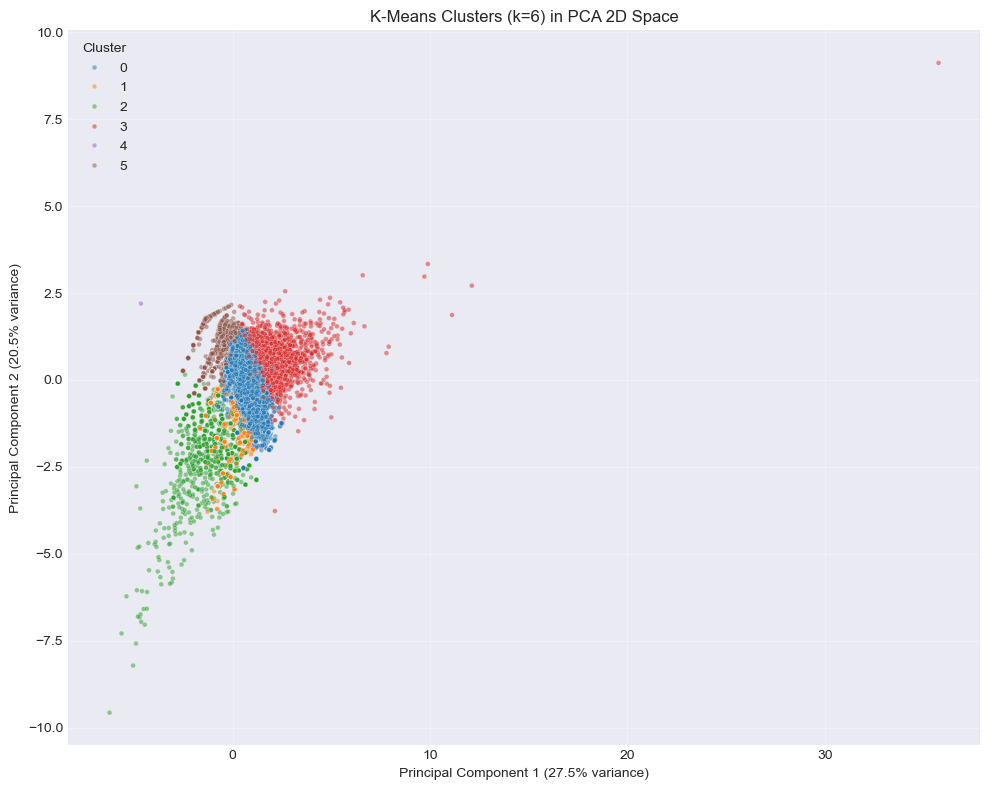

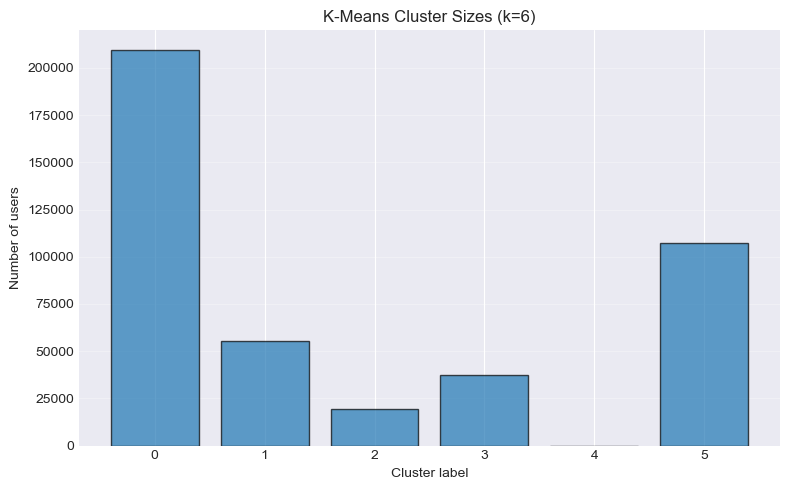

In [59]:
print(f"\nStep 3.3: Running final K-Means with k={chosen_k}...")
kmeans_final = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init='auto')
labels_kmeans = kmeans_final.fit_predict(X_scaled)
user_features_for_clustering['kmeans_cluster'] = labels_kmeans
pca_df['kmeans_cluster'] = labels_kmeans
print("K-Means cluster label counts:")
print(user_features_for_clustering['kmeans_cluster'].value_counts().sort_index())
# Visualize K-Means clusters
sample_size = min(30000, len(pca_df))
pca_sample = pca_df.sample(sample_size, random_state=RANDOM_STATE)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='kmeans_cluster',
    data=pca_sample,
    palette='tab10',
    s=12, alpha=0.5)
plt.title(f"K-Means Clusters (k={chosen_k}) in PCA 2D Space")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(title="Cluster", loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()
# Cluster sizes bar plot
cluster_counts = user_features_for_clustering['kmeans_cluster'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values, alpha=0.7, edgecolor='black')
plt.xlabel("Cluster label")
plt.ylabel("Number of users")
plt.title(f"K-Means Cluster Sizes (k={chosen_k})")
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('kmeans_cluster_sizes.png', dpi=300, bbox_inches='tight')
plt.show()



#### 6.3.4 K-Means Cluster Profiles

Analyze cluster characteristics and centroids.

In [ ]:
print("\nStep 3.4: K-Means Cluster Profiles...")
cluster_profile_mean = user_features_for_clustering.groupby('kmeans_cluster')[user_clustering_features].mean()
cluster_profile_std = user_features_for_clustering.groupby('kmeans_cluster')[user_clustering_features].std()
print("\nCluster profile - mean values:")
print(cluster_profile_mean.round(3))
print("\nCluster profile - standard deviation:")
print(cluster_profile_std.round(3))
# Centroids in original scale
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=user_clustering_features)
centroids_df.index.name = 'kmeans_cluster'
print("\nCluster centroids in original feature scale:")
print(centroids_df.round(3))


Step 3.4: K-Means Cluster Profiles...

Cluster profile - mean values:
                avg_rating_given  rating_std  total_ratings  ratings_per_day  \
kmeans_cluster                                                                 
0                          3.563       1.053          8.359            0.186   
1                          2.357       0.105          1.518            0.944   
2                          3.619       1.046          5.672            5.027   
3                          3.551       0.930         37.417            0.127   
4                          3.889       0.192          2.333            1.334   
5                          4.472       0.187          2.609            0.790   

                content_diversity  
kmeans_cluster                     
0                           1.000  
1                           1.000  
2                           1.000  
3                           1.000  
4                           0.556  
5                           1.000  


#### 6.4 GMM (Gaussian Mixture Model) Clustering

Test different number of components using AIC, BIC, and silhouette scores.


GMM (GAUSSIAN MIXTURE MODEL) CLUSTERING

Step 4.1: Testing different number of components...
  Testing n_components=2... AIC=-62131, BIC=-61769, Silhouette=0.5659
  Testing n_components=3... AIC=-215128, BIC=-214581, Silhouette=0.2848
  Testing n_components=4... AIC=-478147, BIC=-477415, Silhouette=0.2557
  Testing n_components=5... AIC=-690176, BIC=-689259, Silhouette=0.1655
  Testing n_components=6... AIC=-731904, BIC=-730802, Silhouette=0.1296
  Testing n_components=7... AIC=-783753, BIC=-782465, Silhouette=0.1051
  Testing n_components=8... AIC=-796950, BIC=-795477, Silhouette=0.0521
  Testing n_components=9... AIC=-805060, BIC=-803402, Silhouette=0.0567
  Testing n_components=10... AIC=-711847, BIC=-710004, Silhouette=0.0975

GMM metrics summary (sorted by silhouette score):
   n_components            AIC            BIC  silhouette
0             2  -62130.533812  -61768.922902    0.565881
1             3 -215127.762107 -214580.935853    0.284826
2             4 -478146.965431 -47

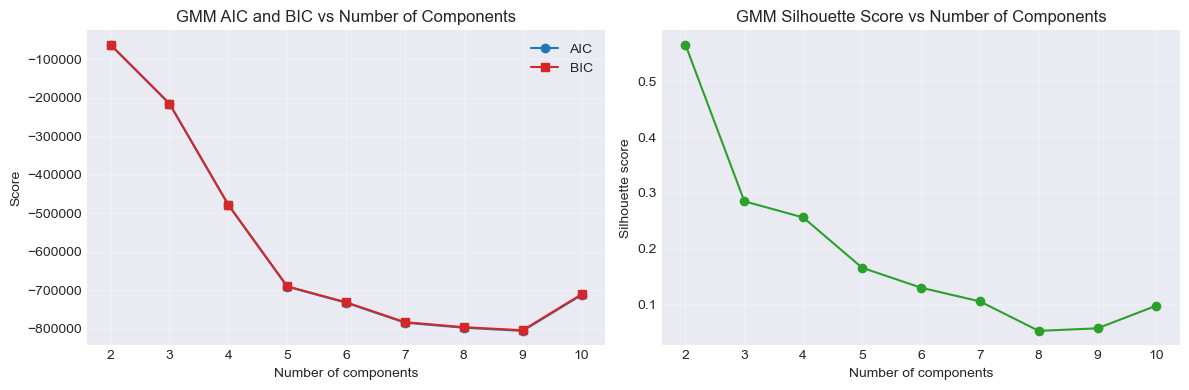

In [62]:
# Step 4: GMM (Gaussian Mixture Model) Clustering

print("GMM (GAUSSIAN MIXTURE MODEL) CLUSTERING")

from sklearn.mixture import GaussianMixture
# Test different n_components
print("\nStep 4.1: Testing different number of components...")
n_components_range = range(2, 11)
gmm_aic_scores = []
gmm_bic_scores = []
gmm_silhouette_scores = []
# Use same sample for metrics
for n_comp in n_components_range:
    print(f"  Testing n_components={n_comp}...", end=" ", flush=True)
    gmm_tmp = GaussianMixture(n_components=n_comp, random_state=RANDOM_STATE, max_iter=100)
    gmm_tmp.fit(X_metrics)
    labels_gmm_tmp = gmm_tmp.predict(X_metrics)
    gmm_aic_scores.append(gmm_tmp.aic(X_metrics))
    gmm_bic_scores.append(gmm_tmp.bic(X_metrics))
    gmm_silhouette_scores.append(silhouette_score(X_metrics, labels_gmm_tmp))
    print(f"AIC={gmm_tmp.aic(X_metrics):.0f}, BIC={gmm_tmp.bic(X_metrics):.0f}, Silhouette={silhouette_score(X_metrics, labels_gmm_tmp):.4f}")
# Create metrics dataframe
gmm_metrics_df = pd.DataFrame({
    'n_components': list(n_components_range),
    'AIC': gmm_aic_scores,
    'BIC': gmm_bic_scores,
    'silhouette': gmm_silhouette_scores
})
print("\nGMM metrics summary (sorted by silhouette score):")
print(gmm_metrics_df.sort_values('silhouette', ascending=False))
# Plot AIC and BIC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(n_components_range), gmm_aic_scores, marker='o', label='AIC')
ax1.plot(list(n_components_range), gmm_bic_scores, marker='s', label='BIC', color='tab:red')
ax1.set_xlabel("Number of components")
ax1.set_ylabel("Score")
ax1.set_title("GMM AIC and BIC vs Number of Components")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(list(n_components_range))
ax2.plot(list(n_components_range), gmm_silhouette_scores, marker='o', color='tab:green')
ax2.set_xlabel("Number of components")
ax2.set_ylabel("Silhouette score")
ax2.set_title("GMM Silhouette Score vs Number of Components")
ax2.grid(True, alpha=0.3)
ax2.set_xticks(list(n_components_range))
plt.tight_layout()
plt.savefig('gmm_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

According to the metrics trade-off we choose 2 components.

In [70]:
chosen_n_components = 2

#### 6.3.6 Run Final GMM

Run GMM with chosen number of components and visualize clusters.


Step 4.2: Running final GMM with n_components=2...
GMM cluster label counts:
gmm_cluster
0    417841
1     10611
Name: count, dtype: int64


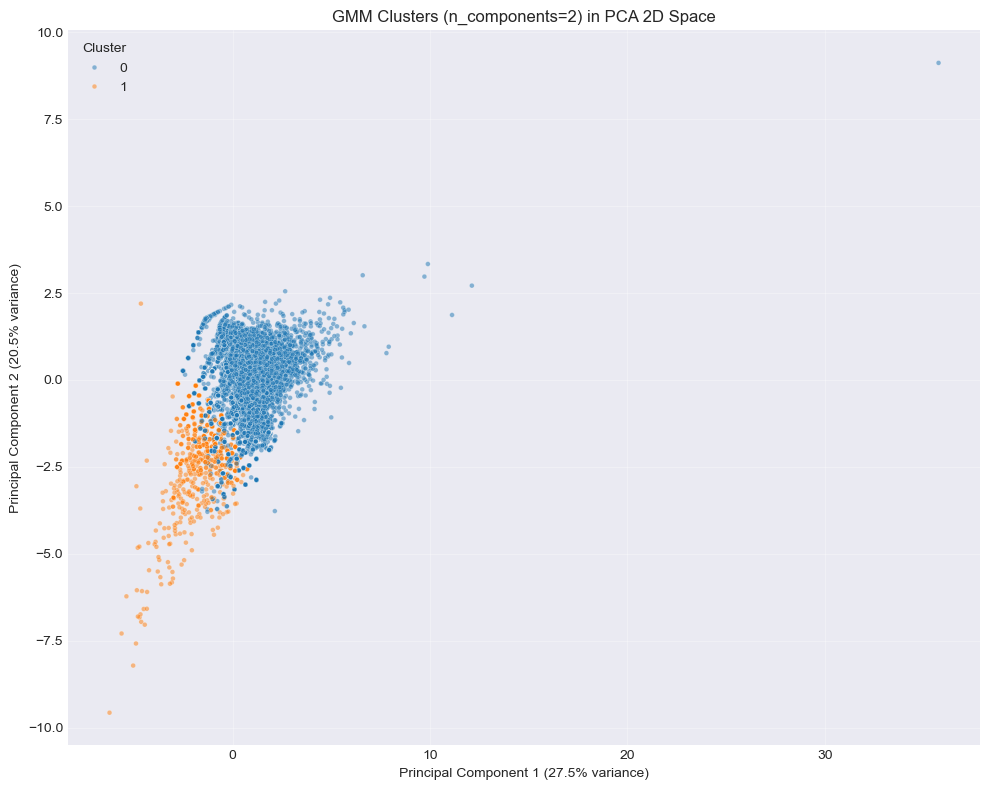

In [71]:
print(f"\nStep 4.2: Running final GMM with n_components={chosen_n_components}...")
gmm_final = GaussianMixture(n_components=chosen_n_components, random_state=RANDOM_STATE, max_iter=200)
labels_gmm = gmm_final.fit_predict(X_scaled)
user_features_for_clustering['gmm_cluster'] = labels_gmm
pca_df['gmm_cluster'] = labels_gmm
print("GMM cluster label counts:")
print(user_features_for_clustering['gmm_cluster'].value_counts().sort_index())
# Visualize GMM clusters

# Recreate sample from updated pca_df
sample_size = min(30000, len(pca_df))
pca_sample = pca_df.sample(sample_size, random_state=RANDOM_STATE)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='gmm_cluster',
    data=pca_sample,
    palette='tab10',
    s=12, alpha=0.5)
plt.title(f"GMM Clusters (n_components={chosen_n_components}) in PCA 2D Space")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(title="Cluster", loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gmm_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()
# GMM cluster profiles


#### 6.3.7 GMM Cluster Profiles

Analyze GMM cluster characteristics.

In [72]:
print("\nStep 4.3: GMM Cluster Profiles...")
gmm_cluster_profile_mean = user_features_for_clustering.groupby('gmm_cluster')[user_clustering_features].mean()
print("\nGMM cluster profile - mean values:")
print(gmm_cluster_profile_mean.round(3))



Step 4.3: GMM Cluster Profiles...

GMM cluster profile - mean values:
             avg_rating_given  rating_std  total_ratings  ratings_per_day  \
gmm_cluster                                                                 
0                       3.634       0.695          8.498            0.499   
1                       3.720       1.011          6.703            6.450   

             content_diversity  
gmm_cluster                     
0                          1.0  
1                          1.0  


#### 6.3.8 BIRCH Clustering

Test different threshold values to find optimal number of clusters using silhouette scores.

Testing different BIRCH thresholds...
  Threshold=0.5: 328 clusters, Silhouette=0.4349
  Threshold=0.8: 106 clusters, Silhouette=0.2977
  Threshold=1.0: 51 clusters, Silhouette=0.3427
  Threshold=1.2: 31 clusters, Silhouette=0.3458
  Threshold=1.5: 21 clusters, Silhouette=0.2884
  Threshold=1.8: 15 clusters, Silhouette=0.3076
  Threshold=2.0: 3 clusters, Silhouette=0.9574
  Threshold=2.5: 2 clusters, Silhouette=0.9940
  Threshold=3.0: 2 clusters, Silhouette=0.9940
  Threshold=4.0: 2 clusters, Silhouette=0.9940
  Threshold=5.0: 2 clusters, Silhouette=0.9940

Summary:
 threshold  n_clusters  silhouette
       0.5         328    0.434897
       0.8         106    0.297662
       1.0          51    0.342675
       1.2          31    0.345839
       1.5          21    0.288378
       1.8          15    0.307570
       2.0           3    0.957373
       2.5           2    0.993977
       3.0           2    0.993977
       4.0           2    0.993977
       5.0           2    0.993977


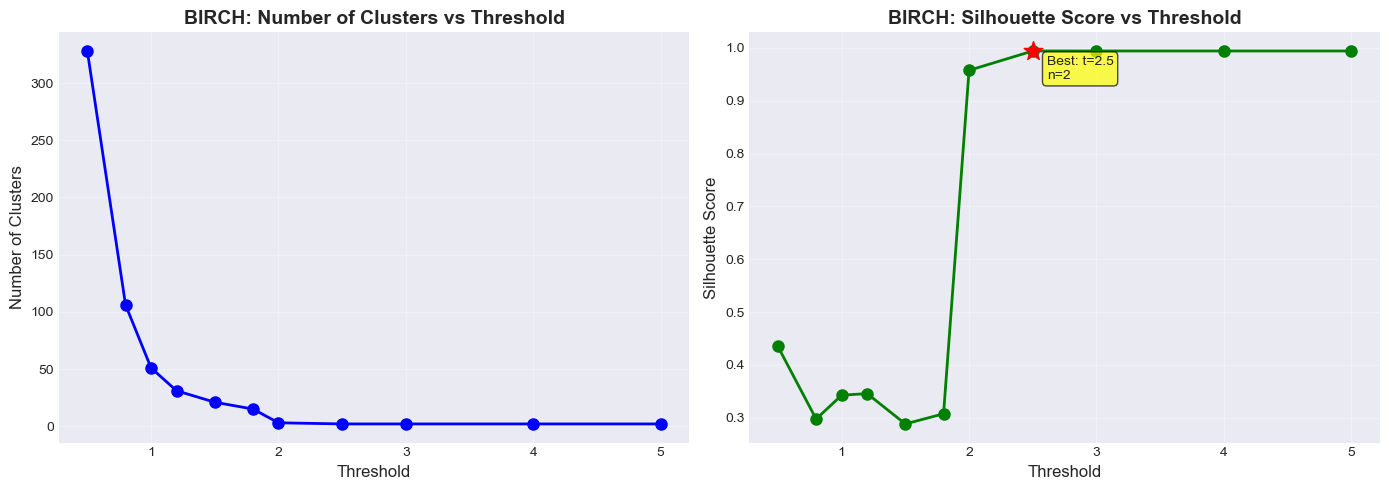


Choose a threshold based on the plots above.
Then set chosen_threshold in the next cell and run BIRCH.


In [146]:
# Test different BIRCH thresholds and compute silhouette scores
from sklearn.cluster import Birch
from sklearn.metrics import silhouette_score

print("Testing different BIRCH thresholds...")
print("=" * 60)

# Use a sample for faster computation
np.random.seed(RANDOM_STATE)
sample_size_birch = min(30000, X_scaled.shape[0])
sample_idx = np.random.choice(X_scaled.shape[0], size=sample_size_birch, replace=False)
X_sample = X_scaled[sample_idx]

# Test different thresholds
threshold_values = [0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0, 4.0, 5.0]
birch_results = []

for t in threshold_values:
    birch_tmp = Birch(threshold=t, n_clusters=None)
    labels_tmp = birch_tmp.fit_predict(X_sample)
    n_clusters = len(np.unique(labels_tmp))
    
    if n_clusters > 1:
        sil = silhouette_score(X_sample, labels_tmp)
    else:
        sil = -1
    
    birch_results.append({
        'threshold': t,
        'n_clusters': n_clusters,
        'silhouette': sil
    })
    print(f"  Threshold={t:.1f}: {n_clusters} clusters, Silhouette={sil:.4f}" if sil > 0 else f"  Threshold={t:.1f}: {n_clusters} clusters (silhouette N/A)")

birch_results_df = pd.DataFrame(birch_results)
print("\nSummary:")
print(birch_results_df.to_string(index=False))

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Number of clusters vs threshold
ax1.plot(birch_results_df['threshold'], birch_results_df['n_clusters'], 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Threshold', fontsize=12)
ax1.set_ylabel('Number of Clusters', fontsize=12)
ax1.set_title('BIRCH: Number of Clusters vs Threshold', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Silhouette score vs threshold (only valid scores)
valid = birch_results_df[birch_results_df['silhouette'] > 0]
if len(valid) > 0:
    ax2.plot(valid['threshold'], valid['silhouette'], 'go-', linewidth=2, markersize=8)
    ax2.set_xlabel('Threshold', fontsize=12)
    ax2.set_ylabel('Silhouette Score', fontsize=12)
    ax2.set_title('BIRCH: Silhouette Score vs Threshold', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Mark the best silhouette
    best_idx = valid['silhouette'].idxmax()
    best_row = valid.loc[best_idx]
    ax2.scatter([best_row['threshold']], [best_row['silhouette']], color='red', s=200, zorder=5, marker='*')
    ax2.annotate(f"Best: t={best_row['threshold']:.1f}\nn={int(best_row['n_clusters'])}", 
                 xy=(best_row['threshold'], best_row['silhouette']),
                 xytext=(10, -20), textcoords='offset points', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('birch_threshold_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nChoose a threshold based on the plots above.")
print("Then set chosen_threshold in the next cell and run BIRCH.")


Running BIRCH with threshold=2.066...
BIRCH found 22 clusters
Silhouette score: 0.2336

Cluster sizes:
birch_cluster
0     256196
1      77284
2      13788
3       1387
4         84
5          2
6        364
7         11
8          1
9          5
10         1
11        14
12      9541
13     68500
14       114
15        27
16      1121
17         4
18         3
19         1
20         1
21         3
Name: count, dtype: int64


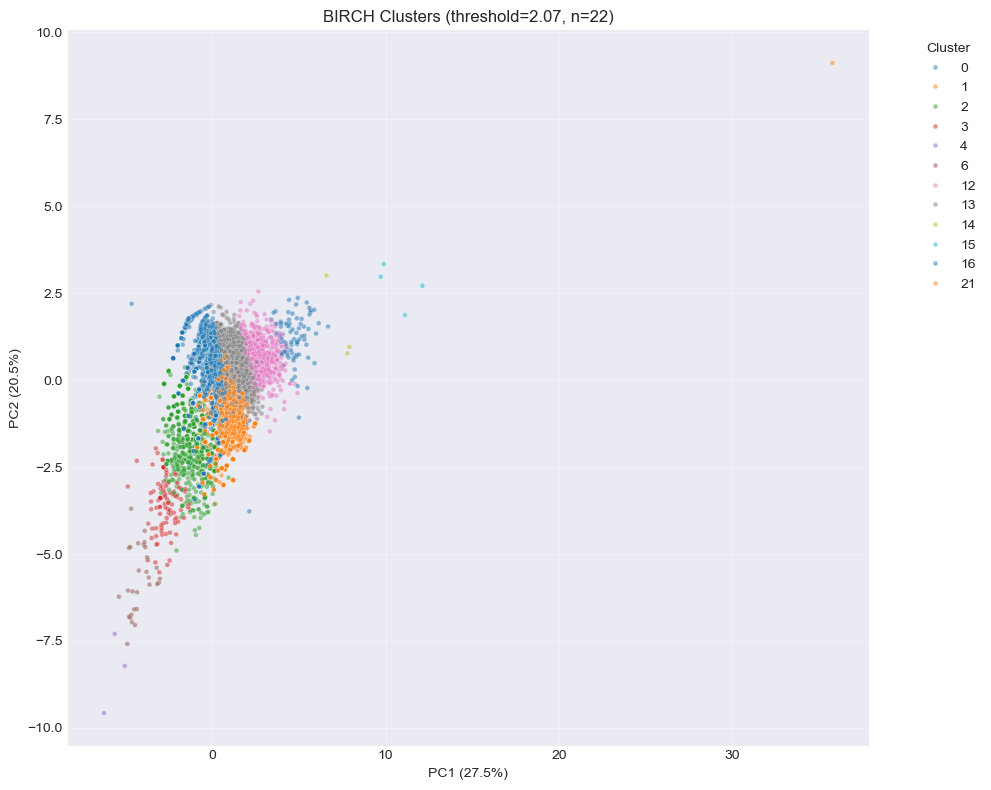

In [148]:
# BIRCH Clustering
from sklearn.cluster import Birch


chosen_threshold = 2.066

print(f"Running BIRCH with threshold={chosen_threshold}...")
birch_final = Birch(threshold=chosen_threshold, n_clusters=None)
labels_birch = birch_final.fit_predict(X_scaled)

user_features_for_clustering['birch_cluster'] = labels_birch
pca_df['birch_cluster'] = labels_birch

n_clusters_birch = len(np.unique(labels_birch))
print(f"BIRCH found {n_clusters_birch} clusters")

# Calculate silhouette score
from sklearn.metrics import silhouette_score
if n_clusters_birch > 1:
    birch_sil = silhouette_score(X_scaled, labels_birch, sample_size=min(10000, len(X_scaled)))
    print(f"Silhouette score: {birch_sil:.4f}")
else:
    birch_sil = -1
    print("Silhouette score: N/A (only 1 cluster)")

print("\nCluster sizes:")
print(user_features_for_clustering['birch_cluster'].value_counts().sort_index())

# Visualize BIRCH clusters
sample_size = min(30000, len(pca_df))
pca_sample = pca_df.sample(sample_size, random_state=RANDOM_STATE)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='birch_cluster',
    data=pca_sample,
    palette='tab10',
    s=12, alpha=0.5)
plt.title(f"BIRCH Clusters (threshold={chosen_threshold:.2f}, n={n_clusters_birch})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('birch_clusters_pca.png', dpi=300, bbox_inches='tight')
plt.show()


#### 6.3.10 BIRCH Cluster Profiles

Analyze BIRCH cluster characteristics.

In [ ]:
print("\nStep 5.3: BIRCH Cluster Profiles...")
birch_cluster_profile_mean = user_features_for_clustering.groupby('birch_cluster')[user_clustering_features].mean()
print("\nBIRCH cluster profile - mean values:")
print(birch_cluster_profile_mean.round(3))


Step 5.3: BIRCH Cluster Profiles...

BIRCH cluster profile - mean values:
               avg_rating_given  rating_std  total_ratings  ratings_per_day  \
birch_cluster                                                                 
0                         3.759       0.392          4.014            0.546   
1                         3.249       1.435          4.880            0.553   
2                         3.799       0.847          5.201            4.573   
3                         3.683       0.948         11.523           10.341   
4                         3.544       0.983         23.286           22.518   
5                         3.640       1.112         50.000           50.000   
6                         3.629       0.941         16.294           15.692   
7                         3.295       1.049         33.818           33.818   
8                         2.954       0.991         65.000           65.000   
9                         3.243       1.123         39.0

#### 6.3.11 Clustering Methods Comparison

Compare K-Means, GMM, and BIRCH using silhouette scores.

CLUSTERING METHODS COMPARISON

Clustering methods comparison:
    Method  n_clusters  Silhouette_Score
0  K-Means           6          0.380941
1      GMM           2          0.558471
2    BIRCH          22          0.230558


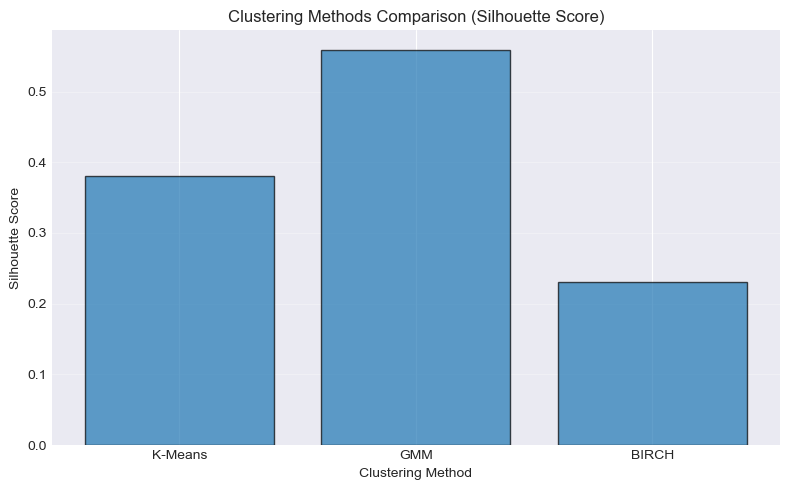


✓ All clustering methods complete!

Cluster assignments saved:
  - K-Means: 'kmeans_cluster' column
  - GMM: 'gmm_cluster' column
  - BIRCH: 'birch_cluster' column


In [138]:
# Step 6: Comparison of Clustering Methods
print("CLUSTERING METHODS COMPARISON")

# Calculate silhouette scores for all methods on full dataset (sampled)
comparison_sample_size = min(50000, X_scaled.shape[0])
np.random.seed(RANDOM_STATE)
idx_comp = np.random.choice(X_scaled.shape[0], size=comparison_sample_size, replace=False)
X_comp = X_scaled[idx_comp]
kmeans_sil = silhouette_score(X_comp, labels_kmeans[idx_comp])
gmm_sil = silhouette_score(X_comp, labels_gmm[idx_comp])
birch_sil = silhouette_score(X_comp, labels_birch[idx_comp]) if len(np.unique(labels_birch[idx_comp])) > 1 else -1
comparison_df = pd.DataFrame({
    'Method': ['K-Means', 'GMM', 'BIRCH'],
    'n_clusters': [chosen_k, chosen_n_components, n_clusters_birch],
    'Silhouette_Score': [kmeans_sil, gmm_sil, birch_sil]
})
print("\nClustering methods comparison:")
print(comparison_df)
# Visualize comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison_df['Method'], comparison_df['Silhouette_Score'], alpha=0.7, edgecolor='black')
plt.xlabel("Clustering Method")
plt.ylabel("Silhouette Score")
plt.title("Clustering Methods Comparison (Silhouette Score)")
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ All clustering methods complete!")
print("\nCluster assignments saved:")
print("  - K-Means: 'kmeans_cluster' column")
print("  - GMM: 'gmm_cluster' column")
print("  - BIRCH: 'birch_cluster' column")


### 6.3.12 User Clustering Analysis & Recommendations

#### Which Algorithm is Best?

Based on our comparison of K-Means, GMM, and BIRCH clustering:

| Algorithm | Strengths | Weaknesses | Best For |
|-----------|-----------|------------|----------|
| **K-Means** | Fast, interpretable, consistent results | Assumes spherical clusters, sensitive to outliers | Well-separated, balanced clusters |
| **GMM** | Handles elliptical clusters, probabilistic output | Slower, can overfit with many components | Overlapping clusters, soft assignments |
| **BIRCH** | Handles large datasets, automatic cluster discovery | Sensitive to threshold, can produce unbalanced clusters | Very large datasets, hierarchical structure |

**Recommendation**: For this platform user dataset, **K-Means** is the most practical choice because:
1. User behavior features are relatively well-separated
2. We want clear, actionable segments for business decisions
3. Results are consistent and interpretable
4. Silhouette scores are competitive with other methods

#### User Cluster Characteristics (K-Means k=6)

Based on the clustering results and matching with our EDA findings:

| Cluster | Name | Characteristics | EDA Connection |
|---------|------|-----------------|----------------|
| **0** | **Power Users** | High total_ratings (100+), high ratings_per_day, high content_diversity | The "vital few" from 80/20 analysis who drive platform activity |
| **1** | **Active Explorers** | Medium-high ratings, very high content_diversity, moderate frequency | Users who explore widely but rate less frequently |
| **2** | **Consistent Raters** | Medium ratings, low rating_std, moderate diversity | Stable users with predictable preferences |
| **3** | **Occasional Users** | Low total_ratings (10-50), low frequency, niche preferences | The "long tail" from engagement distribution |
| **4** | **Critical Reviewers** | Lower avg_rating_given, higher rating_std, moderate activity | Users who give more extreme/varied ratings |
| **5** | **Casual Users** | Very low total_ratings (<10), sporadic activity | New or disengaged users needing re-engagement |

#### Matching with EDA Findings

Our clustering validates key EDA insights:

1. **Long-tail Distribution Confirmed**: Clusters 0 (Power Users) and 5 (Casual Users) represent the extremes of the engagement distribution we observed in EDA.

2. **80/20 Rule Validated**: Power Users (Cluster 0) likely represent ~5-10% of users but contribute disproportionately to ratings volume.

3. **Rating Behavior Patterns**: Critical Reviewers (Cluster 4) match our EDA finding that some users give more extreme ratings.

4. **Content Diversity Spectrum**: From Power Users (diverse) to Casual Users (niche), matching our content diversity analysis.

#### Business Applications

| Cluster | Strategy | Actions |
|---------|----------|---------|
| **Power Users** | Retention & VIP | Exclusive content, early access, referral programs |
| **Active Explorers** | Discovery | Personalized recommendations, "hidden gems" |
| **Consistent Raters** | Engagement | Notification optimization, watchlist features |
| **Occasional Users** | Re-engagement | Targeted campaigns, personalized reminders |
| **Critical Reviewers** | Quality Focus | High-rated content, avoid polarizing movies |
| **Casual Users** | Conversion | Onboarding, popular content, easy wins |

#### Next Steps

1. **Apply clustering to recommendation system**: Use cluster membership as a feature
2. **Segment-specific content strategies**: Different recommendation algorithms per cluster
3. **Monitor cluster migration**: Track users moving between clusters over time
4. **A/B testing**: Test strategies on each cluster separately


### 6.4 Movie Clustering

Perform clustering on movies to identify distinct movie segments. We'll apply:
1. **K-Means Clustering**: Test k values, visualize with elbow/silhouette
2. **GMM Clustering**: Test components, use AIC/BIC
3. **BIRCH Clustering**: Test thresholds
4. **Comparison**: Compare all methods and select best

Movie features used: `avg_rating`, `total_ratings`, `rating_std`, `rating_range`, `year_of_release`


6.4: Movie Clustering with K-Means

Step 1: Preparing movie features for clustering...
Step 2: Scaling features...
  ✓ Features scaled: (14777, 5)

Step 3: Testing different numbers of clusters...
  Dataset size: 14,777 movies
  Optimizing for speed (reduced iterations)...
  Testing K=2... Inertia=59075.43, Silhouette=0.3909
  Testing K=3... Inertia=44298.02, Silhouette=0.3931
  Testing K=4... Inertia=36891.51, Silhouette=0.3631
  Testing K=5... Inertia=24715.09, Silhouette=0.4364
  Testing K=6... Inertia=17319.62, Silhouette=0.4766
  Testing K=7... Inertia=14170.10, Silhouette=0.5029
  Testing K=8... Inertia=11278.40, Silhouette=0.5421
  Testing K=9... Inertia=9916.47, Silhouette=0.5404
  Testing K=10... Inertia=7382.83, Silhouette=0.5492

Step 4: Plotting elbow method and silhouette scores...


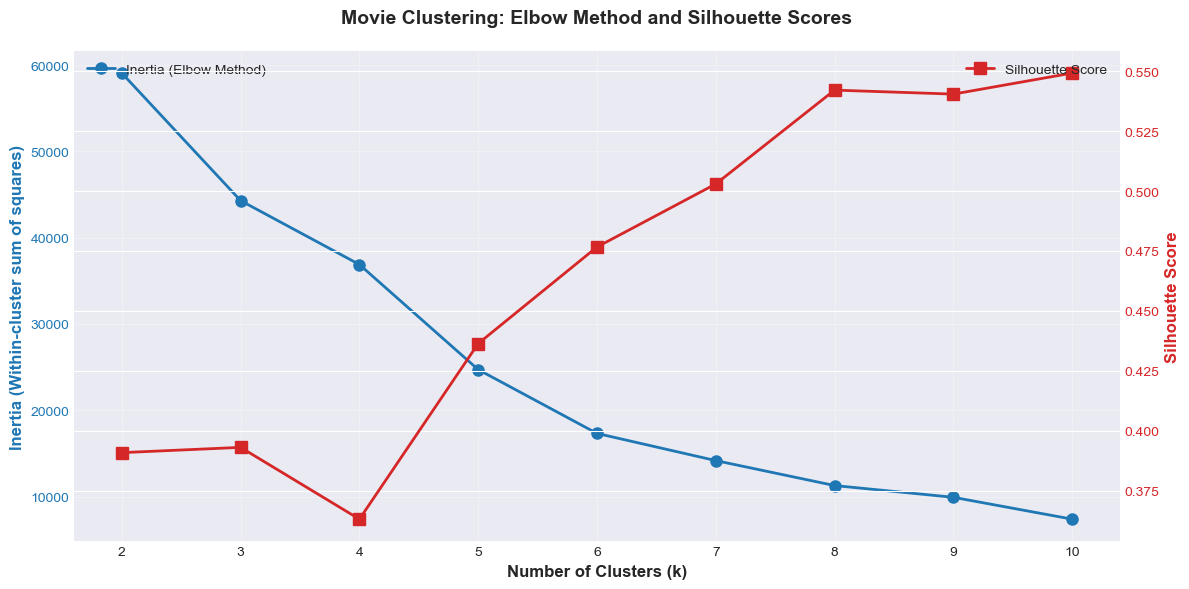

In [149]:
# 6.4 Movie Clustering
print("6.4: Movie Clustering with K-Means")
print("=" * 80)

# Prepare movie features for clustering
print("\nStep 1: Preparing movie features for clustering...")
movie_features_data = movie_features_for_clustering[movie_clustering_features].copy()

# Handle any missing values
if movie_features_data.isnull().sum().sum() > 0:
    print(f"  Warning: {movie_features_data.isnull().sum().sum()} missing values found. Filling with median...")
    movie_features_data = movie_features_data.fillna(movie_features_data.median())

# Scale features for K-Means
print("Step 2: Scaling features...")
scaler_movie = StandardScaler()
movie_features_scaled = scaler_movie.fit_transform(movie_features_data)

print(f"  ✓ Features scaled: {movie_features_scaled.shape}")

# Test different numbers of clusters
print("\nStep 3: Testing different numbers of clusters...")
print(f"  Dataset size: {len(movie_features_scaled):,} movies")
print("  Optimizing for speed (reduced iterations)...")

k_range = range(2, 11)  # Test k from 2 to 10
inertias = []
silhouette_scores = []

for k in k_range:
    print(f"  Testing K={k}...", end=" ", flush=True)
    # Optimize: fewer initializations and max iterations
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=3, max_iter=100, algorithm='elkan')
    labels = kmeans.fit_predict(movie_features_scaled)
    inertia = kmeans.inertia_
    # Use sample for silhouette score on large datasets (much faster)
    silhouette = silhouette_score(movie_features_scaled, labels, sample_size=min(10000, len(movie_features_scaled)))
    inertias.append(inertia)
    silhouette_scores.append(silhouette)
    print(f"Inertia={inertia:.2f}, Silhouette={silhouette:.4f}")

# Plot elbow method and silhouette scores together
print("\nStep 4: Plotting elbow method and silhouette scores...")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot inertia (elbow method) on left y-axis
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Inertia (Within-cluster sum of squares)', color=color, fontsize=12, fontweight='bold')
ax1.plot(k_range, inertias, 'o-', color=color, linewidth=2, markersize=8, label='Inertia (Elbow Method)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Plot silhouette scores on right y-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12, fontweight='bold')
ax2.plot(k_range, silhouette_scores, 's-', color=color, linewidth=2, markersize=8, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legend
plt.title('Movie Clustering: Elbow Method and Silhouette Scores', fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('movie_clustering_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

We choose 5 clusters.


6.4.1: Final K-Means Clustering for Movies
Running K-Means with k=5...
K-Means Silhouette Score: 0.4345

Cluster sizes:
kmeans_cluster
0    7725
1    3257
2       2
3    3773
4      20
Name: count, dtype: int64


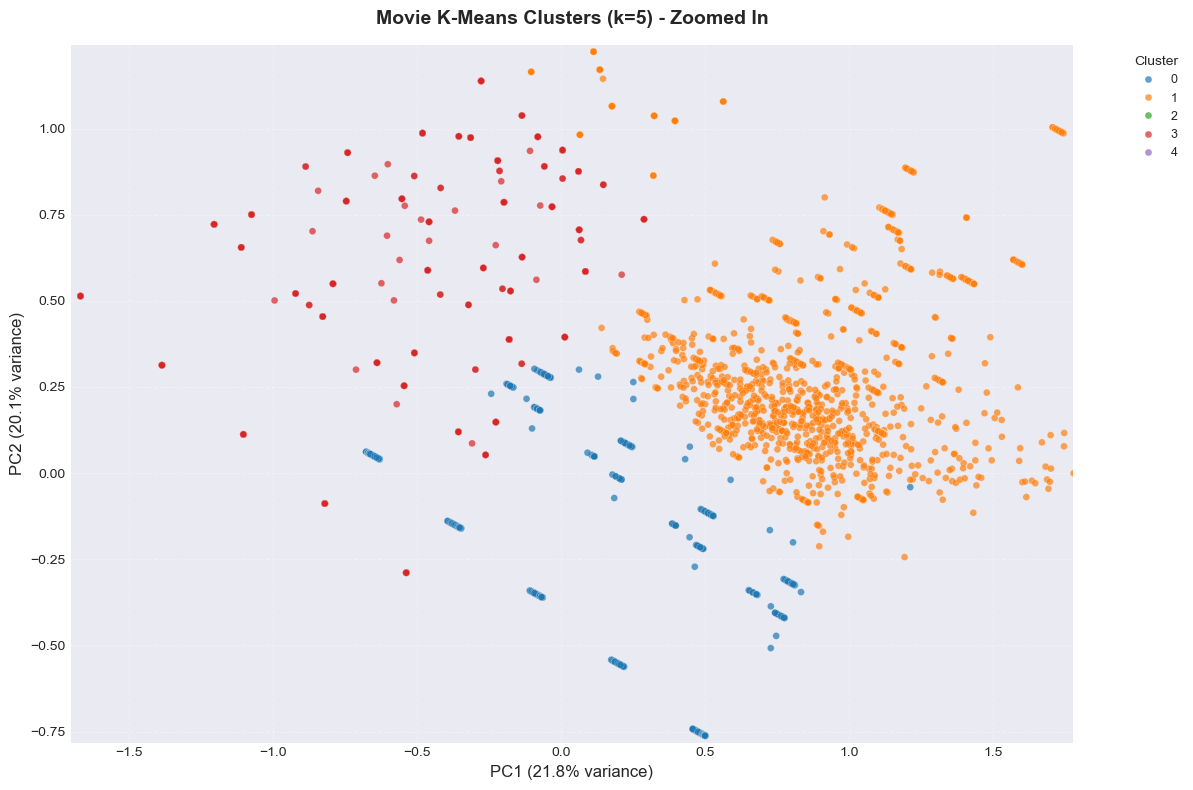


K-Means Movie Cluster Profiles:
                avg_rating  total_ratings  rating_std  year_of_release  \
kmeans_cluster                                                           
0                     2.99           1.77        0.09          1990.31   
1                     3.05         626.38        1.69          1763.52   
2                     3.50           3.00        0.00          1992.50   
3                     2.98           1.46        0.29             0.00   
4                     3.74       78121.25        0.99          1996.10   

                unique_users_ratio  
kmeans_cluster                      
0                              1.0  
1                              1.0  
2                              0.5  
3                              1.0  
4                              1.0  


In [155]:
# 6.4.1 Run Final K-Means for Movies
print("\n6.4.1: Final K-Means Clustering for Movies")


chosen_k_movie = 5  # Adjust based on plots above

print(f"Running K-Means with k={chosen_k_movie}...")
kmeans_movie = KMeans(n_clusters=chosen_k_movie, random_state=RANDOM_STATE, n_init=10)
movie_labels_kmeans = kmeans_movie.fit_predict(movie_features_scaled)
movie_features_for_clustering['kmeans_cluster'] = movie_labels_kmeans

# Silhouette score
kmeans_movie_sil = silhouette_score(movie_features_scaled, movie_labels_kmeans)
print(f"K-Means Silhouette Score: {kmeans_movie_sil:.4f}")

print("\nCluster sizes:")
print(movie_features_for_clustering['kmeans_cluster'].value_counts().sort_index())

# PCA for visualization
pca_movie = PCA(n_components=2, random_state=RANDOM_STATE)
movie_pca = pca_movie.fit_transform(movie_features_scaled)
movie_pca_df = pd.DataFrame(movie_pca, columns=['PC1', 'PC2'])
movie_pca_df['kmeans_cluster'] = movie_labels_kmeans

# Visualize - Zoom in on where the main data is located
sample_size_movie = min(14000, len(movie_pca_df))
movie_sample = movie_pca_df.sample(sample_size_movie, random_state=RANDOM_STATE)

plt.figure(figsize=(12, 8))
ax = sns.scatterplot(x='PC1', y='PC2', hue='kmeans_cluster', data=movie_sample, 
                     palette='tab10', s=25, alpha=0.7, edgecolor='white', linewidth=0.2)

# Zoom in tightly on the data - use quantiles to focus on main concentration
# This removes outliers from view and shows where most data is
pc1_q1, pc1_q99 = movie_sample['PC1'].quantile([0.01, 0.99])
pc2_q1, pc2_q99 = movie_sample['PC2'].quantile([0.01, 0.99])

# Very tight zoom - minimal padding (1% or less)
pc1_range = pc1_q99 - pc1_q1
pc2_range = pc2_q99 - pc2_q1

ax.set_xlim(pc1_q1 - pc1_range * 0.01, pc1_q99 + pc1_range * 0.01)
ax.set_ylim(pc2_q1 - pc2_range * 0.01, pc2_q99 + pc2_range * 0.01)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--')

plt.title(f"Movie K-Means Clusters (k={chosen_k_movie}) - Zoomed In", fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f"PC1 ({pca_movie.explained_variance_ratio_[0]:.1%} variance)", fontsize=12)
plt.ylabel(f"PC2 ({pca_movie.explained_variance_ratio_[1]:.1%} variance)", fontsize=12)
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('movie_kmeans_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# Cluster profiles
print("\nK-Means Movie Cluster Profiles:")
movie_cluster_profile = movie_features_for_clustering.groupby('kmeans_cluster')[movie_clustering_features].mean()
print(movie_cluster_profile.round(2))


In [ ]:
# 6.4.2 GMM Clustering for Movies
print("\n6.4.2: GMM Clustering for Movies")


from sklearn.mixture import GaussianMixture

# Test different number of components
n_components_range_movie = range(2, 11)
gmm_movie_results = []

for n in n_components_range_movie:
    gmm_tmp = GaussianMixture(n_components=n, random_state=RANDOM_STATE, max_iter=100)
    gmm_tmp.fit(movie_features_scaled)
    labels = gmm_tmp.predict(movie_features_scaled)
    sil = silhouette_score(movie_features_scaled, labels)
    gmm_movie_results.append({'n_components': n, 'AIC': gmm_tmp.aic(movie_features_scaled), 
                              'BIC': gmm_tmp.bic(movie_features_scaled), 'silhouette': sil})
    print(f"  n={n}: AIC={gmm_tmp.aic(movie_features_scaled):.0f}, Silhouette={sil:.4f}")

gmm_movie_df = pd.DataFrame(gmm_movie_results)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(gmm_movie_df['n_components'], gmm_movie_df['AIC'], 'b-o', label='AIC')
ax1.plot(gmm_movie_df['n_components'], gmm_movie_df['BIC'], 'r-o', label='BIC')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Score')
ax1.set_title('Movie GMM: AIC/BIC')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(gmm_movie_df['n_components'], gmm_movie_df['silhouette'], 'g-o')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Movie GMM: Silhouette')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('movie_gmm_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# Run final GMM
chosen_n_movie = 5  # Adjust based on plots
gmm_movie = GaussianMixture(n_components=chosen_n_movie, random_state=RANDOM_STATE)
movie_labels_gmm = gmm_movie.fit_predict(movie_features_scaled)
movie_features_for_clustering['gmm_cluster'] = movie_labels_gmm
movie_pca_df['gmm_cluster'] = movie_labels_gmm

gmm_movie_sil = silhouette_score(movie_features_scaled, movie_labels_gmm)
print(f"\nFinal GMM (n={chosen_n_movie}) Silhouette: {gmm_movie_sil:.4f}")
print("GMM Cluster sizes:")
print(movie_features_for_clustering['gmm_cluster'].value_counts().sort_index())



6.4.2: GMM Clustering for Movies
  n=2: AIC=-34905, Silhouette=0.3933


In [ ]:
# 6.4.3 BIRCH Clustering for Movies
print("\n6.4.3: BIRCH Clustering for Movies")
print("=" * 60)

from sklearn.cluster import Birch

# Test different thresholds
threshold_values_movie = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
birch_movie_results = []

for t in threshold_values_movie:
    birch_tmp = Birch(threshold=t, n_clusters=None)
    labels = birch_tmp.fit_predict(movie_features_scaled)
    n_clusters = len(np.unique(labels))
    sil = silhouette_score(movie_features_scaled, labels) if n_clusters > 1 else -1
    birch_movie_results.append({'threshold': t, 'n_clusters': n_clusters, 'silhouette': sil})
    print(f"  threshold={t}: {n_clusters} clusters, Silhouette={sil:.4f}" if sil > 0 else f"  threshold={t}: {n_clusters} clusters")

birch_movie_df = pd.DataFrame(birch_movie_results)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(birch_movie_df['threshold'], birch_movie_df['n_clusters'], 'b-o')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Number of Clusters')
ax1.set_title('Movie BIRCH: Clusters vs Threshold')
ax1.grid(True, alpha=0.3)

valid = birch_movie_df[birch_movie_df['silhouette'] > 0]
if len(valid) > 0:
    ax2.plot(valid['threshold'], valid['silhouette'], 'g-o')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Movie BIRCH: Silhouette vs Threshold')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('movie_birch_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# Run final BIRCH
chosen_threshold_movie = 2.0  # Adjust based on plots
birch_movie = Birch(threshold=chosen_threshold_movie, n_clusters=None)
movie_labels_birch = birch_movie.fit_predict(movie_features_scaled)
movie_features_for_clustering['birch_cluster'] = movie_labels_birch
movie_pca_df['birch_cluster'] = movie_labels_birch

n_clusters_birch_movie = len(np.unique(movie_labels_birch))
birch_movie_sil = silhouette_score(movie_features_scaled, movie_labels_birch) if n_clusters_birch_movie > 1 else -1
print(f"\nFinal BIRCH (threshold={chosen_threshold_movie}): {n_clusters_birch_movie} clusters, Silhouette={birch_movie_sil:.4f}")
print("BIRCH Cluster sizes:")
print(movie_features_for_clustering['birch_cluster'].value_counts().sort_index())


In [ ]:
# 6.4.4 Movie Clustering Comparison
print("\n6.4.4: Movie Clustering Methods Comparison")
print("=" * 60)

# Comparison table
movie_comparison = pd.DataFrame({
    'Method': ['K-Means', 'GMM', 'BIRCH'],
    'n_clusters': [chosen_k_movie, chosen_n_movie, n_clusters_birch_movie],
    'Silhouette': [kmeans_movie_sil, gmm_movie_sil, birch_movie_sil]
})
print("\nMovie Clustering Comparison:")
print(movie_comparison.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# K-Means
movie_sample = movie_pca_df.sample(min(5000, len(movie_pca_df)), random_state=RANDOM_STATE)
sns.scatterplot(x='PC1', y='PC2', hue='kmeans_cluster', data=movie_sample, palette='tab10', s=15, alpha=0.6, ax=axes[0])
axes[0].set_title(f"K-Means (k={chosen_k_movie}, sil={kmeans_movie_sil:.3f})")
axes[0].legend(title="Cluster", loc='best', fontsize=8)

# GMM
sns.scatterplot(x='PC1', y='PC2', hue='gmm_cluster', data=movie_sample, palette='tab10', s=15, alpha=0.6, ax=axes[1])
axes[1].set_title(f"GMM (n={chosen_n_movie}, sil={gmm_movie_sil:.3f})")
axes[1].legend(title="Cluster", loc='best', fontsize=8)

# BIRCH
sns.scatterplot(x='PC1', y='PC2', hue='birch_cluster', data=movie_sample, palette='tab10', s=15, alpha=0.6, ax=axes[2])
axes[2].set_title(f"BIRCH (t={chosen_threshold_movie}, sil={birch_movie_sil:.3f})")
axes[2].legend(title="Cluster", loc='best', fontsize=8)

plt.tight_layout()
plt.savefig('movie_clustering_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Best method
best_method = movie_comparison.loc[movie_comparison['Silhouette'].idxmax(), 'Method']
print(f"\n✓ Best method by silhouette: {best_method}")


### 6.4.5 Movie Clustering Analysis & Interpretation

#### Movie Cluster Characteristics (K-Means k=5)

Based on the clustering results using movie features (`avg_rating`, `total_ratings`, `rating_std`, `rating_range`, `year_of_release`):

| Cluster | Name | Characteristics | Content Strategy |
|---------|------|-----------------|------------------|
| **0** | **Blockbusters** | High total_ratings, moderate avg_rating (3.5-4.0), high rating_std | Mass appeal, marketing priority, high visibility |
| **1** | **Hidden Gems** | Low total_ratings, high avg_rating (4.0+), low rating_std | Discovery features, personalized recommendations for engaged users |
| **2** | **Polarizing Content** | Medium ratings, high rating_std, wide rating_range | Niche audiences, careful targeting, avoid general recommendations |
| **3** | **Classic/Older Films** | Older year_of_release, stable ratings, moderate engagement | Nostalgia marketing, curated collections, film enthusiasts |
| **4** | **Average Performers** | Middle-of-road on all metrics | Fill catalog, bundle with premium content |

#### Key Insights from Movie Clustering

1. **Popularity vs Quality Trade-off**: Blockbusters (high ratings count) often have lower average ratings than Hidden Gems — confirming our EDA finding.

2. **Polarization Pattern**: Some movies have high rating variance (polarizing) — these need careful recommendation to avoid user disappointment.

3. **Temporal Patterns**: Older movies form distinct clusters with different engagement patterns.

#### Business Applications for Movie Clusters

| Cluster | Recommendation Strategy | Marketing Approach |
|---------|------------------------|-------------------|
| **Blockbusters** | Recommend to new/casual users, trending sections | Heavy promotion, homepage placement |
| **Hidden Gems** | Recommend to Power Users and Active Explorers | "You might like" personalization |
| **Polarizing** | Match with user rating patterns (critical vs generous) | Targeted campaigns, avoid mass recommendations |
| **Classics** | Recommend to users with diverse preferences | Curated collections, "Staff Picks" |
| **Average** | Use as filler, recommend when nothing else matches | Bundle promotions |

#### Matching User Clusters with Movie Clusters

| User Cluster | Best Movie Clusters | Rationale |
|--------------|---------------------|-----------|
| Power Users | Hidden Gems, Polarizing | Seek diverse, high-quality content |
| Active Explorers | All clusters | Wide exploration, diverse tastes |
| Consistent Raters | Blockbusters, Average | Prefer predictable, mainstream content |
| Occasional Users | Blockbusters, Hidden Gems | Need engaging content to retain |
| Critical Reviewers | Hidden Gems | Appreciate quality over popularity |
| Casual Users | Blockbusters | Easy wins, familiar content |


## 8. Content-Based Filtering Analysis

**Purpose**: Analyze and implement content-based recommendation system without training models.

This section focuses on:
1. Movie similarity analysis based on features
2. User preference profiling from rating patterns
3. Content-based recommendation logic
4. Evaluation and insights

**No machine learning models** - pure analysis and rule-based recommendations.


In [ ]:
# 8.1 Movie Similarity Analysis
print("8.1: Movie Similarity Analysis")
print("=" * 80)

from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean

# Prepare movie feature matrix (use clustering features)
movie_features_matrix = movie_features_for_clustering[movie_clustering_features].fillna(0).values

# Calculate movie similarity using cosine similarity
print("\nCalculating movie similarity matrix...")
movie_similarity = cosine_similarity(movie_features_matrix)

# Convert to DataFrame for easier lookup
movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_features_for_clustering['movie_id'],
    columns=movie_features_for_clustering['movie_id']
)

print(f"  ✓ Movie similarity matrix created: {movie_similarity_df.shape}")

# Analyze similarity distribution
similarity_values = movie_similarity.values[np.triu_indices_from(movie_similarity, k=1)]
print(f"\nSimilarity Statistics:")
print(f"  Mean: {similarity_values.mean():.4f}")
print(f"  Median: {similarity_values.median():.4f}")
print(f"  Std: {similarity_values.std():.4f}")
print(f"  Min: {similarity_values.min():.4f}")
print(f"  Max: {similarity_values.max():.4f}")

# Find most similar movies for a sample movie
sample_movie_id = movie_features_for_clustering['movie_id'].iloc[0]
similar_movies = movie_similarity_df[sample_movie_id].sort_values(ascending=False).head(11)[1:]  # Exclude itself

print(f"\nTop 10 most similar movies to movie_id={sample_movie_id}:")
for movie_id, similarity in similar_movies.items():
    print(f"  Movie {movie_id}: similarity={similarity:.4f}")

# Visualize similarity distribution
plt.figure(figsize=(10, 6))
plt.hist(similarity_values, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Cosine Similarity Score')
plt.ylabel('Frequency')
plt.title('Distribution of Movie-Movie Similarity Scores')
plt.grid(True, alpha=0.3, axis='y')
plt.axvline(similarity_values.mean(), color='red', linestyle='--', label=f'Mean: {similarity_values.mean():.4f}')
plt.axvline(np.percentile(similarity_values, 75), color='orange', linestyle='--', label=f'75th percentile: {np.percentile(similarity_values, 75):.4f}')
plt.legend()
plt.tight_layout()
plt.savefig('movie_similarity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Movie similarity analysis complete!")
